<a href="https://colab.research.google.com/github/AyokanmiAremu/QSAR-STUDY/blob/main/GBR_RF_XGB_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
import io
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
# sklearn models
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

# sklearn tools
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import validation_curve

from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error


# Statistical packages
import statsmodels.api as sm
from statsmodels.formula.api import ols   # ordinary least squares model
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Eng/VIF/VIF_selected.csv')
df
#Fir Waterfall
#8,12,9,11,40,41,33
#7,8,35,37,30,31,23

,Cpd.,pIC50,AlogP98,MD,SA_ZX
0,1,4.21,4.462400,1.026952,65.526901
1,2,4.48,4.918600,1.021969,65.474936
2,3,4.53,3.954200,1.016827,68.940075
3,4,5.04,6.167399,1.012446,76.214410
4,5,5.19,6.243000,1.170088,75.667501
5,6,4.71,5.373500,1.037879,77.371704
6,7,4.94,5.494600,1.025910,73.501209
7,8,4.07,5.126800,1.086100,63.608103
8,12,4.17,4.948600,1.016723,69.957622
9,13,5.23,5.980801,1.019176,79.573671


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score

# Assuming you have already loaded your data as df
# Define X and y from your dataframe (adjust according to your dataframe structure)
X = df.iloc[:, 2:]  # Assuming your features start from the third column
y = df.iloc[:, 1]   # Assuming the target variable is in the second column

# Splitting train and test indices (you can adjust these indices accordingly)
train_indices = list(range(0, 35))  # Training set: indices 0 to 34
test_indices = list(range(35, 45))  # Test set: indices 35 to 44


X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]
X_test = X.iloc[test_indices]
y_test = y.iloc[test_indices]

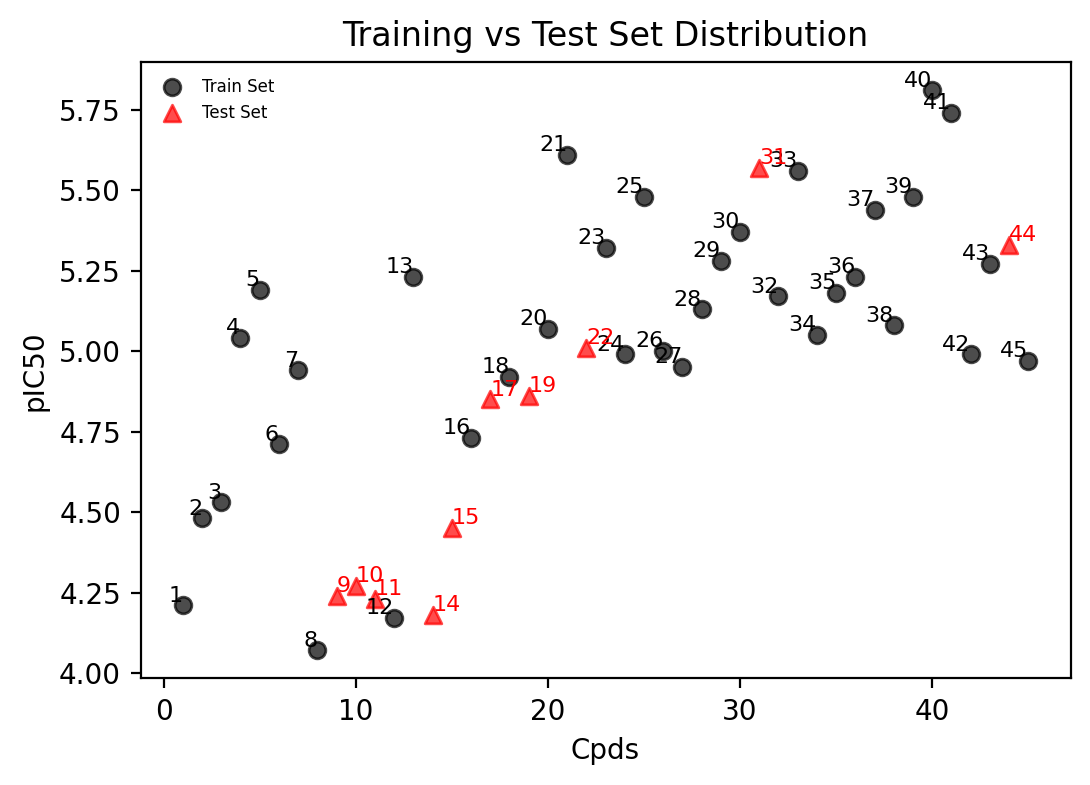

In [ ]:
import matplotlib.pyplot as plt

# Extract compound numbers from the first column of df
cpd_train = df.iloc[train_indices, 0]  # Compound numbers for training set
cpd_test = df.iloc[test_indices, 0]    # Compound numbers for test set

# Create figure
plt.figure(figsize=(6, 4))

# Scatter plot for training set
plt.scatter(cpd_train, y_train, c="black", label="Train Set", alpha=0.7)
for i, txt in enumerate(cpd_train):
    plt.annotate(txt, (cpd_train.iloc[i], y_train.iloc[i]), fontsize=8, ha='right', va='bottom')

# Scatter plot for test set
plt.scatter(cpd_test, y_test, c="red", marker='^', label="Test Set", alpha=0.7)
for i, txt in enumerate(cpd_test):
    plt.annotate(txt, (cpd_test.iloc[i], y_test.iloc[i]), fontsize=8, ha='left', va='bottom', color='red')

# Labels and title
plt.xlabel("Cpds")
plt.ylabel("pIC50")
plt.title("Training vs Test Set Distribution")

# Legend in the top left with no frame and smaller font size
plt.legend(loc="upper left", frameon=False, fontsize=6)

# Show plot
plt.show()


Tuning Parameters and Building Model

In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the objective function for Optuna to optimize
def objective(trial):
    # Suggest hyperparameters using Optuna's trial object
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.05)

    # Create the GradientBoostingRegressor model
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        learning_rate=learning_rate,
        loss="squared_error"
    )

    # Train the model on the training set
    model.fit(X_train, y_train)

    # Predict on both the training set and test set
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate RMSE for both the training set and test set
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Return the average of the training and test RMSE
    combined_rmse = (rmse_train + rmse_test) / 2

    return combined_rmse  # Return combined RMSE as the objective to minimize

# Create an Optuna study
study = optuna.create_study(direction="minimize")

# Perform optimization
study.optimize(objective, n_trials=5)

# Get the best hyperparameters from the study
best_params = study.best_params
print("Best Hyperparameters (Optuna):", best_params)

# Build the final model with the best hyperparameters
best_model = GradientBoostingRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    learning_rate=best_params['learning_rate'],
    loss="squared_error"
)

# Train the final model on the full training data
best_model.fit(X_train, y_train)

# Evaluate the final model on both the training and test sets
y_pred_train_final = best_model.predict(X_train)
y_pred_test_final = best_model.predict(X_test)

# Calculate RMSE for the final model on both sets
final_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

print(f"Final RMSE on the Training Set: {final_train_rmse}")
print(f"Final RMSE on the Test Set: {final_test_rmse}")


[I 2026-05-02 12:43:27,015] A new study created in memory with name: no-name-a6a9b198-97f4-4d6c-b3f1-4a4ab5be0041
[I 2026-05-02 12:43:27,199] Trial 0 finished with value: 0.08657975871932874 and parameters: {'n_estimators': 139, 'max_depth': 8, 'min_samples_split': 8, 'learning_rate': 0.04416952342979242}. Best is trial 0 with value: 0.08657975871932874.
[I 2026-05-02 12:43:27,503] Trial 1 finished with value: 0.08150094786684478 and parameters: {'n_estimators': 291, 'max_depth': 4, 'min_samples_split': 12, 'learning_rate': 0.040707962834868626}. Best is trial 1 with value: 0.08150094786684478.
[I 2026-05-02 12:43:27,618] Trial 2 finished with value: 0.16388561765213866 and parameters: {'n_estimators': 157, 'max_depth': 4, 'min_samples_split': 9, 'learning_rate': 0.012510599297005348}. Best is trial 1 with value: 0.08150094786684478.
[I 2026-05-02 12:43:27,836] Trial 3 finished with value: 0.10480408121688461 and parameters: {'n_estimators': 273, 'max_depth': 8, 'min_samples_split': 15

Best Hyperparameters (Optuna): {'n_estimators': 291, 'max_depth': 4, 'min_samples_split': 12, 'learning_rate': 0.040707962834868626}
Final RMSE on the Training Set: 0.028377246130007444
Final RMSE on the Test Set: 0.13462464960368212


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Define the best hyperparameters from Optuna
best_params = {
    'n_estimators': 291,
    'max_depth': 4,
    'min_samples_split': 12,
    'learning_rate': 0.040707962834868626
}

# Instantiate the Gradient Boosting Regressor with the best hyperparameters
best_model = GradientBoostingRegressor(**best_params)

# Fit the model on the training data
best_model.fit(X_train, y_train)

# Predict on the training data
y_pred_train = best_model.predict(X_train)

In [ ]:
from sklearn.metrics import r2_score

# Predict on the test data
y_pred_test = best_model.predict(X_test)

# Calculate RMSE manually for training data
mse_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train)) / len(y_train)
rmse_train = mse_train ** 0.5
r2_train = r2_score(y_train, y_pred_train)

# Calculate RMSE manually for testing data
mse_test = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test)) / len(y_test)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, y_pred_test)

# Print out the results
print('RMSE (train): %.3f' % rmse_train)
print('R² (train): %.3f' % r2_train)
print('RMSE (test): %.3f' % rmse_test)
print('R² (test): %.3f' % r2_test)


RMSE (train): 0.028
R² (train): 0.995
RMSE (test): 0.135
R² (test): 0.919


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predict on the test data
y_pred_test = best_model.predict(X_test)

# ----- TRAIN METRICS -----
mse_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train)) / len(y_train)
rmse_train = mse_train ** 0.5
r2_train = r2_score(y_train, y_pred_train)

# ----- TEST METRICS -----
mse_test = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test)) / len(y_test)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, y_pred_test)

# MAE (test)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Q2 (external test set)
y_train_mean = sum(y_train) / len(y_train)
ss_res = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test))
ss_tot = sum((y - y_train_mean) ** 2 for y in y_test)
q2_test = 1 - (ss_res / ss_tot)

# ----- PRINT RESULTS -----
print('RMSE (train): %.3f' % rmse_train)
print('R² (train): %.3f' % r2_train)

print('RMSE (test): %.3f' % rmse_test)
print('R² (test): %.3f' % r2_test)
print('MAE (test): %.3f' % mae_test)
print('Q² (test): %.3f' % q2_test)

RMSE (train): 0.028
R² (train): 0.995
RMSE (test): 0.135
R² (test): 0.919
MAE (test): 0.107
Q² (test): 0.950


In [ ]:
from sklearn.metrics import mean_absolute_error

# ===================== TRAIN METRICS =====================

# MAE (train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Q² (train)
y_train_mean = sum(y_train) / len(y_train)

ss_res_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train))
ss_tot_train = sum((y - y_train_mean) ** 2 for y in y_train)

q2_train = 1 - (ss_res_train / ss_tot_train)

# Print results
print('MAE (train): %.3f' % mae_train)
print('Q² (train): %.3f' % q2_train)

MAE (train): 0.022
Q² (train): 0.995


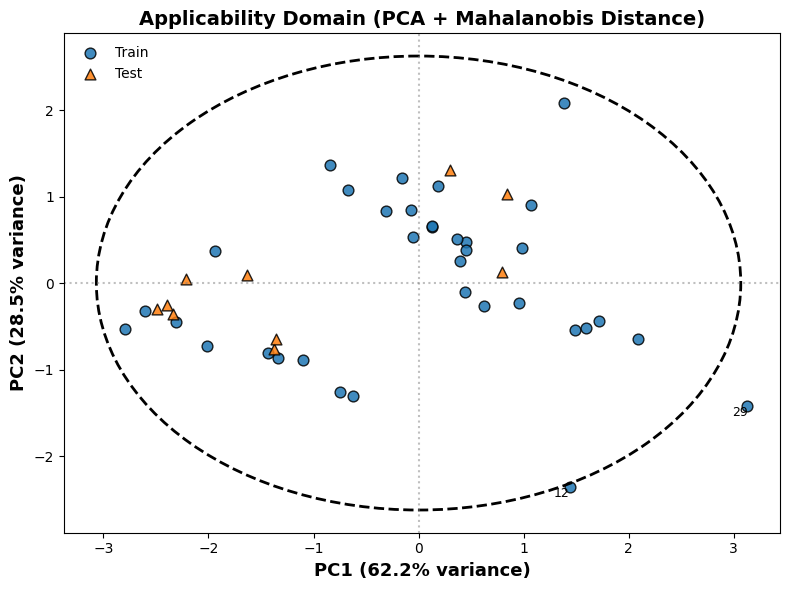

Chi-square level: 0.95
Threshold (MD^2): 5.9915
Train outliers   : 2 / 35
Test outliers    : 0 / 10


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf

from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from scipy.linalg import eigh
from matplotlib.patches import Ellipse


# =========================================================
# SETTINGS
# =========================================================
PCA_NCOMP = 2               # keep 2 to plot PC1 vs PC2
CHI2_LEVEL = 0.95           # 95% AD ellipse
LABEL_OUTLIERS = True       # label points outside ellipse
PLOT_LOADINGS = False       # set True if you really want loading arrows
LOADING_SCALE = 2.0         # arrow scaling (if PLOT_LOADINGS=True)
DESIGNED_CSV_PATH = "./designed-desc.csv"   # optional
FIGSIZE = (8, 6)


# =========================================================
# HELPER: safely turn X into a DataFrame with column names
# =========================================================
def to_dataframe(X, feature_labels=None, name_prefix="x"):
    """
    Convert X (DataFrame or array-like) to DataFrame.
    If DataFrame: keep columns.
    If array: make columns. If feature_labels provided and length matches, use them.
    """
    if isinstance(X, pd.DataFrame):
        return X.copy()

    X_np = np.asarray(X)
    n_features = X_np.shape[1]

    if feature_labels is not None and len(feature_labels) == n_features:
        cols = list(feature_labels)
    else:
        cols = [f"{name_prefix}{i}" for i in range(n_features)]

    return pd.DataFrame(X_np, columns=cols)


# =========================================================
# HELPER: ellipse plotter
# =========================================================
def plot_mahalanobis_ellipse(mean, cov, threshold, ax, **kwargs):
    vals, vecs = eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    width, height = 2 * np.sqrt(vals * threshold)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)


# =========================================================
# 1) Detect feature_labels if it exists, else None
# =========================================================
feature_labels_local = None
try:
    # use feature_labels if user defined it
    feature_labels_local = feature_labels
except NameError:
    feature_labels_local = None


# =========================================================
# 2) Make X_train_df and X_test_df safely
# =========================================================
X_train_df = to_dataframe(X_train, feature_labels_local, name_prefix="f")
X_test_df  = to_dataframe(X_test,  X_train_df.columns.tolist(), name_prefix="f")  # enforce same columns

# Ensure same column order for test (important)
X_test_df = X_test_df[X_train_df.columns]


# =========================================================
# 3) Optional: load designed set if present and compatible
# =========================================================
X_design_df = None
try:
    df_design_raw = pd.read_csv(DESIGNED_CSV_PATH, index_col=0)
    # Keep only matching features (if designed has extra columns)
    missing = [c for c in X_train_df.columns if c not in df_design_raw.columns]
    if len(missing) == 0:
        X_design_df = df_design_raw[X_train_df.columns].copy()
    else:
        print("Designed set found, but missing required columns. Skipping designed plot.")
        print("Missing columns:", missing[:10], ("..." if len(missing) > 10 else ""))
        X_design_df = None
except Exception:
    # No designed file or read error: just ignore
    X_design_df = None


# =========================================================
# 4) Scaling: reuse existing scaler if present, else fit new
# =========================================================
scaler_local = None
try:
    scaler_local = scaler
except NameError:
    scaler_local = None

if scaler_local is None:
    scaler_local = StandardScaler()
    X_train_scaled = scaler_local.fit_transform(X_train_df.values)
else:
    X_train_scaled = scaler_local.transform(X_train_df.values)

X_test_scaled = scaler_local.transform(X_test_df.values)

if X_design_df is not None:
    X_design_scaled = scaler_local.transform(X_design_df.values)


# =========================================================
# 5) PCA: reuse existing pca if present, else fit new
# =========================================================
pca_local = None
try:
    pca_local = pca
except NameError:
    pca_local = None

if pca_local is None:
    pca_local = PCA(n_components=PCA_NCOMP, random_state=0)
    X_train_pca_full = pca_local.fit_transform(X_train_scaled)
else:
    X_train_pca_full = pca_local.transform(X_train_scaled)

X_test_pca_full = pca_local.transform(X_test_scaled)

# Force first 2 PCs for plotting even if PCA has more components
X_train_pca = X_train_pca_full[:, :2]
X_test_pca  = X_test_pca_full[:, :2]

if X_design_df is not None:
    X_design_pca_full = pca_local.transform(X_design_scaled)
    X_design_pca = X_design_pca_full[:, :2]


# =========================================================
# 6) Mahalanobis distance based on TRAIN only (robust cov)
# =========================================================
lw = LedoitWolf().fit(X_train_pca)
mean_vec = lw.location_
cov_matrix = lw.covariance_

# numerical stability
epsilon = 1e-8
cov_matrix = cov_matrix + np.eye(cov_matrix.shape[0]) * epsilon
inv_cov = np.linalg.inv(cov_matrix)

md_train = np.array([mahalanobis(x, mean_vec, inv_cov) for x in X_train_pca])
md_test  = np.array([mahalanobis(x, mean_vec, inv_cov) for x in X_test_pca])

md_design = None
if X_design_df is not None:
    md_design = np.array([mahalanobis(x, mean_vec, inv_cov) for x in X_design_pca])

threshold = chi2.ppf(CHI2_LEVEL, df=2)  # df=2 because we use PC1/PC2 for ellipse


# =========================================================
# 7) Assemble plot dataframe (safe indices)
# =========================================================
train_index = X_train_df.index if hasattr(X_train_df, "index") else np.arange(len(X_train_df))
test_index  = X_test_df.index  if hasattr(X_test_df, "index")  else np.arange(len(X_test_df))

df_train_plot = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"], index=train_index)
df_train_plot["Group"] = "Train"
df_train_plot["MD2"] = md_train ** 2
df_train_plot["Outlier-MD"] = df_train_plot["MD2"] > threshold

df_test_plot = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"], index=test_index)
df_test_plot["Group"] = "Test"
df_test_plot["MD2"] = md_test ** 2
df_test_plot["Outlier-MD"] = df_test_plot["MD2"] > threshold

df_plot = pd.concat([df_train_plot, df_test_plot], axis=0)

if X_design_df is not None:
    design_index = X_design_df.index
    df_design_plot = pd.DataFrame(X_design_pca, columns=["PC1", "PC2"], index=design_index)
    df_design_plot["Group"] = "Designed"
    df_design_plot["MD2"] = md_design ** 2
    df_design_plot["Outlier-MD"] = df_design_plot["MD2"] > threshold
    df_plot = pd.concat([df_plot, df_design_plot], axis=0)


# =========================================================
# 8) Plot
# =========================================================
fig, ax = plt.subplots(figsize=FIGSIZE)

# Use non-red colors by default (you said you don’t like red)
group_styles = {
    "Train": {"marker": "o", "label": "Train"},
    "Test": {"marker": "^", "label": "Test"},
    "Designed": {"marker": "s", "label": "Designed"},
}

for group in df_plot["Group"].unique():
    style = group_styles.get(group, {"marker": "o", "label": group})
    g = df_plot[df_plot["Group"] == group]
    ax.scatter(
        g["PC1"], g["PC2"],
        marker=style["marker"],
        s=60,
        alpha=0.85,
        edgecolor="black",
        label=style["label"]
    )

# Ellipse (AD boundary)
plot_mahalanobis_ellipse(
    mean=mean_vec,
    cov=cov_matrix,
    threshold=threshold,
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=2,
    ls="--"
)

# Outlier labels
if LABEL_OUTLIERS:
    outliers = df_plot[df_plot["Outlier-MD"]]
    for idx, row in outliers.iterrows():
        ax.text(row["PC1"], row["PC2"], str(idx), fontsize=9, ha="right", va="top")

# Optional: loadings (only if PCA was fit on the same descriptors and you want labels)
if PLOT_LOADINGS and hasattr(pca_local, "components_"):
    # this only makes sense if pca_local was fitted on scaled features with the same columns
    loadings = pca_local.components_[:2].T
    cols = list(X_train_df.columns)
    for i, (x, y) in enumerate(loadings):
        ax.arrow(0, 0, x * LOADING_SCALE, y * LOADING_SCALE,
                 color="gray", alpha=0.7, head_width=0.06, head_length=0.08)
        if i < len(cols):
            ax.text(x * LOADING_SCALE * 1.08, y * LOADING_SCALE * 1.08,
                    cols[i], fontsize=9, ha="center", va="center")

# Axes lines + labels
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.axvline(0, color="gray", ls=":", alpha=0.5)

# Explained variance labels (safe)
try:
    pc1_var = pca_local.explained_variance_ratio_[0] * 100
    pc2_var = pca_local.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f"PC1 ({pc1_var:.1f}% variance)", fontsize=13, fontweight="bold")
    ax.set_ylabel(f"PC2 ({pc2_var:.1f}% variance)", fontsize=13, fontweight="bold")
except Exception:
    ax.set_xlabel("PC1", fontsize=13, fontweight="bold")
    ax.set_ylabel("PC2", fontsize=13, fontweight="bold")

ax.set_title("Applicability Domain (PCA + Mahalanobis Distance)", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()

# Summary
print(f"Chi-square level: {CHI2_LEVEL}")
print(f"Threshold (MD^2): {threshold:.4f}")
print(f"Train outliers   : {int((df_train_plot['MD2'] > threshold).sum())} / {len(df_train_plot)}")
print(f"Test outliers    : {int((df_test_plot['MD2'] > threshold).sum())} / {len(df_test_plot)}")
if X_design_df is not None:
    print(f"Designed outliers: {int((df_design_plot['MD2'] > threshold).sum())} / {len(df_design_plot)}")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# Convert X_train and y_train to NumPy arrays
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

# Initialize K-Fold Cross-Validation
n_splits = 5  # Specify the number of splits
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# List to store R² scores for each fold
r2_scores = []

# Perform Cross-Validation
for train_index, test_index in kf.split(X_train_np):
    # Split the data into training and validation folds
    X_cv_train, X_cv_test = X_train_np[train_index], X_train_np[test_index]
    y_cv_train, y_cv_test = y_train_np[train_index], y_train_np[test_index]

    # Use the existing cv model to predict on the validation fold
    y_pred = best_model_cv.predict(X_cv_test)

    # Calculate R² score for the validation fold
    r2_fold = r2_score(y_cv_test, y_pred)
    r2_scores.append(r2_fold)

# Calculate Mean and Standard Deviation of R² Scores
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

# Display Results
print(f"R² (Cross-Validation): {mean_r2:.4f} ± {std_r2:.4f}")


R² (Cross-Validation): 0.9899 ± 0.0113


In [ ]:
import pandas as pd

# Creating DataFrame for training set results
train_results = pd.DataFrame({'Actual': y_train, 'Predicted': y_pred_train, 'Error': y_train - y_pred_train})
print("Train Set Results:")
print(train_results)

# Saving the training set results as a CSV file
train_results.to_csv('/content/drive/MyDrive/Eng/VIF/NEW_predVSexp_train1.csv', index=False)


# Creating DataFrame for test set results
test_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test, 'Error': y_test - y_pred_test})
print("Test Set Results:")
print(test_results)

# Saving the test set results as a CSV file
test_results.to_csv('/content/drive/MyDrive/Eng/VIF/NEW_predVSexp_test1.csv', index=False)

#print("Results have been saved as 'train_results.csv' and 'test_results.csv'.")


Train Set Results:
    Actual  Predicted     Error
0     4.21   4.246235 -0.036235
1     4.48   4.456367  0.023633
2     4.53   4.513965  0.016035
3     5.04   5.034420  0.005580
4     5.19   5.219001 -0.029001
5     4.71   4.735573 -0.025573
6     4.94   4.936836  0.003164
7     4.07   4.074396 -0.004396
8     4.17   4.196053 -0.026053
9     5.23   5.229764  0.000236
10    4.73   4.729847  0.000153
11    4.92   4.869254  0.050746
12    5.07   5.074398 -0.004398
13    5.61   5.586424  0.023576
14    5.32   5.326881 -0.006881
15    4.99   5.048589 -0.058589
16    5.48   5.456714  0.023286
17    5.00   5.009422 -0.009422
18    4.95   4.963741 -0.013741
19    5.13   5.155938 -0.025938
20    5.28   5.278960  0.001040
21    5.37   5.335361  0.034639
22    5.17   5.184013 -0.014013
23    5.56   5.492454  0.067546
24    5.05   5.102030 -0.052030
25    5.18   5.179042  0.000958
26    5.23   5.192139  0.037861
27    5.44   5.439986  0.000014
28    5.08   5.113929 -0.033929
29    5.48   5.493505

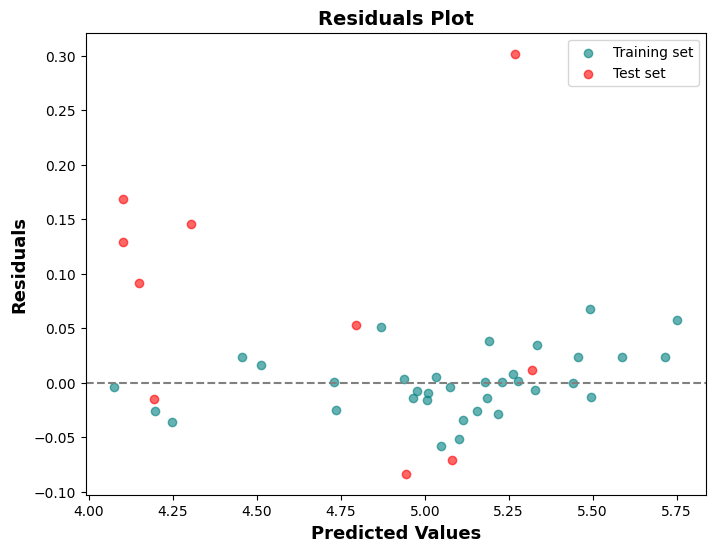

In [ ]:
# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Plot residuals for training and test sets
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_train, residuals_train, color='teal', label='Training set', alpha=0.6)
plt.scatter(y_pred_test, residuals_test, color='red', label='Test set', alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Values', fontsize=13, fontweight='bold')
plt.ylabel('Residuals', fontsize=13, fontweight='bold')
plt.title('Residuals Plot', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


THE NEW SCRIPTS FOR GRAHP

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'train': '#002060',
        'test': '#f0984d',
        'edge': '#002060'
    }
}

scheme = COLOR_SCHEMES[1]

# ===================== PLOT FUNCTION =====================
def plot_back_to_back_histogram(y_train, y_test):

    # Combine data for consistent bins
    all_data = np.concatenate([y_train, y_test])
    bins = np.linspace(min(all_data), max(all_data), 10)

    # Histogram counts
    counts_train, bin_edges = np.histogram(y_train, bins=bins)
    counts_test, _ = np.histogram(y_test, bins=bins)

    # Bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Bar height
    bar_height = (bin_edges[1] - bin_edges[0]) * 0.8

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    ax.set_facecolor(scheme['bg'])

    # Train (left)
    ax.barh(bin_centers,
            -counts_train,
            height=bar_height,
            color=scheme['train'],
            alpha=0.8,
            edgecolor=scheme['edge'],
            label="Train Set")

    # Test (right)
    ax.barh(bin_centers,
            counts_test,
            height=bar_height,
            color=scheme['test'],
            alpha=0.8,
            edgecolor=scheme['test'],
            label="Test Set")

    # Center line
    ax.axvline(0, color='black', linewidth=1.2)

    # 🔥 KEY FIX: Show absolute values on x-axis (no negatives displayed)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(abs(x))}'))

    # Labels and title
    ax.set_xlabel("Count", fontsize=13, fontweight='bold')
    ax.set_ylabel("pIC50", fontsize=13, fontweight='bold')
    ax.set_title("Train vs Test Distribution", fontsize=13, fontweight='bold')

    # Legend (clean style)
    ax.legend(loc="upper left", frameon=False, fontsize=6)

    # Remove grid
    ax.grid(False)

    # Tight layout
    plt.tight_layout()

    plt.show()

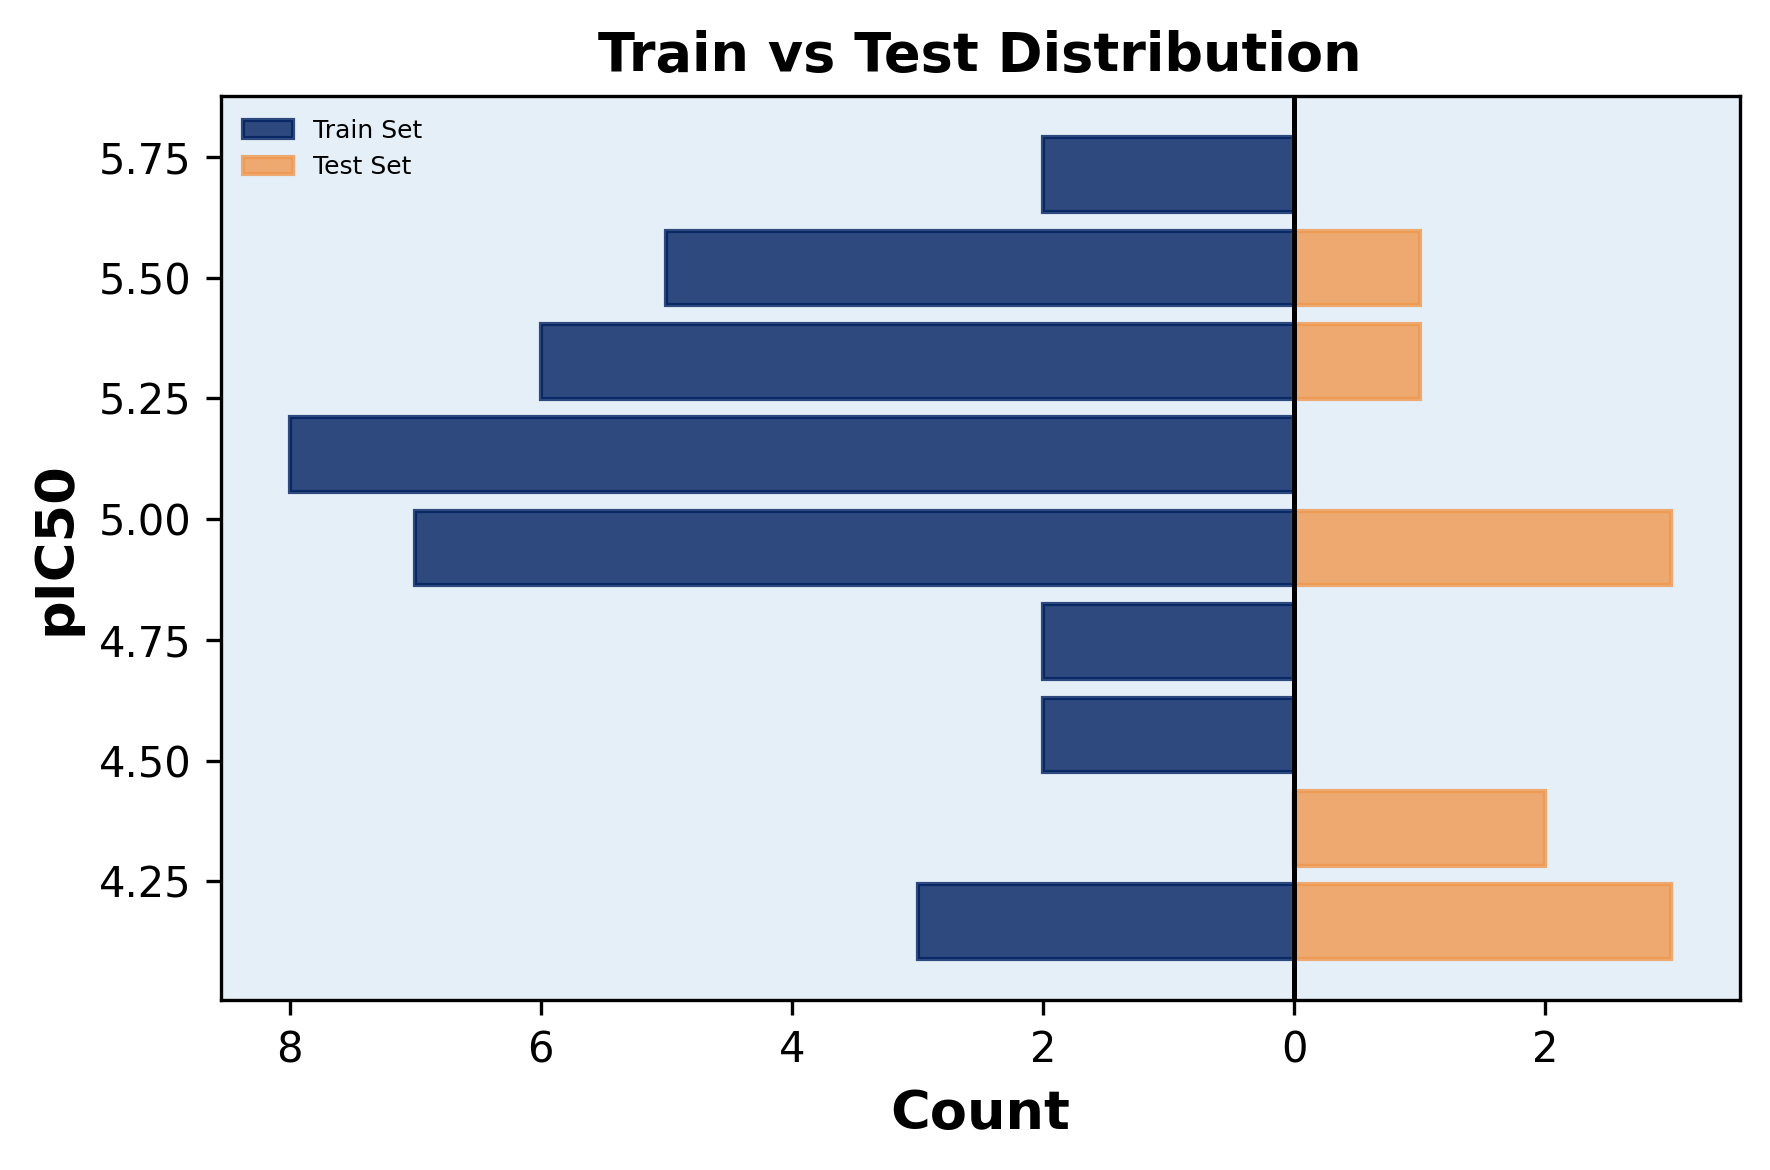

In [ ]:
plot_back_to_back_histogram(y_train, y_test)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'train': '#002060',
        'test': '#f0984d'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test):

    fig = plt.figure(figsize=(7, 4), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.45)

    # ===================== LEFT: PARITY =====================
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(scheme['bg'])

    # Scatter
    ax1.scatter(y_train, y_pred_train,
                color=scheme['train'], label='Train Set', alpha=0.8)

    ax1.scatter(y_test, y_pred_test,
                color=scheme['test'], marker='^', label='Test Set', alpha=0.9)

    # Diagonal
    ax1.plot([4, 6], [4, 6], color='black', linewidth=1)

    # 🔥 FORCE RANGE 4–6
    ax1.set_xlim(4, 6)
    ax1.set_ylim(4, 6)

    ax1.set_xticks(np.arange(4, 6.1, 0.5))
    ax1.set_yticks(np.arange(4, 6.1, 0.5))

    # Labels (🔥 closer y-label)
    ax1.set_xlabel('Exp. pIC50', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Pred. pIC50',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=5)

    ax1.legend(loc="upper left", frameon=False, fontsize=6)
    ax1.grid(False)

    # ===================== RIGHT: RESIDUALS =====================
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(scheme['bg'])

    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Boxplot
    box = ax2.boxplot([residuals_test, residuals_train],
                      patch_artist=True,
                      labels=['Test', 'Train'],
                      widths=0.5)

    box['boxes'][0].set_facecolor(scheme['test'])
    box['boxes'][1].set_facecolor(scheme['train'])

    for patch in box['boxes']:
        patch.set_alpha(0.5)

    # Scatter
    jitter_test = np.random.normal(1, 0.05, size=len(residuals_test))
    jitter_train = np.random.normal(2, 0.05, size=len(residuals_train))

    ax2.scatter(jitter_test, residuals_test,
                color='green', alpha=0.7, s=20, zorder=3)

    ax2.scatter(jitter_train, residuals_train,
                color='purple', alpha=0.7, s=20, zorder=3)

    # Y range
    ax2.set_ylim(-1, 1)
    ax2.set_yticks(np.linspace(-1, 1, 5))

    ax2.set_ylabel('Residuals',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=2)

    ax2.tick_params(labelsize=10)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

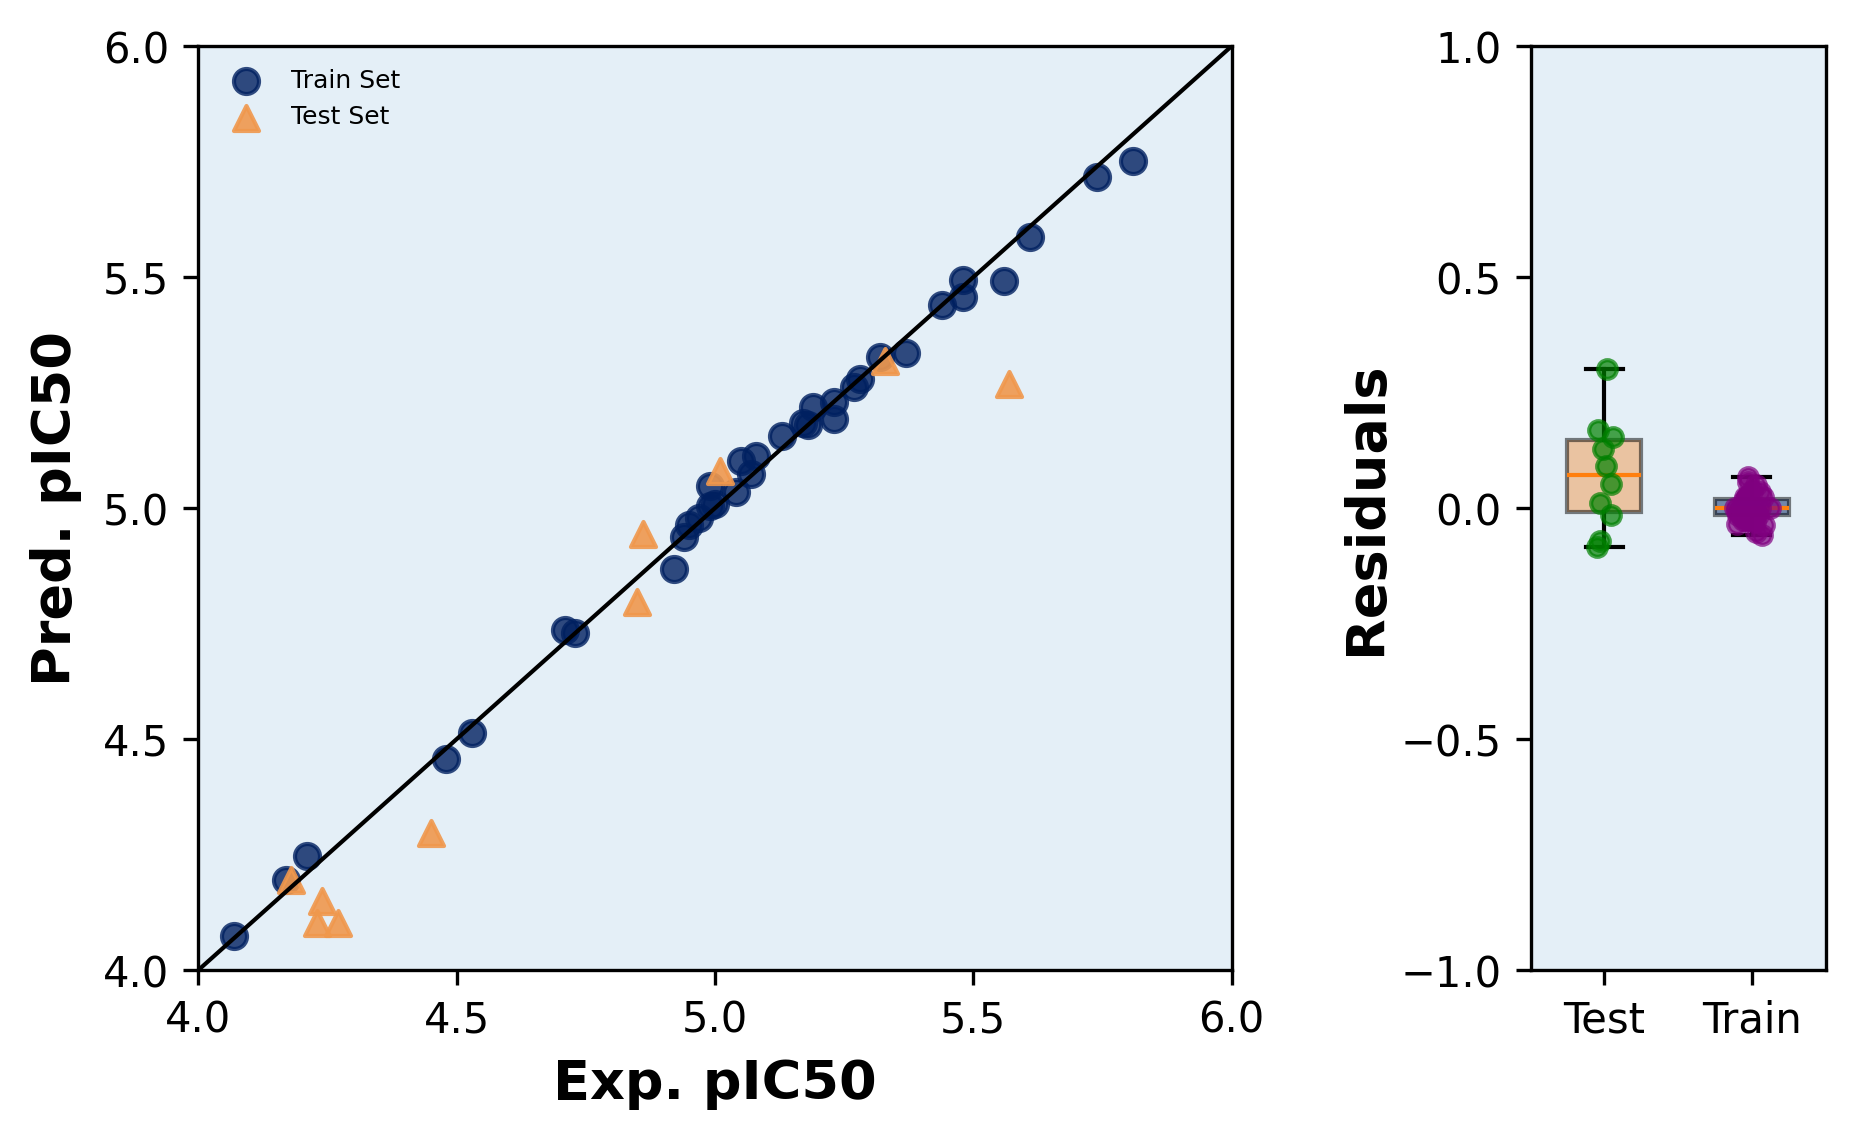

In [ ]:
plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'r2': '#002060',
        'rmse': '#f0984d',
        'mae': '#7a8e9e',
        'q2': '#a2c6d4'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_metrics_bar_chart(r2_train, rmse_train, mae_train, q2_train,
                           r2_test, rmse_test, mae_test, q2_test):

    # Labels (top → bottom)
    labels = [
        'R² (Train)', 'RMSE (Train)', 'MAE (Train)', 'Q² (Train)',
        'R² (Test)', 'RMSE (Test)', 'MAE (Test)', 'Q² (Test)'
    ]

    values = [
        r2_train, rmse_train, mae_train, q2_train,
        r2_test, rmse_test, mae_test, q2_test
    ]

    colors = [
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2'],
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2']
    ]

    # Positions (spacing between Train and Test)
    y_pos = [1, 2, 3, 4, 6, 7, 8, 9]

    # ===================== FIGURE =====================
    fig = plt.figure(figsize=(6.5, 6), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 2.5], wspace=0)

    # ===================== LEFT PANEL (TABLE) =====================
    ax_tab = fig.add_subplot(gs[0])
    ax_tab.set_xlim(0, 1)
    ax_tab.set_ylim(0.5, 9.5)
    ax_tab.axis('off')

    # ---- OUTER BORDER ----
    ax_tab.plot([0.05, 0.95], [0.5, 0.5], color='black', linewidth=2)   # bottom
    ax_tab.plot([0.05, 0.95], [9.5, 9.5], color='black', linewidth=2)   # top
    ax_tab.plot([0.05, 0.05], [0.5, 9.5], color='black', linewidth=2)   # left
    ax_tab.plot([0.95, 0.95], [0.5, 9.5], color='black', linewidth=2)   # right

    # ---- INNER VERTICAL DIVIDER ----
    ax_tab.plot([0.3, 0.3], [0.5, 9.5], color='black', linewidth=1.5)

    # ---- HORIZONTAL LINES ----
    for y in [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]:
        ax_tab.plot([0.3, 0.95], [y, y], color='black', linewidth=1)

    # ---- GROUP DIVIDER ----
    ax_tab.plot([0.05, 0.95], [5.0, 5.0], color='black', linewidth=2)

    # ---- SECTION LABELS ----
    ax_tab.text(0.17, 2.5, 'Train',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    ax_tab.text(0.17, 7.5, 'Test',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    # ---- METRIC LABELS ----
    for y, label in zip(y_pos, labels):
        ax_tab.text(0.4, y, label,
                    va='center', ha='left',
                    fontsize=9, fontweight='bold')

    # ===================== RIGHT PANEL (BARS) =====================
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.set_facecolor(scheme['bg'])

    ax_bar.barh(y_pos, values, color=colors, alpha=0.85)

    ax_bar.set_ylim(0.5, 9.5)
    ax_bar.set_xlim(0, max(values) * 1.2)

    # Remove y ticks (handled by table)
    ax_bar.set_yticks([])

    # Labels
    ax_bar.set_xlabel('Metric Value', fontsize=13, fontweight='bold')

    # Clean look
    ax_bar.grid(False)

    # Layout
    plt.tight_layout()
    plt.show()

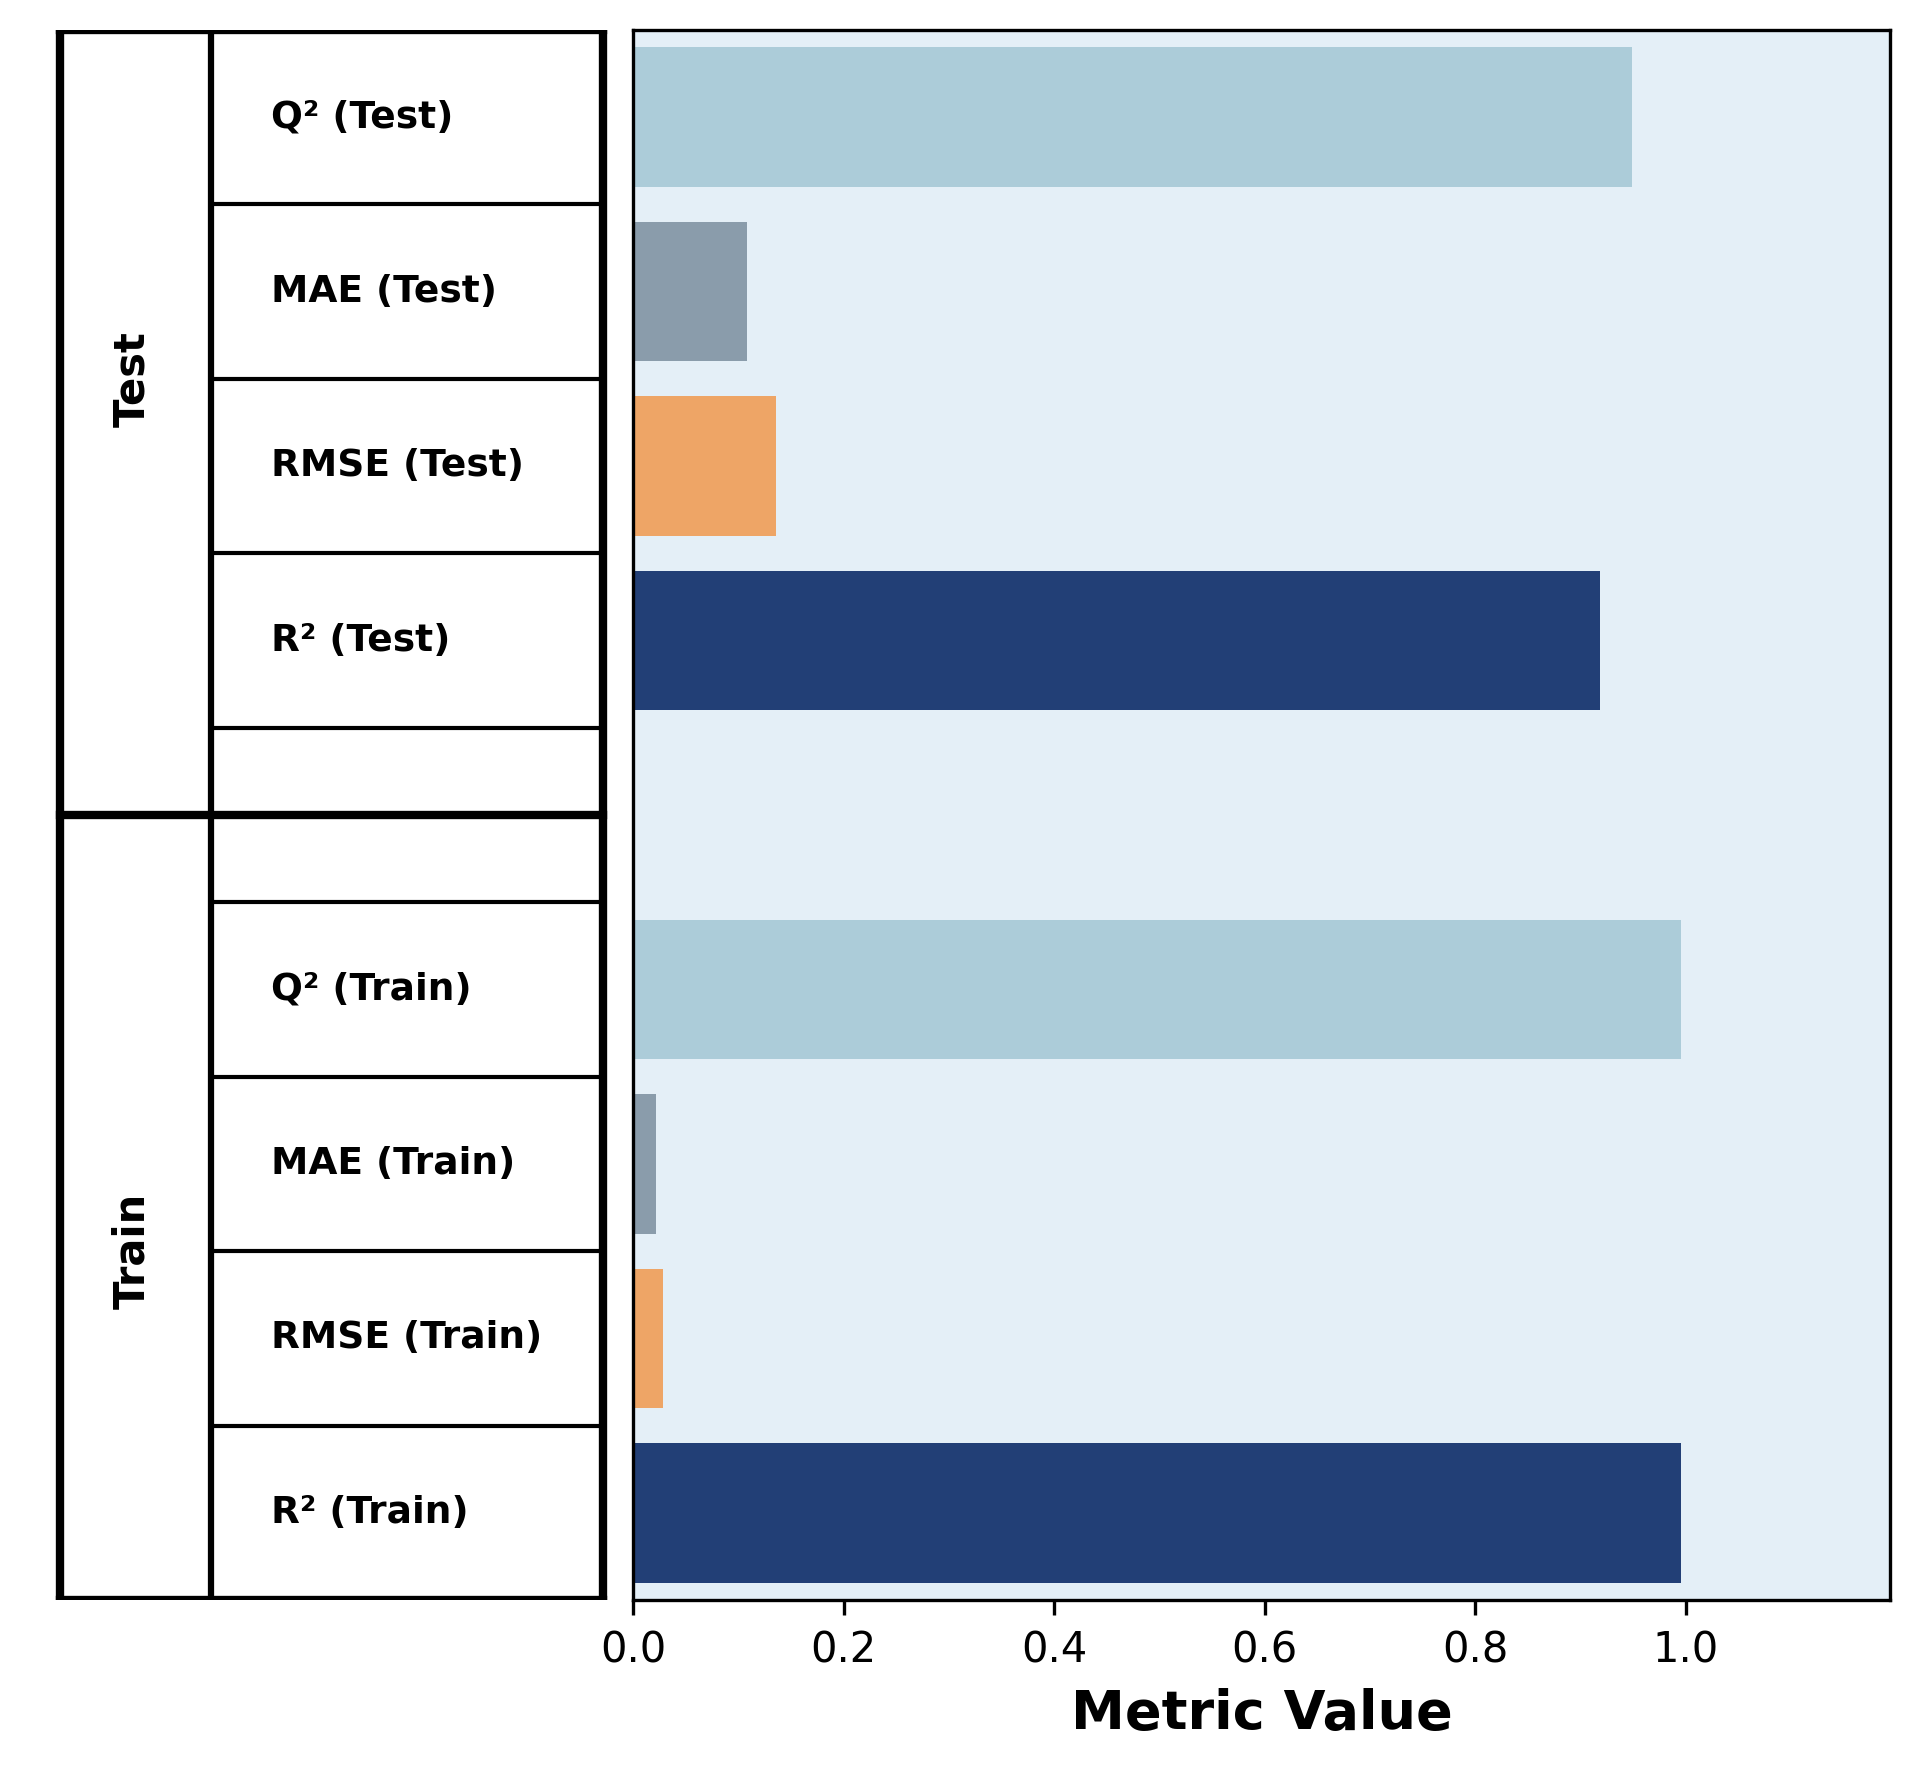

In [ ]:
plot_metrics_bar_chart(
    r2_train, rmse_train, mae_train, q2_train,
    r2_test, rmse_test, mae_test, q2_test
)

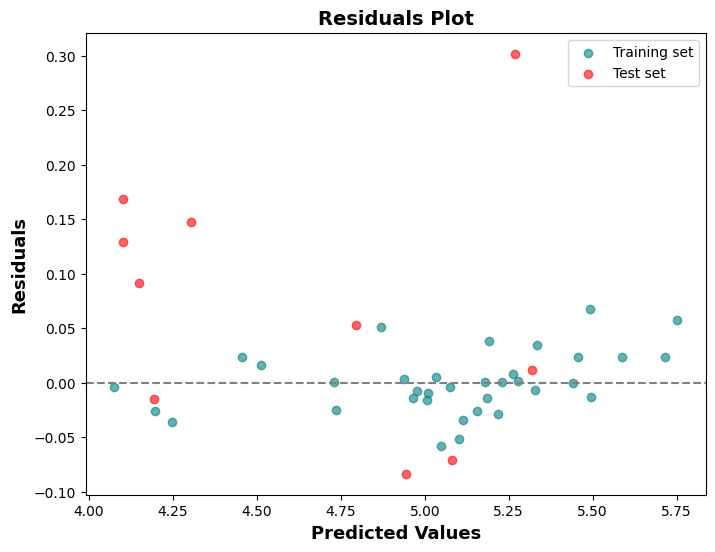

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Ensure that both the training and test residuals arrays are of the same length when combined
# Combine both train and test results into a single DataFrame for saving
residuals_combined_df = pd.DataFrame({
    'Predicted': pd.concat([pd.Series(y_pred_train), pd.Series(y_pred_test)], ignore_index=True),
    'Residuals': pd.concat([pd.Series(residuals_train), pd.Series(residuals_test)], ignore_index=True)
})

# Save the DataFrame to a CSV file
residuals_combined_df.to_csv('/content/drive/MyDrive/Eng/VIF/GBR_RESIDUAL.csv', index=False)

# Plot residuals for training and test sets
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_train, residuals_train, color='teal', label='Training set', alpha=0.6)
plt.scatter(y_pred_test, residuals_test, color='red', label='Test set', alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Values', fontsize=13, fontweight='bold')
plt.ylabel('Residuals', fontsize=13, fontweight='bold')
plt.title('Residuals Plot', fontsize=14, fontweight='bold')
plt.legend()
plt.show()


Randomization

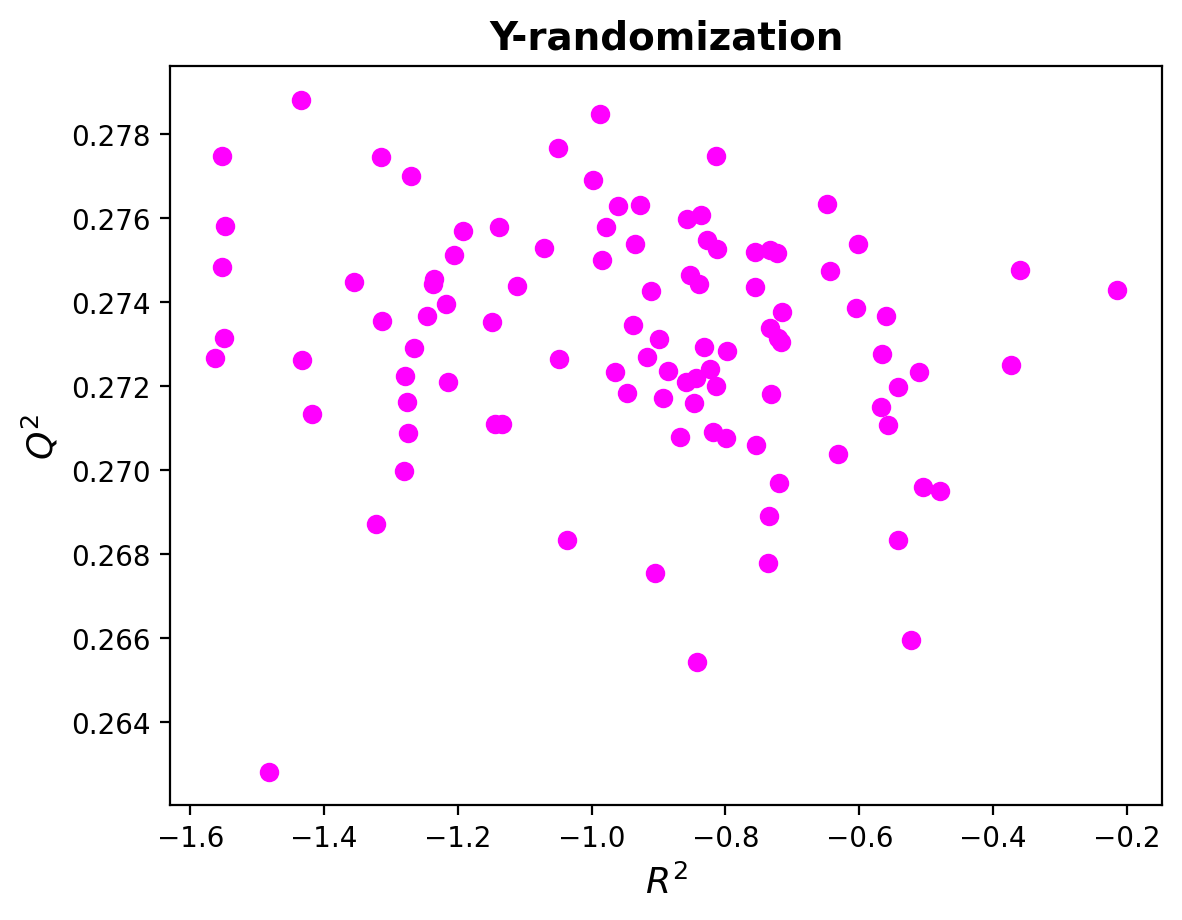

Y-randomization results have been saved as 'y_randomization_results.csv'.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict
from sklearn.utils import shuffle


# Define the best hyperparameters from Optuna
best_params = {
    'n_estimators': 291,
    'max_depth': 4,
    'min_samples_split': 12,
    'learning_rate': 0.040707962834868626
}

# Y-randomization
n_iterations = 100
r2_scores = []
q2_scores = []

for i in range(n_iterations):
    # Shuffle the target variable (y_train)
    y_random = shuffle(y_train, random_state=i)

    # Train the model with the shuffled target variable
    model_random = GradientBoostingRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        learning_rate=best_params['learning_rate'],
        loss="squared_error"
    ).fit(X_train, y_random)

    # Predict on the training data
    y_pred_random = model_random.predict(X_train)

    # Calculate R^2 for the random model on training data
    r2_random = r2_score(y_train, y_pred_random)

    # Perform cross-validated predictions and calculate Q^2
    y_cv_pred = cross_val_predict(model_random, X_train, y_train, cv=5)
    q2_random = r2_score(y_train, y_cv_pred)

    # Append the scores
    r2_scores.append(r2_random)
    q2_scores.append(q2_random)

# Create a DataFrame for the results
results_df = pd.DataFrame({
    'R^2_Score': r2_scores,
    'Q^2_Score': q2_scores
})

# Save the results to a CSV file in your directory
results_df.to_csv('/content/drive/MyDrive/Eng/VIF/NEW_GBR_randomization.csv', index=False)

# Plotting Y-randomization
plt.scatter(r2_scores, q2_scores, color='magenta')
plt.xlabel('$R^2$', fontsize=13, fontweight='bold')
plt.ylabel('$Q^2$', fontsize=13, fontweight='bold')
plt.title('Y-randomization', fontsize=14, fontweight='bold')
plt.show()

print("Y-randomization results have been saved as 'y_randomization_results.csv'.")


FOR NEWLY DESIGNED COMPOUNDS

From Dr. Ismail

In [ ]:
import pandas as pd

# =========================================================
# Data for the new compounds
# =========================================================
data = {
    'AlogP98': [
        3.3981, 3.9027, 4.350201, 4.893101, 4.8091,
        4.893101, 4.893101, 4.6309, 4.6309, 4.6309,
        4.427301, 4.6309, 4.350201, 4.6309, 4.350201
    ],

    'MD': [
        0.96735693, 0.97647753, 1.00325309, 1.18525375, 1.03707912,
        1.18856118, 1.18629117, 0.94785099, 0.93952102, 0.93884360,
        0.94653983, 0.94755640, 1.00360427, 0.94958405, 0.99958946
    ],

    'SA_ZX': [
        50.31901640, 52.60293463, 49.26119379, 54.76106916, 51.60508907,
        52.95117758, 53.93863789, 50.65598915, 51.62144804, 54.14322476,
        50.98444453, 50.73821449, 48.96092476, 51.09653059, 49.83846852
    ]
}

# =========================================================
# Create DataFrame
# =========================================================
new_compounds = pd.DataFrame(
    data,
    index=[
        'd7', 'd10', 'd8', 'd9', 'd11',
        'd12', 'd13', 'd14', 'd15', 'd1',
        'd2', 'd3', 'd4', 'd5', 'd6'
    ]
)

# =========================================================
# Predict target values using trained model
# =========================================================
predictions = best_model.predict(new_compounds)

# =========================================================
# Display predictions
# =========================================================
for compound, pred in zip(new_compounds.index, predictions):
    print(f"Predicted target for {compound}: {pred:.3f}")

Predicted target for d7: 4.184
Predicted target for d10: 4.184
Predicted target for d8: 4.052
Predicted target for d9: 4.155
Predicted target for d11: 4.110
Predicted target for d12: 4.159
Predicted target for d13: 4.155
Predicted target for d14: 4.052
Predicted target for d15: 4.052
Predicted target for d1: 4.052
Predicted target for d2: 4.052
Predicted target for d3: 4.052
Predicted target for d4: 4.052
Predicted target for d5: 4.052
Predicted target for d6: 4.052


In [ ]:
import pandas as pd

# =========================================================
# Data for the new compounds
# =========================================================
data = {
    'AlogP98': [
        9.708302, 6.1903, 6.654, 7.5718, 6.000801,
        6.567401, 9.027404, 9.329204, 5.8112, 6.2749,
        7.1927, 5.6217, 6.188303, 8.648304, 7.256103
    ],

    'MD': [
        1.12218569, 1.17536501, 1.22408798, 1.24426751, 1.18391566,
        1.13811529, 1.10442078, 1.11609443, 1.18681543, 1.22806527,
        1.25444479, 1.17812242, 1.13757407, 1.10452088, 1.12591135
    ],

    'SA_ZX': [
        90.58956151, 75.52683424, 66.70418791, 78.15935569, 75.51079685,
        79.45335005, 102.3870262, 75.99447656, 66.91226833, 67.38648928,
        68.74155173, 71.84652863, 75.19786888, 94.5760726, 84.4862996
    ]
}

# =========================================================
# Create DataFrame
# =========================================================
new_compounds = pd.DataFrame(
    data,
    index=[
        'N1', 'N2', 'N3', 'N4', 'N5',
        'N6', 'N7', 'N8', 'N9', 'N10',
        'N11', 'N12', 'N13', 'N14', 'N15'
    ]
)

# =========================================================
# Predict target values using trained model
# =========================================================
predictions = best_model.predict(new_compounds)

# =========================================================
# Display predictions
# =========================================================
for compound, pred in zip(new_compounds.index, predictions):
    print(f'Predicted target for {compound}: {pred:.3f}')

Predicted target for N1: 5.717
Predicted target for N2: 5.222
Predicted target for N3: 5.048
Predicted target for N4: 5.349
Predicted target for N5: 5.242
Predicted target for N6: 5.131
Predicted target for N7: 5.494
Predicted target for N8: 5.435
Predicted target for N9: 4.960
Predicted target for N10: 5.073
Predicted target for N11: 5.157
Predicted target for N12: 5.545
Predicted target for N13: 5.210
Predicted target for N14: 5.501
Predicted target for N15: 5.336


In [ ]:
import pandas as pd

# =========================================================
# Updated Data
# =========================================================
data = {
    'AlogP98': [
        10.077603,
        9.993603,
        10.658003,
        10.658003,
        7.890101,
        5.742801,
        9.913802,
        10.372704,
        7.640302,
        10.164501,
        9.743103
    ],

    'MD': [
        1.22053114,
        1.15137634,
        1.18287890,
        1.18228654,
        1.26459174,
        1.17186046,
        1.14041905,
        1.15501909,
        1.13980096,
        1.10576567,
        1.10551116
    ],

    'SA_ZX': [
        77.3567,
        81.82338,
        79.18326,
        79.30468,
        75.80401,
        69.99043,
        84.13816,
        85.01717,
        92.07491,
        96.78224,
        92.13177
    ]
}

# =========================================================
# Create DataFrame
# =========================================================
new_compounds = pd.DataFrame(
    data,
    index=[
        'D1', 'D2', 'D3', 'D4', 'D5',
        'D6', 'D8', 'D9', 'D17', 'D18',
        'D19'
    ]
)

# =========================================================
# Predict target values
# =========================================================
predictions = best_model.predict(new_compounds)

for compound, pred in zip(new_compounds.index, predictions):
    print(f'Predicted target for {compound}: {pred:.3f}')

Predicted target for D1: 5.465
Predicted target for D2: 5.218
Predicted target for D3: 5.440
Predicted target for D4: 5.440
Predicted target for D5: 5.381
Predicted target for D6: 4.984
Predicted target for D8: 5.252
Predicted target for D9: 5.220
Predicted target for D17: 5.195
Predicted target for D18: 5.497
Predicted target for D19: 5.499


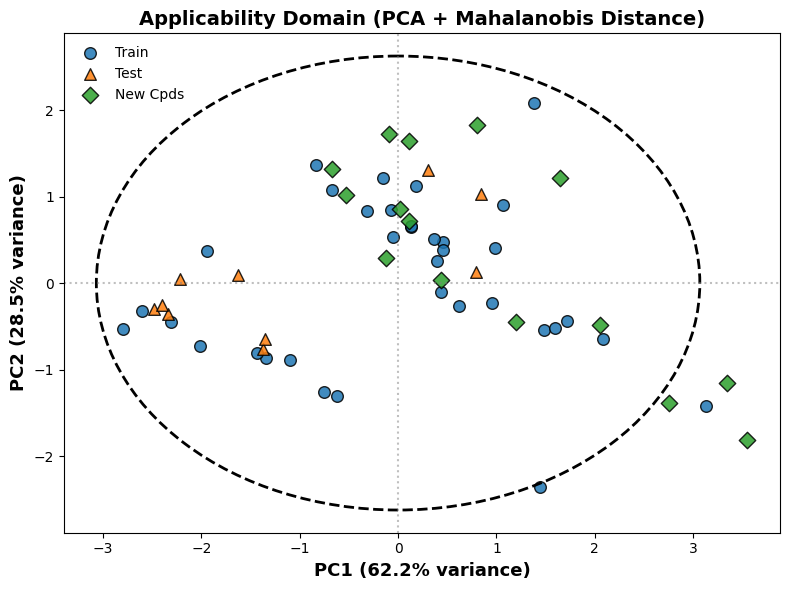

Chi-square level: 0.95
Threshold (MD²): 5.9915
Train outliers : 2 / 35
Test outliers  : 0 / 10
New compound outliers : 3 / 15


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf

from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from scipy.linalg import eigh
from matplotlib.patches import Ellipse


# =========================================================
# SETTINGS
# =========================================================
PCA_NCOMP = 2
CHI2_LEVEL = 0.95
LABEL_OUTLIERS = True
PLOT_LOADINGS = False
LOADING_SCALE = 2.0
DESIGNED_CSV_PATH = "./designed-desc.csv"
FIGSIZE = (8, 6)


# =========================================================
# HELPER FUNCTION: Convert to DataFrame
# =========================================================
def to_dataframe(X, feature_labels=None, name_prefix="x"):

    if isinstance(X, pd.DataFrame):
        return X.copy()

    X_np = np.asarray(X)

    n_features = X_np.shape[1]

    if feature_labels is not None and len(feature_labels) == n_features:

        cols = list(feature_labels)

    else:

        cols = [f"{name_prefix}{i}" for i in range(n_features)]

    return pd.DataFrame(X_np, columns=cols)


# =========================================================
# HELPER FUNCTION: Plot ellipse
# =========================================================
def plot_mahalanobis_ellipse(mean, cov, threshold, ax, **kwargs):

    vals, vecs = eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    width, height = 2 * np.sqrt(vals * threshold)

    angle = np.degrees(
        np.arctan2(*vecs[:, 0][::-1])
    )

    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )

    ax.add_patch(ell)


# =========================================================
# FEATURE LABELS
# =========================================================
feature_labels_local = None

try:

    feature_labels_local = feature_labels

except NameError:

    feature_labels_local = None


# =========================================================
# TRAIN / TEST DATAFRAME
# =========================================================
X_train_df = to_dataframe(
    X_train,
    feature_labels_local,
    name_prefix="f"
)

X_test_df = to_dataframe(
    X_test,
    X_train_df.columns.tolist(),
    name_prefix="f"
)

# Ensure same order
X_test_df = X_test_df[
    X_train_df.columns
]


# =========================================================
# OPTIONAL DESIGNED SET
# =========================================================
X_design_df = None

try:

    df_design_raw = pd.read_csv(
        DESIGNED_CSV_PATH,
        index_col=0
    )

    missing = [
        c for c in X_train_df.columns
        if c not in df_design_raw.columns
    ]

    if len(missing) == 0:

        X_design_df = df_design_raw[
            X_train_df.columns
        ].copy()

    else:

        print("Designed set missing descriptors.")
        X_design_df = None

except Exception:

    X_design_df = None


# =========================================================
# NEW COMPOUNDS
# =========================================================
new_compounds_data = {

    'AlogP98': [
        9.708302, 6.1903, 6.654, 7.5718, 6.000801,
        6.567401, 9.027404, 9.329204, 5.8112, 6.2749,
        7.1927, 5.6217, 6.188303, 8.648304, 7.256103
    ],

    'MD': [
        1.12218569, 1.17536501, 1.22408798, 1.24426751, 1.18391566,
        1.13811529, 1.10442078, 1.11609443, 1.18681543, 1.22806527,
        1.25444479, 1.17812242, 1.13757407, 1.10452088, 1.12591135
    ],

    'SA_ZX': [
        90.58956151, 75.52683424, 66.70418791, 78.15935569, 75.51079685,
        79.45335005, 102.3870262, 75.99447656, 66.91226833, 67.38648928,
        68.74155173, 71.84652863, 75.19786888, 94.5760726, 84.4862996
    ]
}

X_new_df = pd.DataFrame(
    new_compounds_data,
    index=[
        'N1', 'N2', 'N3', 'N4', 'N5',
        'N6', 'N7', 'N8', 'N9', 'N10',
        'N11', 'N12', 'N13', 'N14', 'N15'
    ]
)

# Ensure same descriptor order
X_new_df = X_new_df[
    X_train_df.columns
]


# =========================================================
# SCALING
# =========================================================
scaler_local = None

try:

    scaler_local = scaler

except NameError:

    scaler_local = None

if scaler_local is None:

    scaler_local = StandardScaler()

    X_train_scaled = scaler_local.fit_transform(
        X_train_df.values
    )

else:

    X_train_scaled = scaler_local.transform(
        X_train_df.values
    )

X_test_scaled = scaler_local.transform(
    X_test_df.values
)

X_new_scaled = scaler_local.transform(
    X_new_df.values
)

if X_design_df is not None:

    X_design_scaled = scaler_local.transform(
        X_design_df.values
    )


# =========================================================
# PCA
# =========================================================
pca_local = None

try:

    pca_local = pca

except NameError:

    pca_local = None

if pca_local is None:

    pca_local = PCA(
        n_components=PCA_NCOMP,
        random_state=0
    )

    X_train_pca_full = pca_local.fit_transform(
        X_train_scaled
    )

else:

    X_train_pca_full = pca_local.transform(
        X_train_scaled
    )

X_test_pca_full = pca_local.transform(
    X_test_scaled
)

X_new_pca_full = pca_local.transform(
    X_new_scaled
)

X_train_pca = X_train_pca_full[:, :2]
X_test_pca = X_test_pca_full[:, :2]
X_new_pca = X_new_pca_full[:, :2]

if X_design_df is not None:

    X_design_pca_full = pca_local.transform(
        X_design_scaled
    )

    X_design_pca = X_design_pca_full[:, :2]


# =========================================================
# ROBUST MAHALANOBIS DISTANCE
# =========================================================
lw = LedoitWolf().fit(
    X_train_pca
)

mean_vec = lw.location_

cov_matrix = lw.covariance_

epsilon = 1e-8

cov_matrix = cov_matrix + (
    np.eye(cov_matrix.shape[0]) * epsilon
)

inv_cov = np.linalg.inv(
    cov_matrix
)

md_train = np.array([
    mahalanobis(x, mean_vec, inv_cov)
    for x in X_train_pca
])

md_test = np.array([
    mahalanobis(x, mean_vec, inv_cov)
    for x in X_test_pca
])

md_new = np.array([
    mahalanobis(x, mean_vec, inv_cov)
    for x in X_new_pca
])

if X_design_df is not None:

    md_design = np.array([
        mahalanobis(x, mean_vec, inv_cov)
        for x in X_design_pca
    ])

threshold = chi2.ppf(
    CHI2_LEVEL,
    df=2
)


# =========================================================
# BUILD PLOT DATAFRAMES
# =========================================================
train_index = X_train_df.index
test_index = X_test_df.index

df_train_plot = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=train_index
)

df_train_plot["Group"] = "Train"

df_train_plot["MD2"] = md_train ** 2

df_train_plot["Outlier-MD"] = (
    df_train_plot["MD2"] > threshold
)

df_test_plot = pd.DataFrame(
    X_test_pca,
    columns=["PC1", "PC2"],
    index=test_index
)

df_test_plot["Group"] = "Test"

df_test_plot["MD2"] = md_test ** 2

df_test_plot["Outlier-MD"] = (
    df_test_plot["MD2"] > threshold
)

df_new_plot = pd.DataFrame(
    X_new_pca,
    columns=["PC1", "PC2"],
    index=X_new_df.index
)

df_new_plot["Group"] = "New Compounds"

df_new_plot["MD2"] = md_new ** 2

df_new_plot["Outlier-MD"] = (
    df_new_plot["MD2"] > threshold
)

df_plot = pd.concat([
    df_train_plot,
    df_test_plot,
    df_new_plot
])

if X_design_df is not None:

    df_design_plot = pd.DataFrame(
        X_design_pca,
        columns=["PC1", "PC2"],
        index=X_design_df.index
    )

    df_design_plot["Group"] = "Designed"

    df_design_plot["MD2"] = md_design ** 2

    df_design_plot["Outlier-MD"] = (
        df_design_plot["MD2"] > threshold
    )

    df_plot = pd.concat([
        df_plot,
        df_design_plot
    ])


# =========================================================
# PLOT
# =========================================================
fig, ax = plt.subplots(
    figsize=FIGSIZE
)

group_styles = {

    "Train": {
        "marker": "o",
        "label": "Train"
    },

    "Test": {
        "marker": "^",
        "label": "Test"
    },

    "Designed": {
        "marker": "s",
        "label": "Designed"
    },

    "New Compounds": {
        "marker": "D",
        "label": "New Cpds"
    }
}

for group in df_plot["Group"].unique():

    style = group_styles.get(
        group,
        {
            "marker": "o",
            "label": group
        }
    )

    g = df_plot[
        df_plot["Group"] == group
    ]

    ax.scatter(
        g["PC1"],
        g["PC2"],
        marker=style["marker"],
        s=70,
        alpha=0.85,
        edgecolor="black",
        label=style["label"]
    )

# AD Ellipse
plot_mahalanobis_ellipse(
    mean=mean_vec,
    cov=cov_matrix,
    threshold=threshold,
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=2,
    ls="--"
)


# Optional loading plot
if PLOT_LOADINGS and hasattr(
    pca_local,
    "components_"
):

    loadings = (
        pca_local.components_[:2].T
    )

    cols = list(
        X_train_df.columns
    )

    for i, (x, y) in enumerate(loadings):

        ax.arrow(
            0,
            0,
            x * LOADING_SCALE,
            y * LOADING_SCALE,
            color="gray",
            alpha=0.7,
            head_width=0.06,
            head_length=0.08
        )

        ax.text(
            x * LOADING_SCALE * 1.08,
            y * LOADING_SCALE * 1.08,
            cols[i],
            fontsize=9
        )

# Axis lines
ax.axhline(
    0,
    color="gray",
    ls=":",
    alpha=0.5
)

ax.axvline(
    0,
    color="gray",
    ls=":",
    alpha=0.5
)

# Labels
try:

    pc1_var = (
        pca_local.explained_variance_ratio_[0] * 100
    )

    pc2_var = (
        pca_local.explained_variance_ratio_[1] * 100
    )

    ax.set_xlabel(
        f"PC1 ({pc1_var:.1f}% variance)",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel(
        f"PC2 ({pc2_var:.1f}% variance)",
        fontsize=13,
        fontweight="bold"
    )

except Exception:

    ax.set_xlabel(
        "PC1",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel(
        "PC2",
        fontsize=13,
        fontweight="bold"
    )

ax.set_title(
    "Applicability Domain (PCA + Mahalanobis Distance)",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    loc="upper left",
    frameon=False
)

plt.grid(False)

plt.tight_layout()

plt.show()


# =========================================================
# SUMMARY
# =========================================================
print(f"Chi-square level: {CHI2_LEVEL}")

print(f"Threshold (MD²): {threshold:.4f}")

print(
    f"Train outliers : "
    f"{int((df_train_plot['MD2'] > threshold).sum())} "
    f"/ {len(df_train_plot)}"
)

print(
    f"Test outliers  : "
    f"{int((df_test_plot['MD2'] > threshold).sum())} "
    f"/ {len(df_test_plot)}"
)

print(
    f"New compound outliers : "
    f"{int((df_new_plot['MD2'] > threshold).sum())} "
    f"/ {len(df_new_plot)}"
)

if X_design_df is not None:

    print(
        f"Designed outliers : "
        f"{int((df_design_plot['MD2'] > threshold).sum())} "
        f"/ {len(df_design_plot)}"
    )

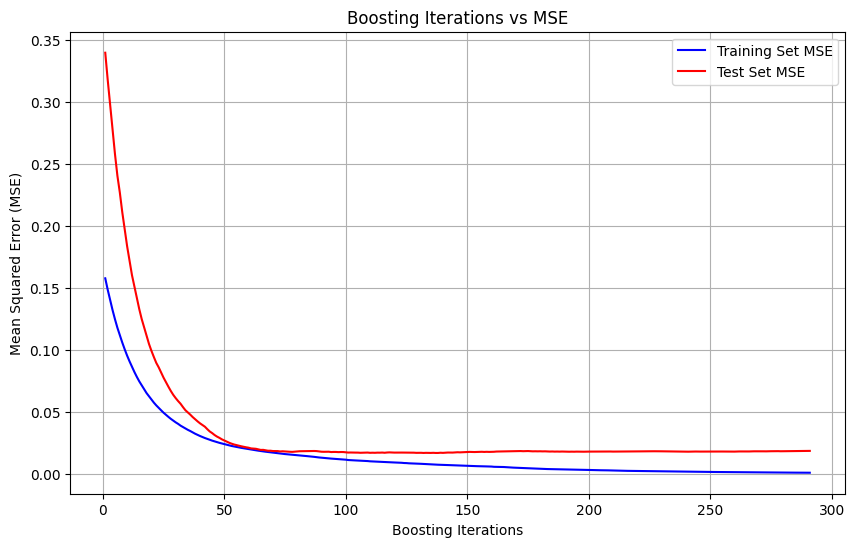

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Assuming best_params and best_model are already defined
test_score = np.zeros((best_params["n_estimators"],), dtype=np.float64)

# Using the best_model to compute test set scores for each boosting iteration
for i, y_pred in enumerate(best_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(np.arange(best_params["n_estimators"]) + 1, best_model.train_score_, 'b-', label='Training Set MSE')
plt.plot(np.arange(best_params["n_estimators"]) + 1, test_score, 'r-', label='Test Set MSE')
plt.title('Boosting Iterations vs MSE')
plt.xlabel('Boosting Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


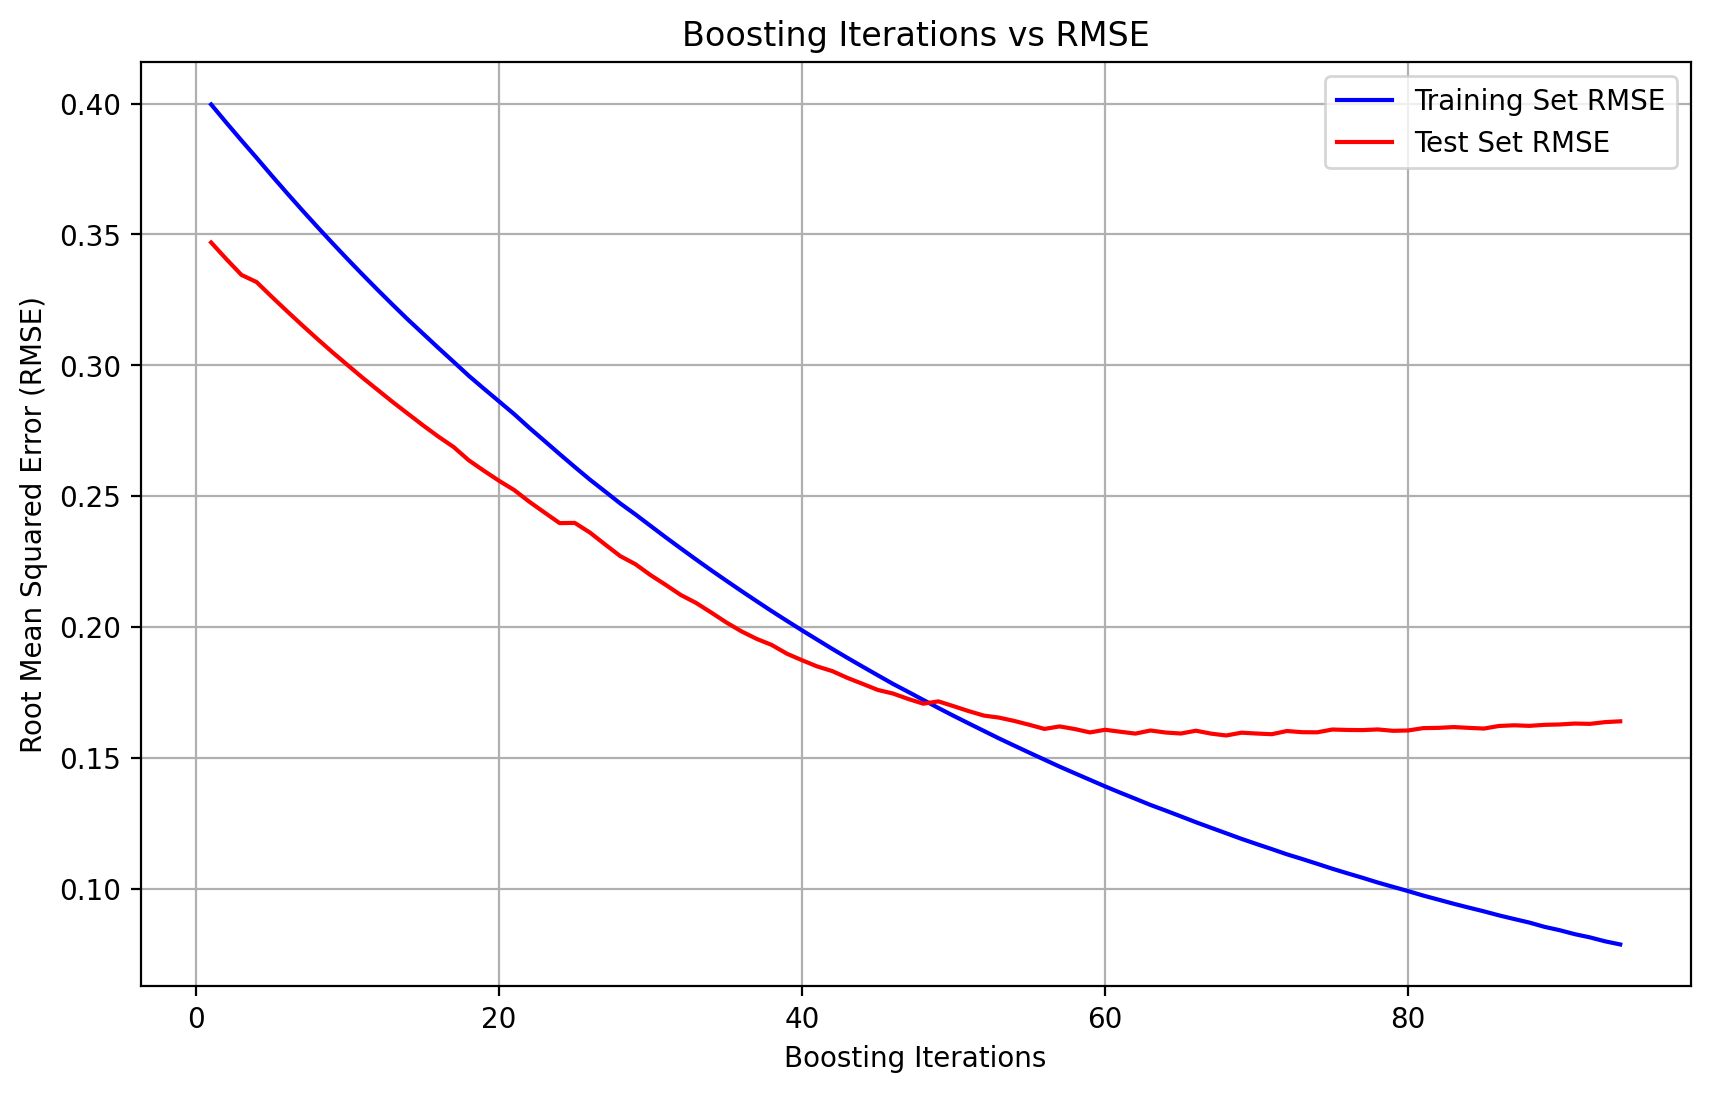

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Assuming best_params and best_model are already defined
test_score = np.zeros((best_params["n_estimators"],), dtype=np.float64)

# Using the best_model to compute test set RMSE for each boosting iteration
for i, y_pred in enumerate(best_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred) ** 0.5  # Compute RMSE

# Convert training MSE to RMSE
train_score_rmse = np.sqrt(best_model.train_score_)  # Convert stored MSE to RMSE

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(np.arange(best_params["n_estimators"]) + 1, train_score_rmse, 'b-', label='Training Set RMSE')
plt.plot(np.arange(best_params["n_estimators"]) + 1, test_score, 'r-', label='Test Set RMSE')
plt.title('Boosting Iterations vs RMSE')
plt.xlabel('Boosting Iterations')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Assuming best_params and best_model are already defined
test_score = np.zeros((best_params["n_estimators"],), dtype=np.float64)

# Using the best_model instead of GBR
for i, y_pred in enumerate(best_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

# Print the boosting iterations, training set scores, and test set scores
print("Boosting Iterations, Training Set Score, Test Set Score")
for i in range(best_params["n_estimators"]):
    print(f"{i+1}, {best_model.train_score_[i]}, {test_score[i]}")


Boosting Iterations, Training Set Score, Test Set Score
1, 0.1577038673791751, 0.33979145945655037
2, 0.148600696424133, 0.3180633378975505
3, 0.1402104674550696, 0.29779950679907763
4, 0.13212460134845205, 0.27715524314278533
5, 0.12467132042550481, 0.2579920964347354
6, 0.1178013661429123, 0.2404898619162053
7, 0.11191622715411959, 0.2269268382294111
8, 0.1059094250060293, 0.21112804799002988
9, 0.10043920280572723, 0.19708230496724008
10, 0.0953223447125534, 0.18362416337451276
11, 0.0906667032246038, 0.171714648974352
12, 0.08630626137094372, 0.16024317577037156
13, 0.08209013590511316, 0.15098947000786875
14, 0.07816417301725166, 0.1415420050019941
15, 0.0745513401688275, 0.13283269596151845
16, 0.07137391048782687, 0.12485399747400672
17, 0.06809459792234429, 0.11811159138104232
18, 0.06508216614140869, 0.11157134823372694
19, 0.06250080186201827, 0.10476588526868313
20, 0.05990920255801606, 0.0992310546862468
21, 0.05739815935651943, 0.09421817362854762
22, 0.055158028973628245,

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Assuming best_params and best_model are already defined
test_score = np.zeros((best_params["n_estimators"],), dtype=np.float64)

# Using the best_model instead of GBR
for i, y_pred in enumerate(best_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

# Prepare data for saving
data = {
    "Boosting Iterations": np.arange(1, best_params["n_estimators"] + 1),
    "Training Set Score": best_model.train_score_,
    "Test Set Score": test_score
}

# Create a DataFrame
output_df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
output_df.to_csv('/content/drive/MyDrive/Eng/VIF/NEW_GBRLOSS_OUT.csv', index=False)

print("Output saved to /content/drive/MyDrive/Eng/VIF/NEW_GBRLOSS_OUT.csv")


Output saved to /content/drive/MyDrive/Eng/VIF/NEW_GBRLOSS_OUT.csv


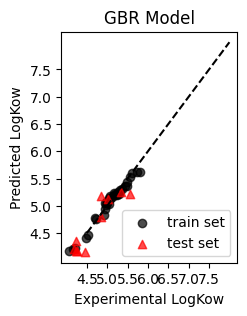

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data visualization
plt.figure(figsize=(5, 3))

# 1 row, 2 column, plot 1
plt.subplot(1, 2, 1)

plt.scatter(x=y_train, y=y_pred_train, c="black", alpha=0.7)
plt.scatter(x=y_test, y=y_pred_test, c="r", marker='^', alpha=0.7)

plt.legend(("train set", "test set"), loc="lower right")
plt.plot([4.5, 8], [4.5, 8], "--", color="black")

x_ticks = np.arange(4.5, 8, 0.5)
y_ticks = np.arange(4.5, 8, 0.5)

plt.xticks(x_ticks)
plt.yticks(y_ticks)

plt.title('GBR Model')
plt.ylabel('Predicted LogKow')
plt.xlabel('Experimental LogKow')

plt.show()


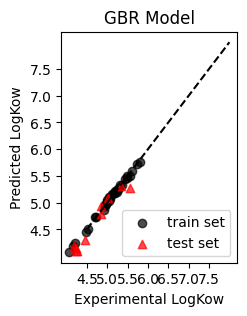

Plot saved to: /content/drive/MyDrive/Eng/VIF/PredVsExp_plot.png
CSV saved to: /content/drive/MyDrive/Eng/VIF/PredVsExp.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set figure size
plt.figure(figsize=(5, 3))

# Create subplot (1 row, 2 columns, first plot)
plt.subplot(1, 2, 1)

# Scatter plot for training and test data
plt.scatter(x=y_train, y=y_pred_train, c="black", alpha=0.7)
plt.scatter(x=y_test, y=y_pred_test, c="r", marker='^', alpha=0.7)

# Add legend
plt.legend(("train set", "test set"), loc="lower right")

# Add reference line (y = x)
plt.plot([4.5, 8], [4.5, 8], "--", color="black")

# Set x and y axis ticks
x_ticks = np.arange(4.5, 8, 0.5)
y_ticks = np.arange(4.5, 8, 0.5)
plt.xticks(x_ticks)
plt.yticks(y_ticks)

# Labels and title
plt.title('GBR Model')
plt.ylabel('Predicted LogKow')
plt.xlabel('Experimental LogKow')

# Save the plot as an image (e.g., PNG format)
plot_path = "/content/drive/MyDrive/Eng/VIF/PredVsExp_plot.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")  # Save with high resolution

# Show the plot
plt.show()

# Save the CSV file
output_df.to_csv('/content/drive/MyDrive/Eng/VIF/PredVsExp.csv', index=False)

print(f"Plot saved to: {plot_path}")
print("CSV saved to: /content/drive/MyDrive/Eng/VIF/PredVsExp.csv")


In [ ]:
!pip install shap

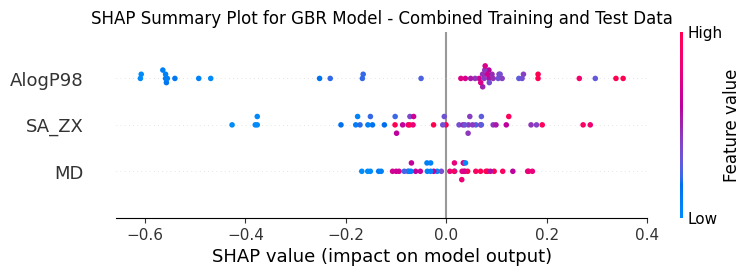

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Summary plot of combined SHAP values with feature names
shap.summary_plot(shap_values_combined, X_combined_df, show=False)
plt.title("SHAP Summary Plot for GBR Model - Combined Training and Test Data")
plt.show()

In [ ]:
import shap
import pandas as pd
import numpy as np

# Assume model, X_train, and X_test are already defined

# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Calculate mean absolute SHAP values to identify top 3 features
mean_abs_shap_values = np.mean(np.abs(shap_values_combined), axis=0)
top_3_indices = np.argsort(mean_abs_shap_values)[-5:]
top_3_features = X_combined_df.columns[top_3_indices]

# Create a DataFrame to store SHAP values and feature values for top 3 features
output_df = pd.DataFrame()

for i, feature in enumerate(top_3_features):
    output_df[f"{feature}_SHAP"] = shap_values_combined[:, top_3_indices[i]]
    output_df[f"{feature}_Value"] = X_combined_df[feature].values

# Specify the path to save the CSV file
output_path = '/content/drive/MyDrive/Eng/VIF/NEW_GBR_shap_values_features.csv'

# Save the DataFrame to the specified CSV file
output_df.to_csv(output_path, index=False)

print(f"CSV file saved as '{output_path}'")


CSV file saved as '/content/drive/MyDrive/Eng/VIF/NEW_GBR_shap_values_features.csv'


<Figure size 1600x1600 with 0 Axes>

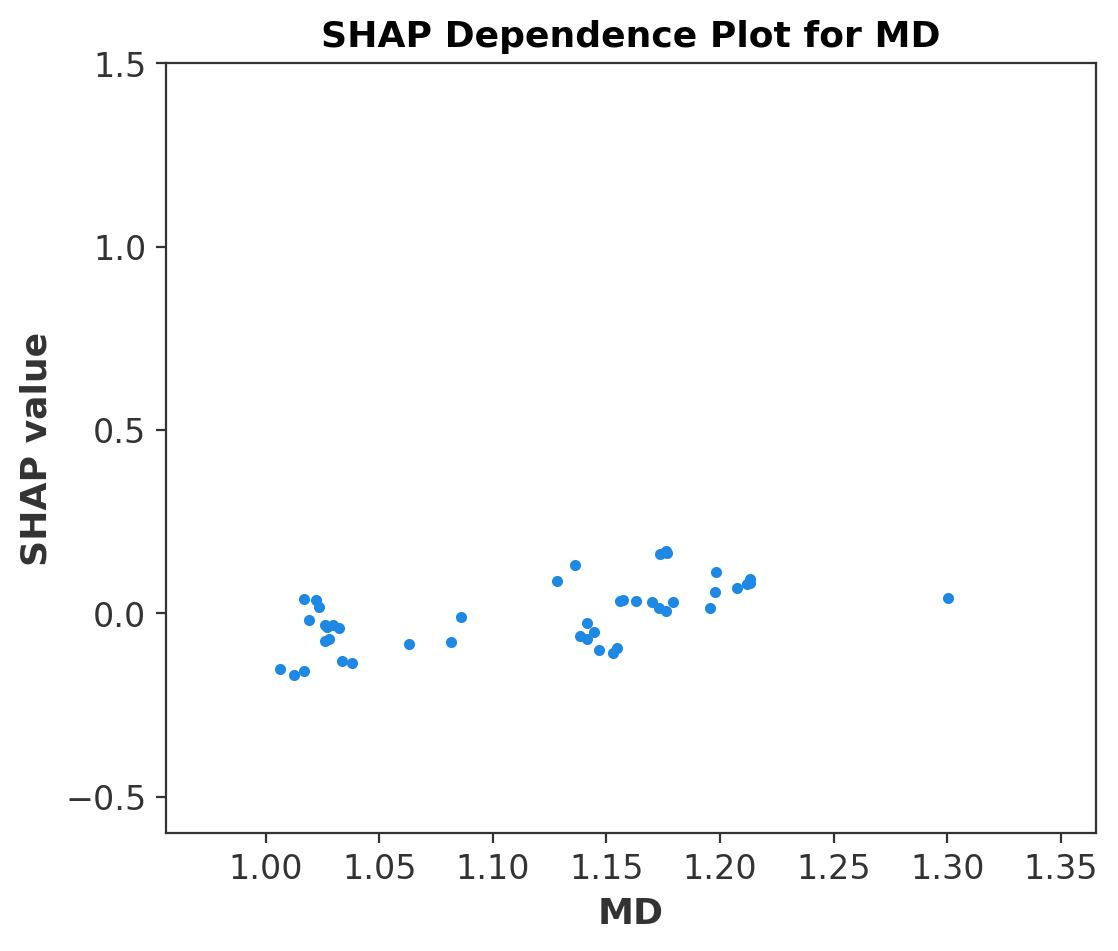

<Figure size 1600x1600 with 0 Axes>

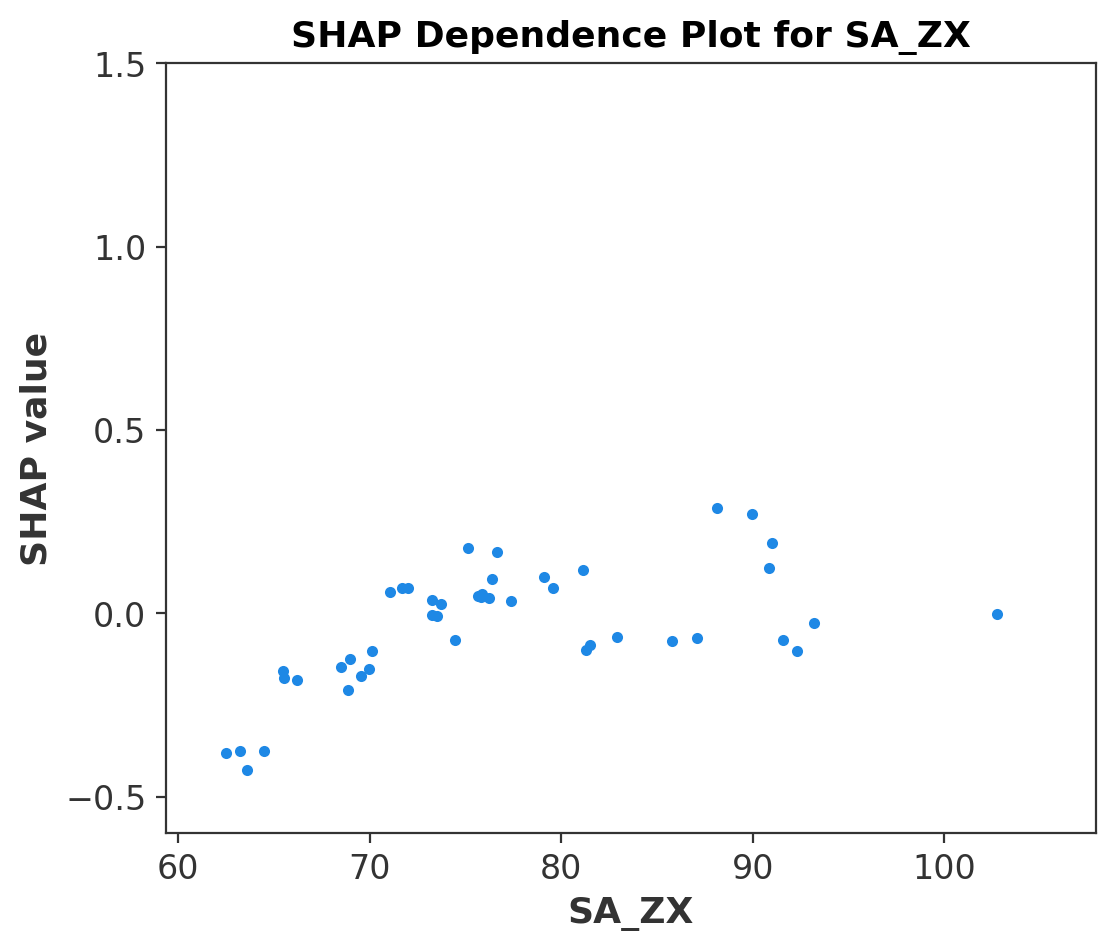

<Figure size 1600x1600 with 0 Axes>

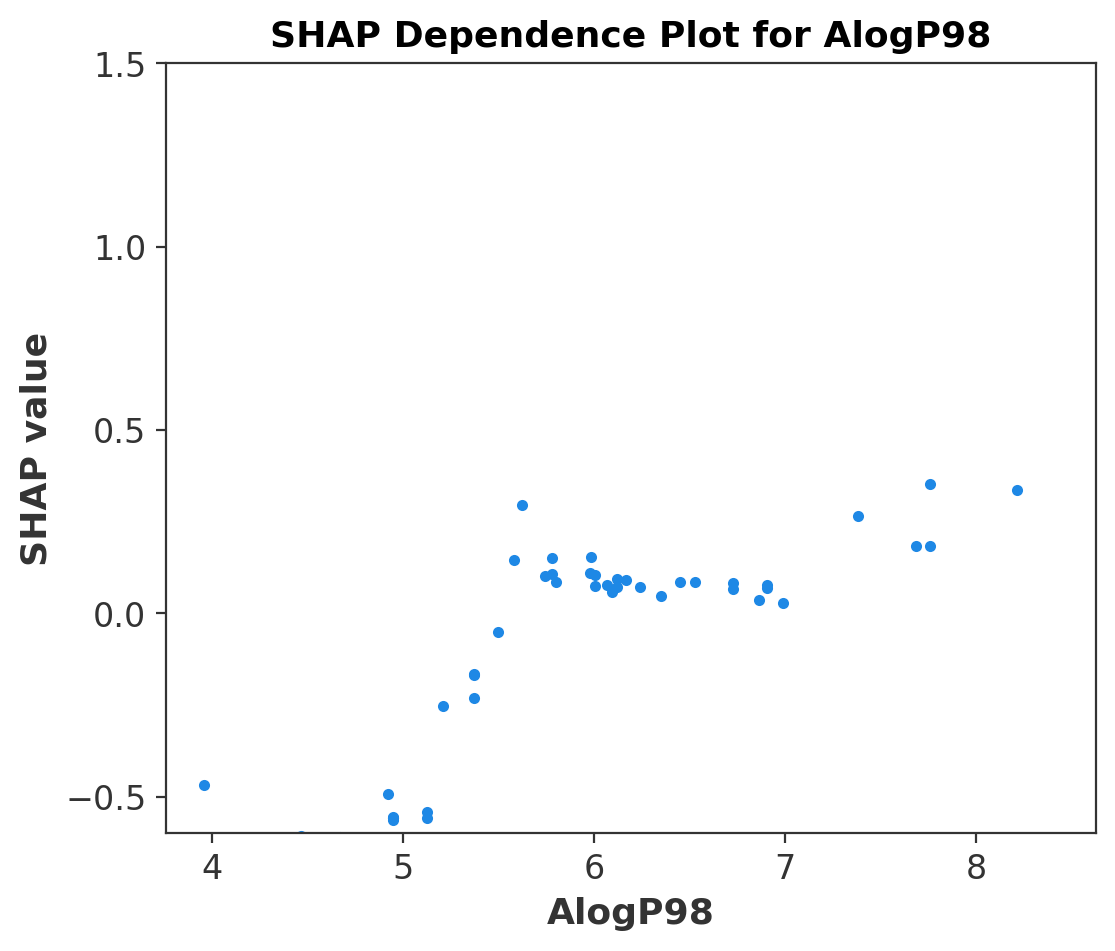

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assume model, X_train, and X_test are already defined

# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Calculate mean absolute SHAP values to identify top 3 features
mean_abs_shap_values = np.mean(np.abs(shap_values_combined), axis=0)
top_3_indices = np.argsort(mean_abs_shap_values)[-5:]
top_3_features = X_combined_df.columns[top_3_indices]

# Filter SHAP values and data for top 3 features
shap_values_combined_top3 = shap_values_combined[:, top_3_indices]
X_combined_df_top3 = X_combined_df.iloc[:, top_3_indices]

# Set up Matplotlib font properties
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 200

# Generate SHAP dependence plots for each of the top 3 features with square plots
for feature in top_3_features:
    plt.figure(figsize=(8, 8))  # Set square figure size (8x8 inches)

    # Create the SHAP dependence plot
    shap.dependence_plot(
        feature,
        shap_values_combined,
        X_combined_df,
        interaction_index=None,
        show=False
    )

    # Get current axes object
    ax = plt.gca()

    # Customize the spines to add axes on top and right
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # Set the aspect ratio to be square
    ax.set_aspect('auto')

    # Set y-ticks to range from -0.5 to 1.5
    plt.yticks(np.arange(-1.0, 1.6, 0.5), fontsize=12, fontweight='normal')

    # Set x-ticks and remove bold font weight
    plt.xticks(fontsize=12, fontweight='normal')

    plt.title(f"SHAP Dependence Plot for {feature}", fontsize=13, fontweight='bold')
    plt.xlabel(feature, fontsize=13, fontweight='bold')
    plt.ylabel("SHAP value", fontsize=13, fontweight='bold')

    # Adjust x and y limits to ensure proper spacing
    plt.xlim(X_combined_df[feature].min() - 0.05 * np.abs(X_combined_df[feature].min()),
             X_combined_df[feature].max() + 0.05 * np.abs(X_combined_df[feature].max()))
    plt.ylim(-0.6, 1.5)

    plt.show()


In [ ]:
import shap
import pandas as pd
import numpy as np

# --- 7.1 Calculate SHAP Values ---
print("Calculating SHAP values...") # Print message indicating SHAP values are being calculated
explainer = shap.TreeExplainer(best_model) # Create a SHAP explainer for tree models. `best_model` is our trained model (e.g., XGBoost, LightGBM, etc.)

# Concatenate X_train and X_test for combined SHAP values
X_combined = pd.concat([X_train, X_test], ignore_index=True)
shap_values = explainer.shap_values(X_combined) # Calculate SHAP values for the combined dataset

print(f"SHAP values shape: {shap_values.shape}") # Print the shape of the SHAP values array

# Corrected way to handle expected_value for multi-output models
if isinstance(explainer.expected_value, np.ndarray):
    print(f"Base value (expected_value): {explainer.expected_value}") # Print the array directly
    print(f"Base value shape: {explainer.expected_value.shape}")

    # If you want formatted output for each target
    for i, expected_val in enumerate(explainer.expected_value):
        print(f"Base value for target variable {i}: {expected_val:.4f}")
else:
    print(f"Base value (expected_value): {explainer.expected_value:.4f}") # Single-output model

Calculating SHAP values...
SHAP values shape: (45, 3)
Base value (expected_value): [5.06828571]
Base value shape: (1,)
Base value for target variable 0: 5.0683


Generating SHAP waterfall plots...


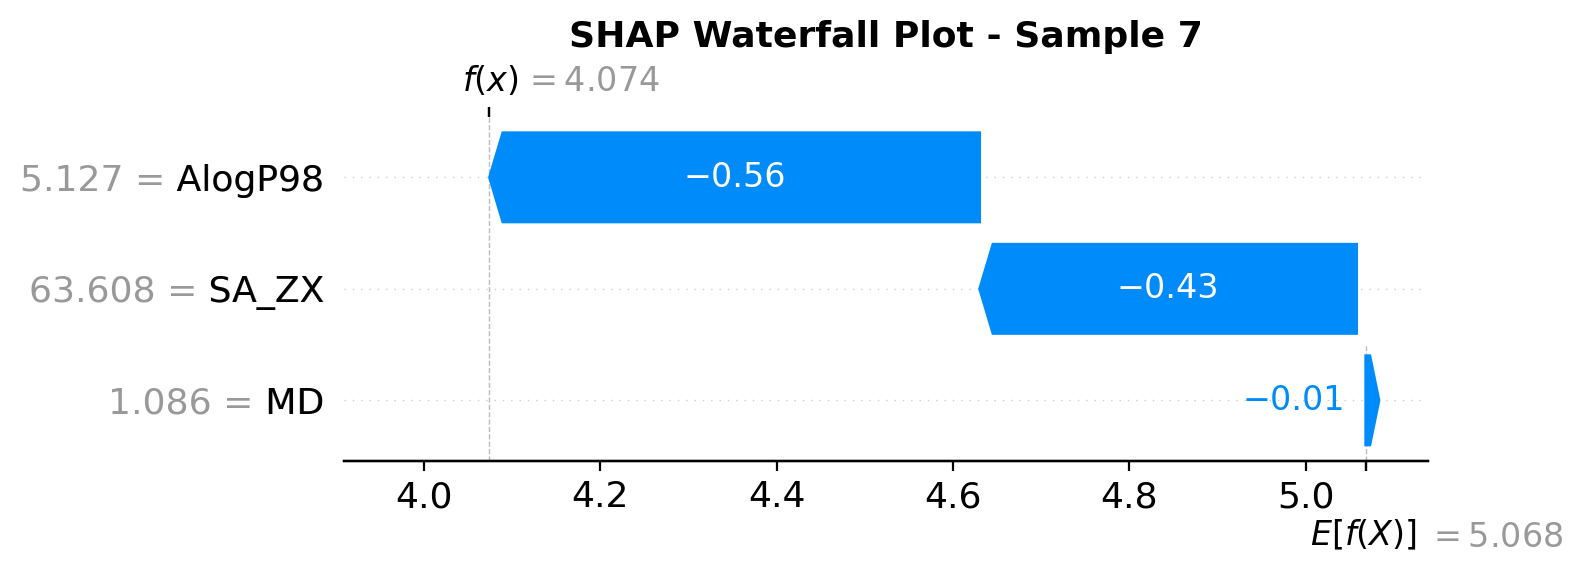

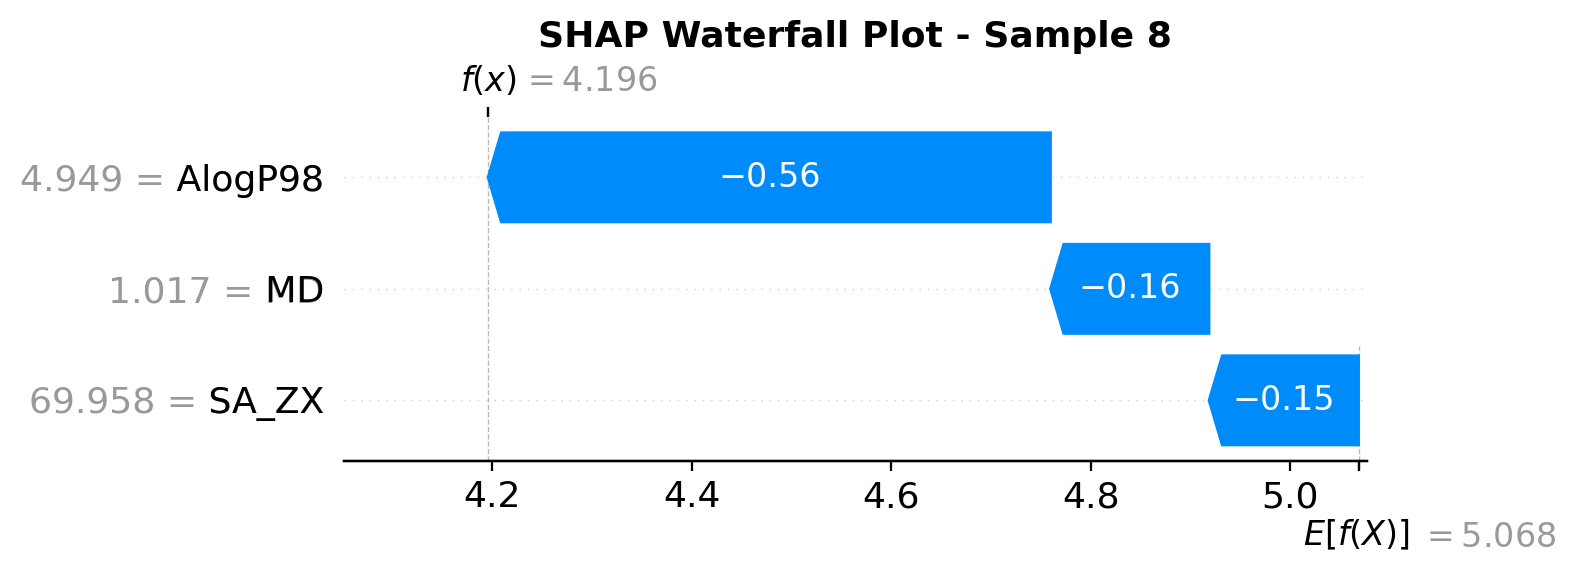

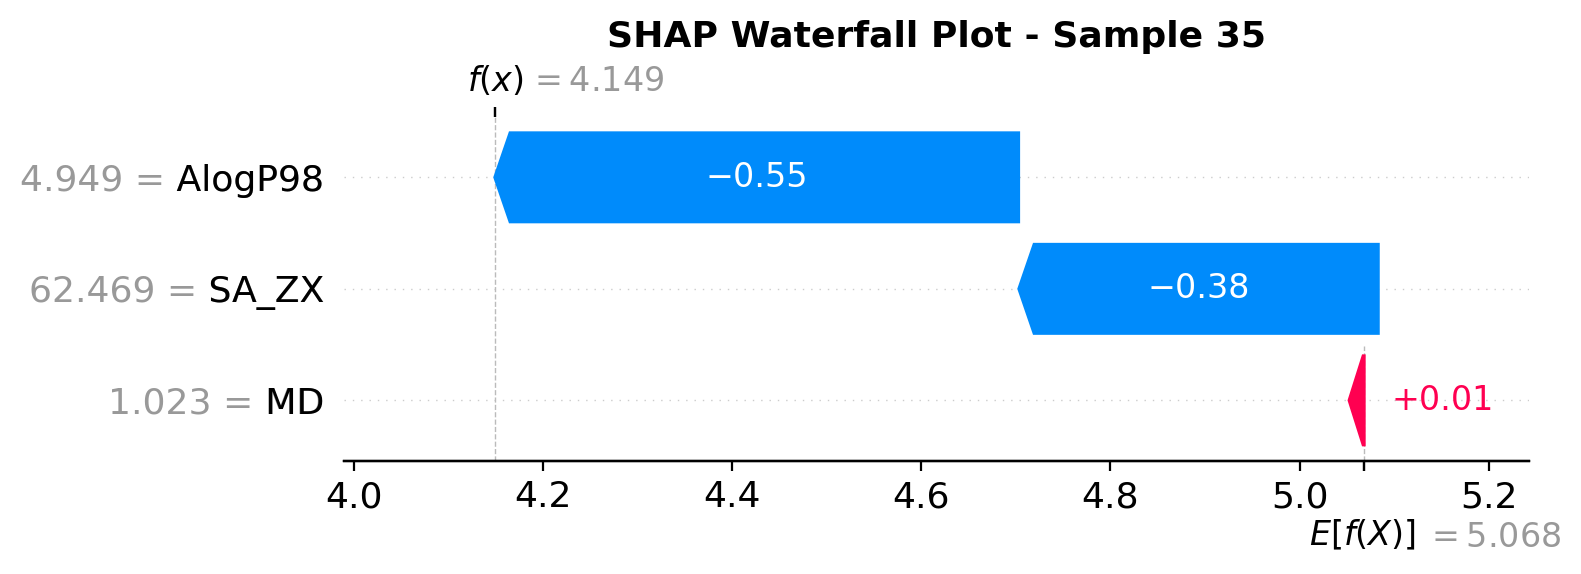

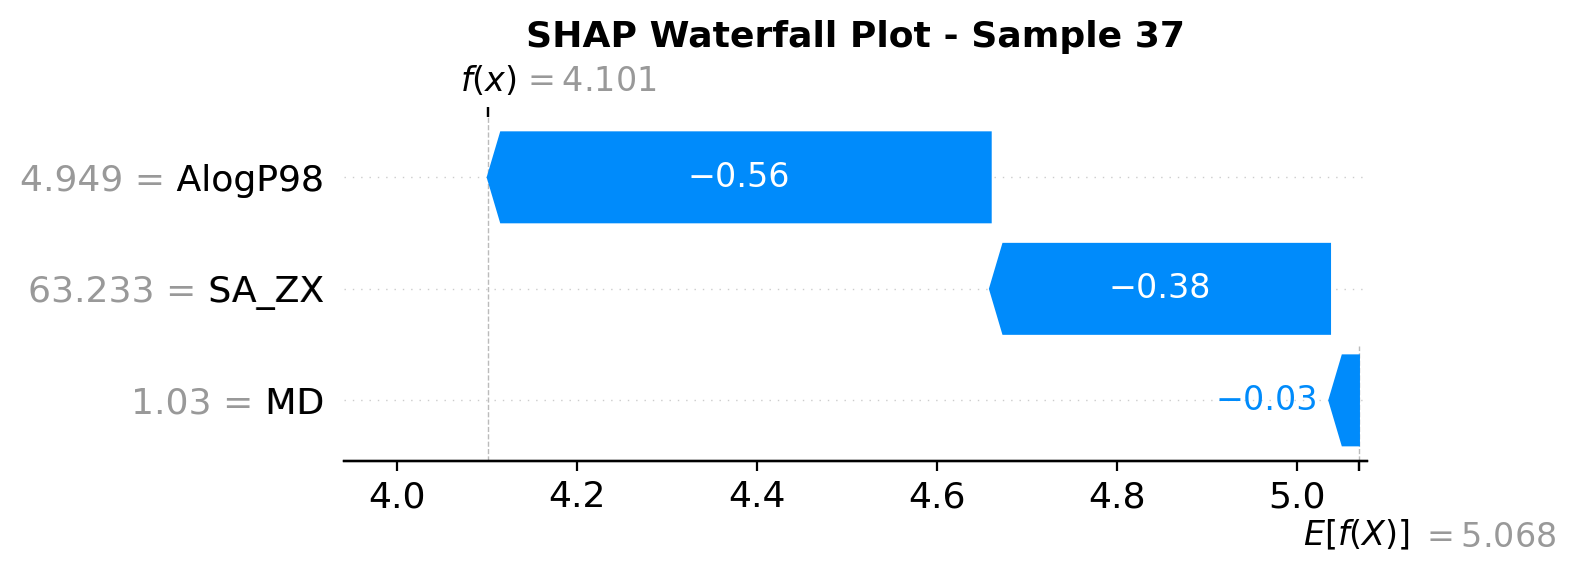

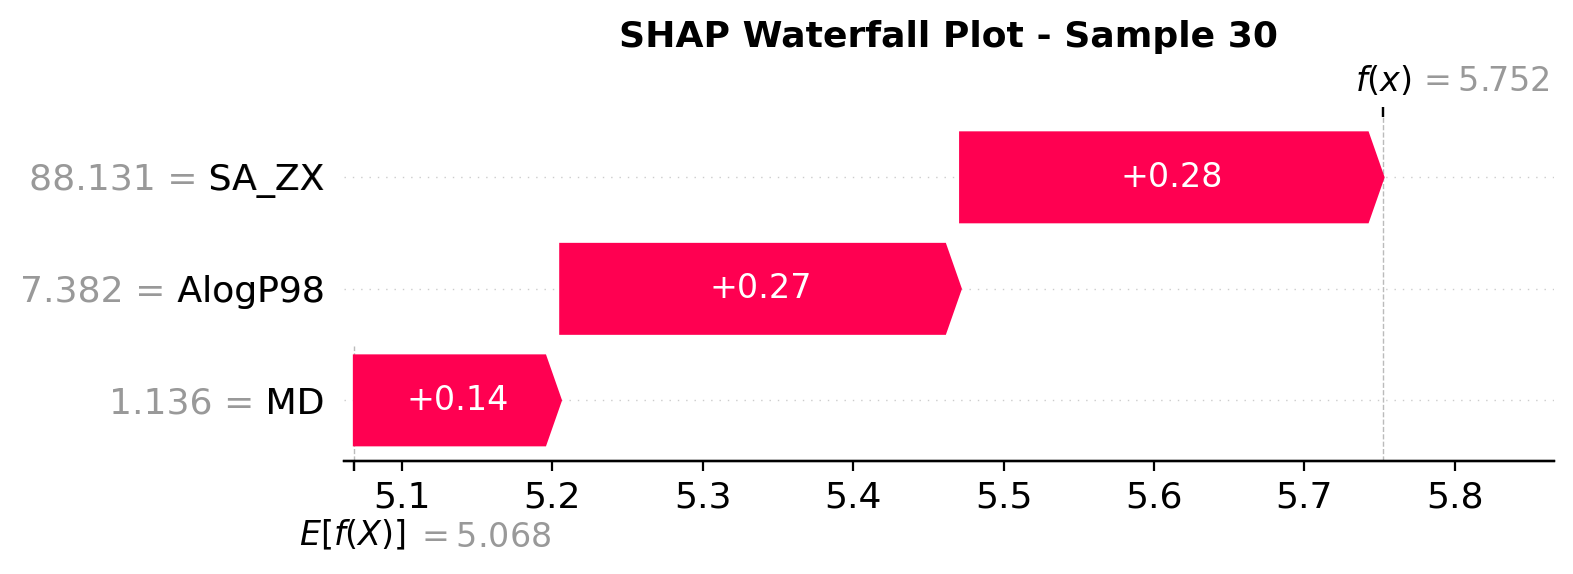

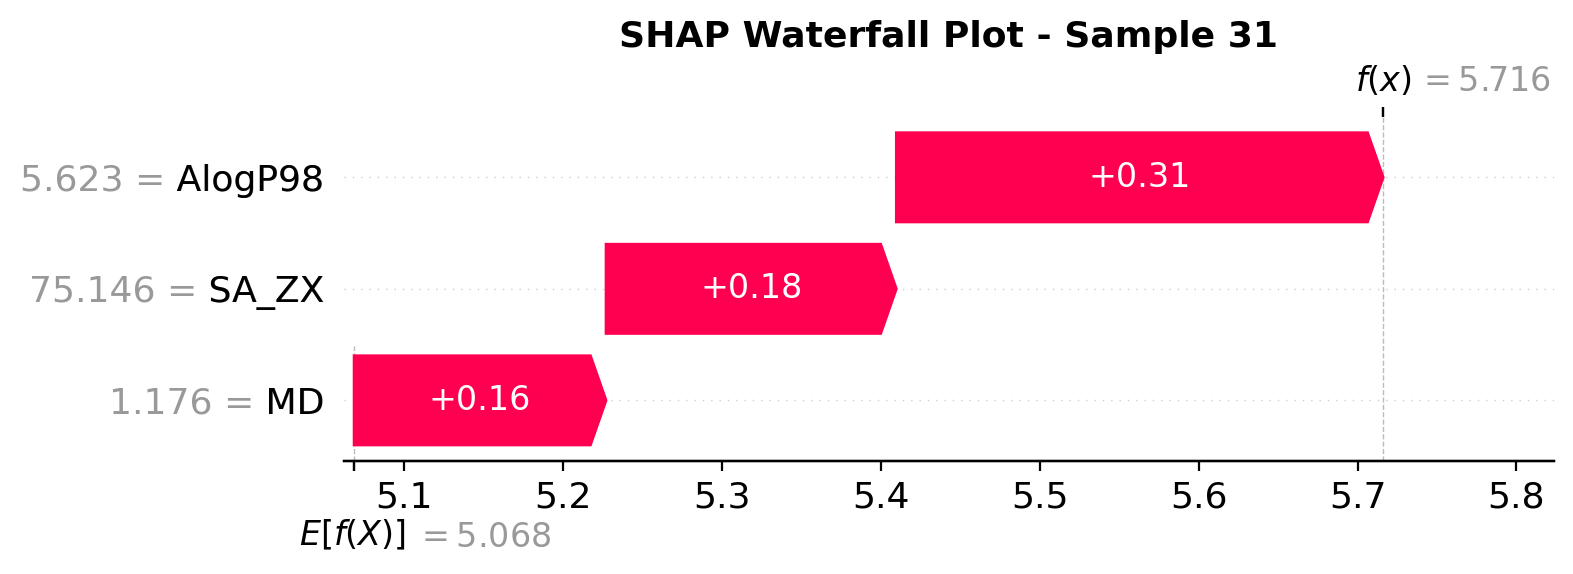

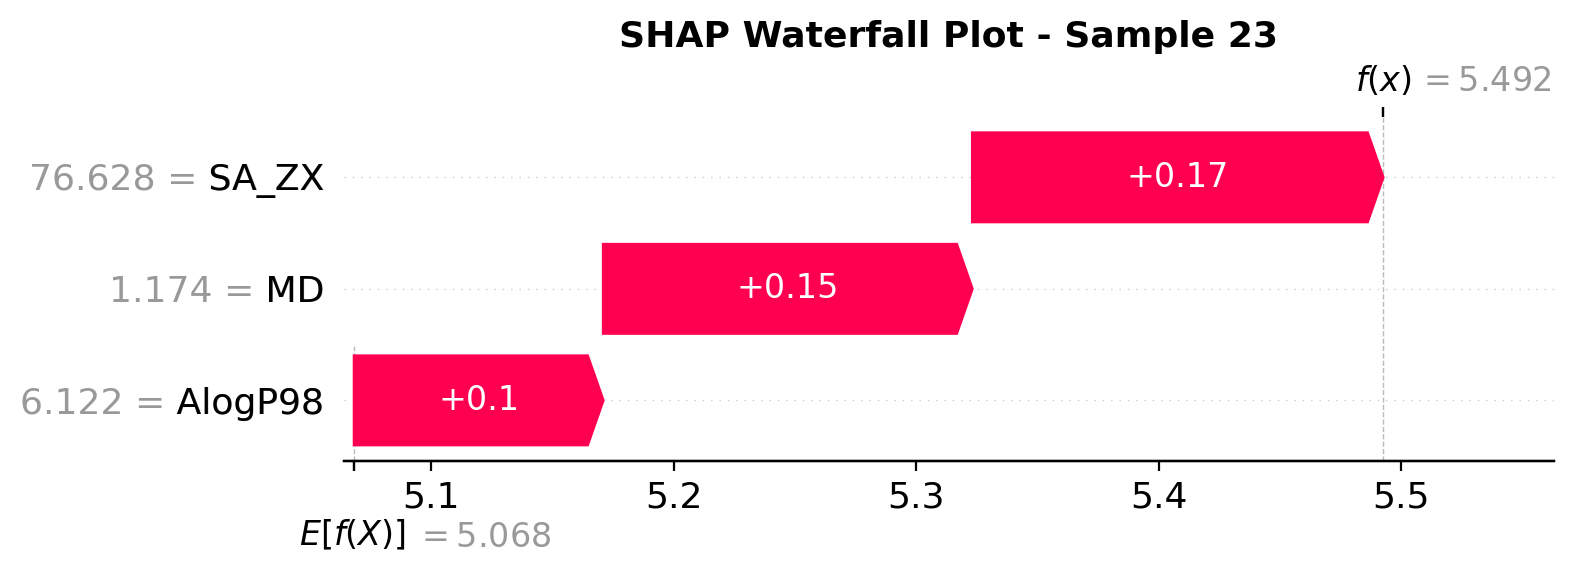

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

#8,12,9,11,40,41,33
#7,8,35,37,30,31,23

# --- 7.4 SHAP Waterfall Plots (Individual Prediction Breakdown) ---
print("Generating SHAP waterfall plots...")  # Status message

# Specify samples you want to analyze from the combined dataset
# Assuming X_train has 35 samples (0-34) and X_test has 10 samples (35-44)
# We can select some from train and some from test
sample_indices = [7, 8, 35, 37, 30, 31, 23] # Indices from the combined dataset

# Adjust font size for readability
plt.rcParams.update({'font.size': 11})

for idx in sample_indices:
    # Create SHAP explanation for the sample
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_combined_df.iloc[idx].values, # Use X_combined_df here
        feature_names=X_combined_df.columns.tolist() # Use X_combined_df here
    )

    # Plot waterfall for the sample
    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot - Sample {idx}', fontsize=13, weight='bold')
    plt.tight_layout()

    # Save each plot separately (optional)
    plt.savefig(f'SHAP_Waterfall_Sample_{idx}.png', dpi=500, bbox_inches='tight')

    # Show the plot
    plt.show()


RANDOM FOREST

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the objective function
def objective(trial):
    # Suggest hyperparameters
    max_depth = trial.suggest_int('max_depth', 2, 50)  # Allow deeper trees
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)  # Reduce regularization
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)  # Reduce regularization
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)  # Increase range for more trees

    # Create the model
    model = RandomForestRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        n_estimators=n_estimators,
        bootstrap=False  # Try disabling bootstrapping for full training utilization
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predict on the training set
    y_pred_train = model.predict(X_train)

    # Calculate training RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

    return rmse_train  # Optimize training RMSE

# Perform hyperparameter tuning with Optuna
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)  # Increase trials for better optimization

# Get the best hyperparameters
best_params = study.best_params
print("Best Hyperparameters (Optuna):", best_params)

# Train the final model with the best hyperparameters
best_model = RandomForestRegressor(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    min_samples_split=best_params['min_samples_split'],
    n_estimators=best_params['n_estimators'],
    bootstrap=False
)

best_model.fit(X_train, y_train)

# Predict and calculate RMSE for both sets
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Calculate R^2 scores
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print(f"RMSE (train): {train_rmse}")
print(f"R² (train): {train_r2}")
print(f"RMSE (test): {test_rmse}")
print(f"R² (test): {test_r2}")


[I 2026-05-11 06:30:25,298] A new study created in memory with name: no-name-cb2cc557-c5da-40d3-afc1-848520300a85
[I 2026-05-11 06:30:26,553] Trial 0 finished with value: 0.11182788646163436 and parameters: {'max_depth': 24, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 397}. Best is trial 0 with value: 0.11182788646163436.
[I 2026-05-11 06:30:28,616] Trial 1 finished with value: 0.0919368313157515 and parameters: {'max_depth': 37, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 904}. Best is trial 1 with value: 0.0919368313157515.
[I 2026-05-11 06:30:29,195] Trial 2 finished with value: 0.22356015489604328 and parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 9, 'n_estimators': 287}. Best is trial 1 with value: 0.0919368313157515.
[I 2026-05-11 06:30:31,409] Trial 3 finished with value: 0.05728375486495763 and parameters: {'max_depth': 36, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 882}. Best is trial 3 with va

Best Hyperparameters (Optuna): {'max_depth': 44, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 441}
RMSE (train): 2.6964454878612017e-14
R² (train): 1.0
RMSE (test): 0.18024079150098457
R² (test): 0.8555046594482857


In [ ]:
# Define the best hyperparameters from Optuna
best_params = {
    'n_estimators': 441,
    'max_depth': 44,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

# Instantiate the Gradient Boosting Regressor with the best hyperparameters
best_model = RandomForestRegressor(**best_params)

# Fit the model on the training data
best_model.fit(X_train, y_train)

# Predict on the training data
y_pred_train = best_model.predict(X_train)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predict on the test data
y_pred_test = best_model.predict(X_test)

# ----- TRAIN METRICS -----
mse_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train)) / len(y_train)
rmse_train = mse_train ** 0.5
r2_train = r2_score(y_train, y_pred_train)

# ----- TEST METRICS -----
mse_test = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test)) / len(y_test)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, y_pred_test)

# MAE (test)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Q2 (external test set)
y_train_mean = sum(y_train) / len(y_train)
ss_res = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test))
ss_tot = sum((y - y_train_mean) ** 2 for y in y_test)
q2_test = 1 - (ss_res / ss_tot)

# ----- PRINT RESULTS -----
print('RMSE (train): %.3f' % rmse_train)
print('R² (train): %.3f' % r2_train)

print('RMSE (test): %.3f' % rmse_test)
print('R² (test): %.3f' % r2_test)
print('MAE (test): %.3f' % mae_test)
print('Q² (test): %.3f' % q2_test)

RMSE (train): 0.113
R² (train): 0.923
RMSE (test): 0.130
R² (test): 0.924
MAE (test): 0.099
Q² (test): 0.953


In [ ]:
from sklearn.metrics import mean_absolute_error

# ===================== TRAIN METRICS =====================

# MAE (train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Q² (train)
y_train_mean = sum(y_train) / len(y_train)

ss_res_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train))
ss_tot_train = sum((y - y_train_mean) ** 2 for y in y_train)

q2_train = 1 - (ss_res_train / ss_tot_train)

# Print results
print('MAE (train): %.3f' % mae_train)
print('Q² (train): %.3f' % q2_train)

MAE (train): 0.097
Q² (train): 0.922


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# Convert X_train and y_train to NumPy arrays
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

# Initialize K-Fold Cross-Validation
n_splits = 5  # Specify the number of splits
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# List to store R² scores for each fold
r2_scores = []

# Perform Cross-Validation
for train_index, test_index in kf.split(X_train_np):
    # Split the data into training and validation folds
    X_cv_train, X_cv_test = X_train_np[train_index], X_train_np[test_index]
    y_cv_train, y_cv_test = y_train_np[train_index], y_train_np[test_index]

    # Use the existing model to predict on the validation fold
    y_pred = best_model.predict(X_cv_test)

    # Calculate R² score for the validation fold
    r2_fold = r2_score(y_cv_test, y_pred)
    r2_scores.append(r2_fold)

# Calculate Mean and Standard Deviation of R² Scores
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

# Display Results
print(f"R² (Cross-Validation): {mean_r2:.4f} ± {std_r2:.4f}")


R² (Cross-Validation): 0.8741 ± 0.0723


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'train': '#002060',
        'test': '#f0984d',
        'edge': '#002060'
    }
}

scheme = COLOR_SCHEMES[1]

# ===================== PLOT FUNCTION =====================
def plot_back_to_back_histogram(y_train, y_test):

    # Combine data for consistent bins
    all_data = np.concatenate([y_train, y_test])
    bins = np.linspace(min(all_data), max(all_data), 10)

    # Histogram counts
    counts_train, bin_edges = np.histogram(y_train, bins=bins)
    counts_test, _ = np.histogram(y_test, bins=bins)

    # Bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Bar height
    bar_height = (bin_edges[1] - bin_edges[0]) * 0.8

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    ax.set_facecolor(scheme['bg'])

    # Train (left)
    ax.barh(bin_centers,
            -counts_train,
            height=bar_height,
            color=scheme['train'],
            alpha=0.8,
            edgecolor=scheme['edge'],
            label="Train Set")

    # Test (right)
    ax.barh(bin_centers,
            counts_test,
            height=bar_height,
            color=scheme['test'],
            alpha=0.8,
            edgecolor=scheme['test'],
            label="Test Set")

    # Center line
    ax.axvline(0, color='black', linewidth=1.2)

    # 🔥 KEY FIX: Show absolute values on x-axis (no negatives displayed)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(abs(x))}'))

    # Labels and title
    ax.set_xlabel("Count", fontsize=13, fontweight='bold')
    ax.set_ylabel("pIC50", fontsize=13, fontweight='bold')
    ax.set_title("Train vs Test Distribution", fontsize=13, fontweight='bold')

    # Legend (clean style)
    ax.legend(loc="upper left", frameon=False, fontsize=6)

    # Remove grid
    ax.grid(False)

    # Tight layout
    plt.tight_layout()

    plt.show()

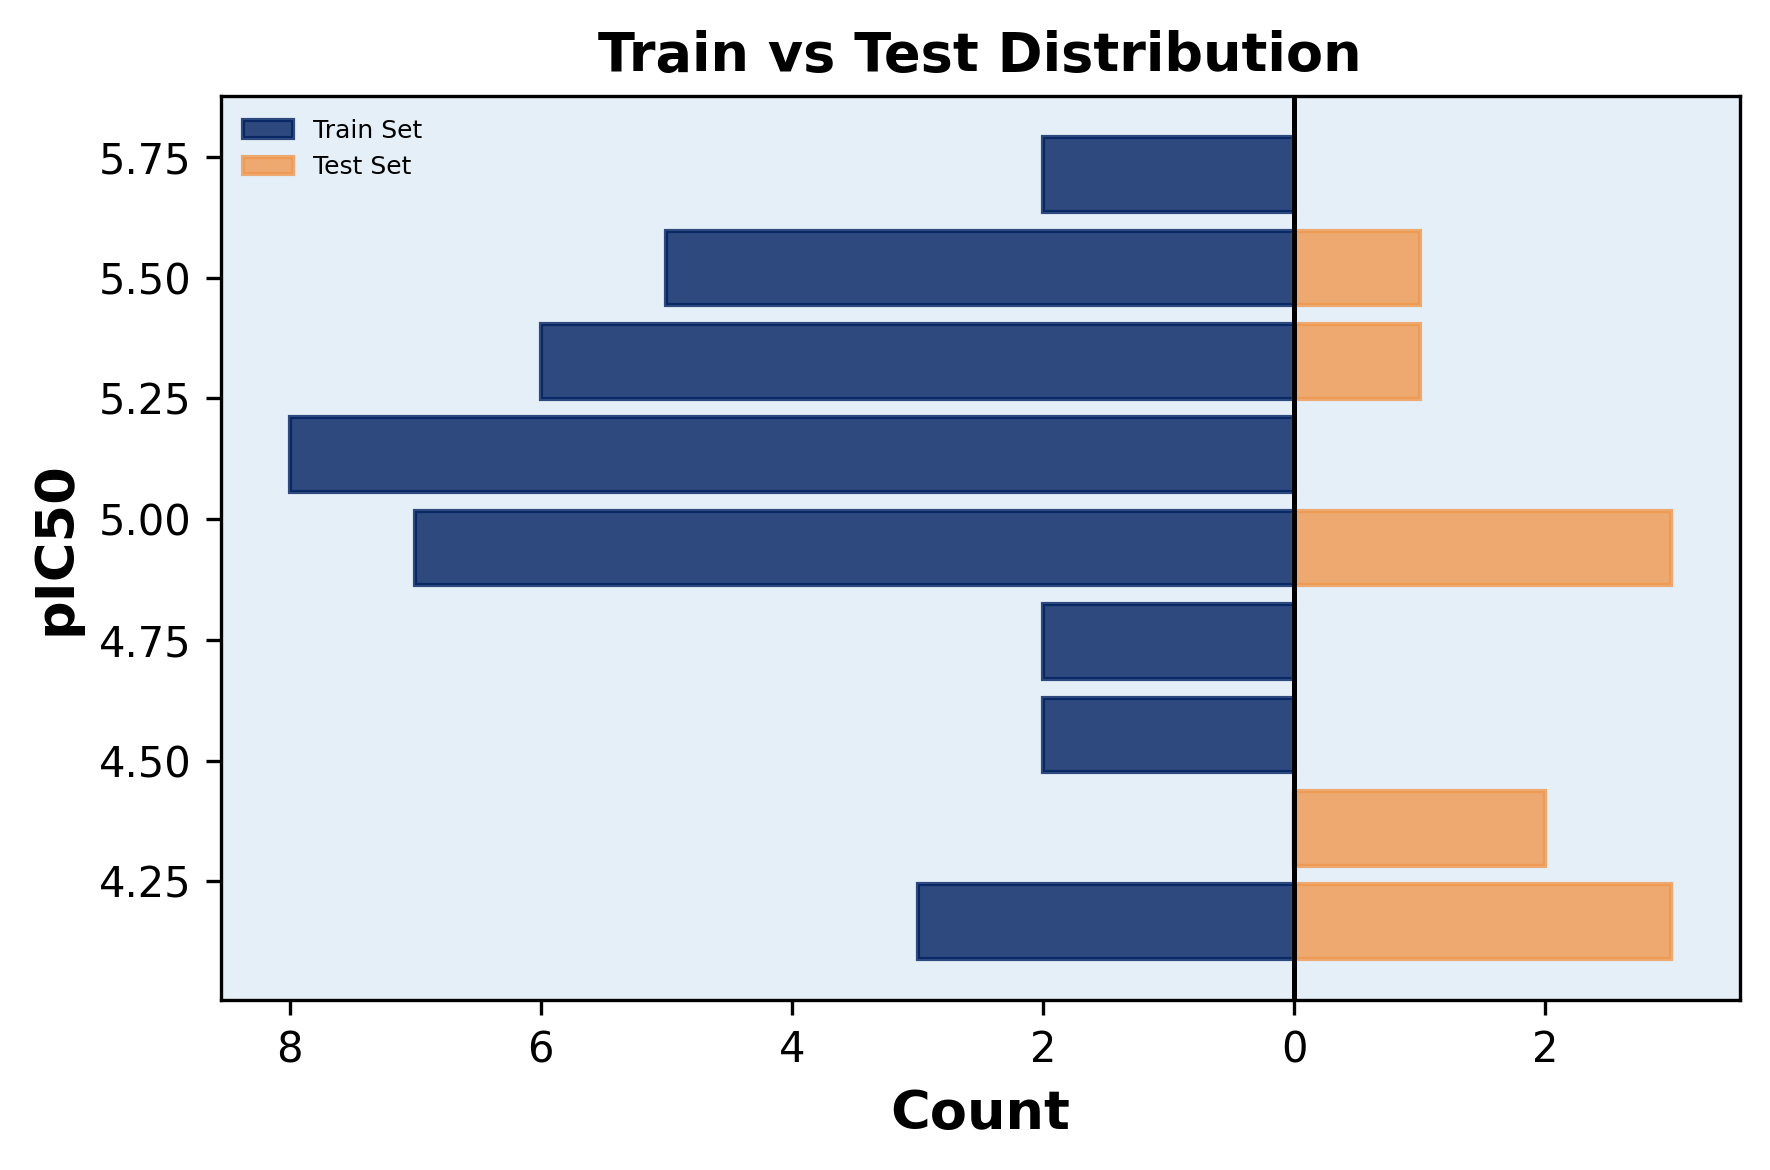

In [ ]:
plot_back_to_back_histogram(y_train, y_test)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'train': '#002060',
        'test': '#f0984d'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test):

    fig = plt.figure(figsize=(7, 4), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.45)

    # ===================== LEFT: PARITY =====================
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(scheme['bg'])

    # Scatter
    ax1.scatter(y_train, y_pred_train,
                color=scheme['train'], label='Train Set', alpha=0.8)

    ax1.scatter(y_test, y_pred_test,
                color=scheme['test'], marker='^', label='Test Set', alpha=0.9)

    # Diagonal
    ax1.plot([4, 6], [4, 6], color='black', linewidth=1)

    # 🔥 FORCE RANGE 4–6
    ax1.set_xlim(4, 6)
    ax1.set_ylim(4, 6)

    ax1.set_xticks(np.arange(4, 6.1, 0.5))
    ax1.set_yticks(np.arange(4, 6.1, 0.5))

    # Labels (🔥 closer y-label)
    ax1.set_xlabel('Exp. pIC50', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Pred. pIC50',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=5)

    ax1.legend(loc="upper left", frameon=False, fontsize=6)
    ax1.grid(False)

    # ===================== RIGHT: RESIDUALS =====================
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(scheme['bg'])

    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Boxplot
    box = ax2.boxplot([residuals_test, residuals_train],
                      patch_artist=True,
                      labels=['Test', 'Train'],
                      widths=0.5)

    box['boxes'][0].set_facecolor(scheme['test'])
    box['boxes'][1].set_facecolor(scheme['train'])

    for patch in box['boxes']:
        patch.set_alpha(0.5)

    # Scatter
    jitter_test = np.random.normal(1, 0.05, size=len(residuals_test))
    jitter_train = np.random.normal(2, 0.05, size=len(residuals_train))

    ax2.scatter(jitter_test, residuals_test,
                color='yellow', alpha=0.7, s=20, zorder=3)

    ax2.scatter(jitter_train, residuals_train,
                color='black', alpha=0.7, s=20, zorder=3)

    # Y range
    ax2.set_ylim(-1, 1)
    ax2.set_yticks(np.linspace(-1, 1, 5))

    ax2.set_ylabel('Residuals',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=2)

    ax2.tick_params(labelsize=10)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

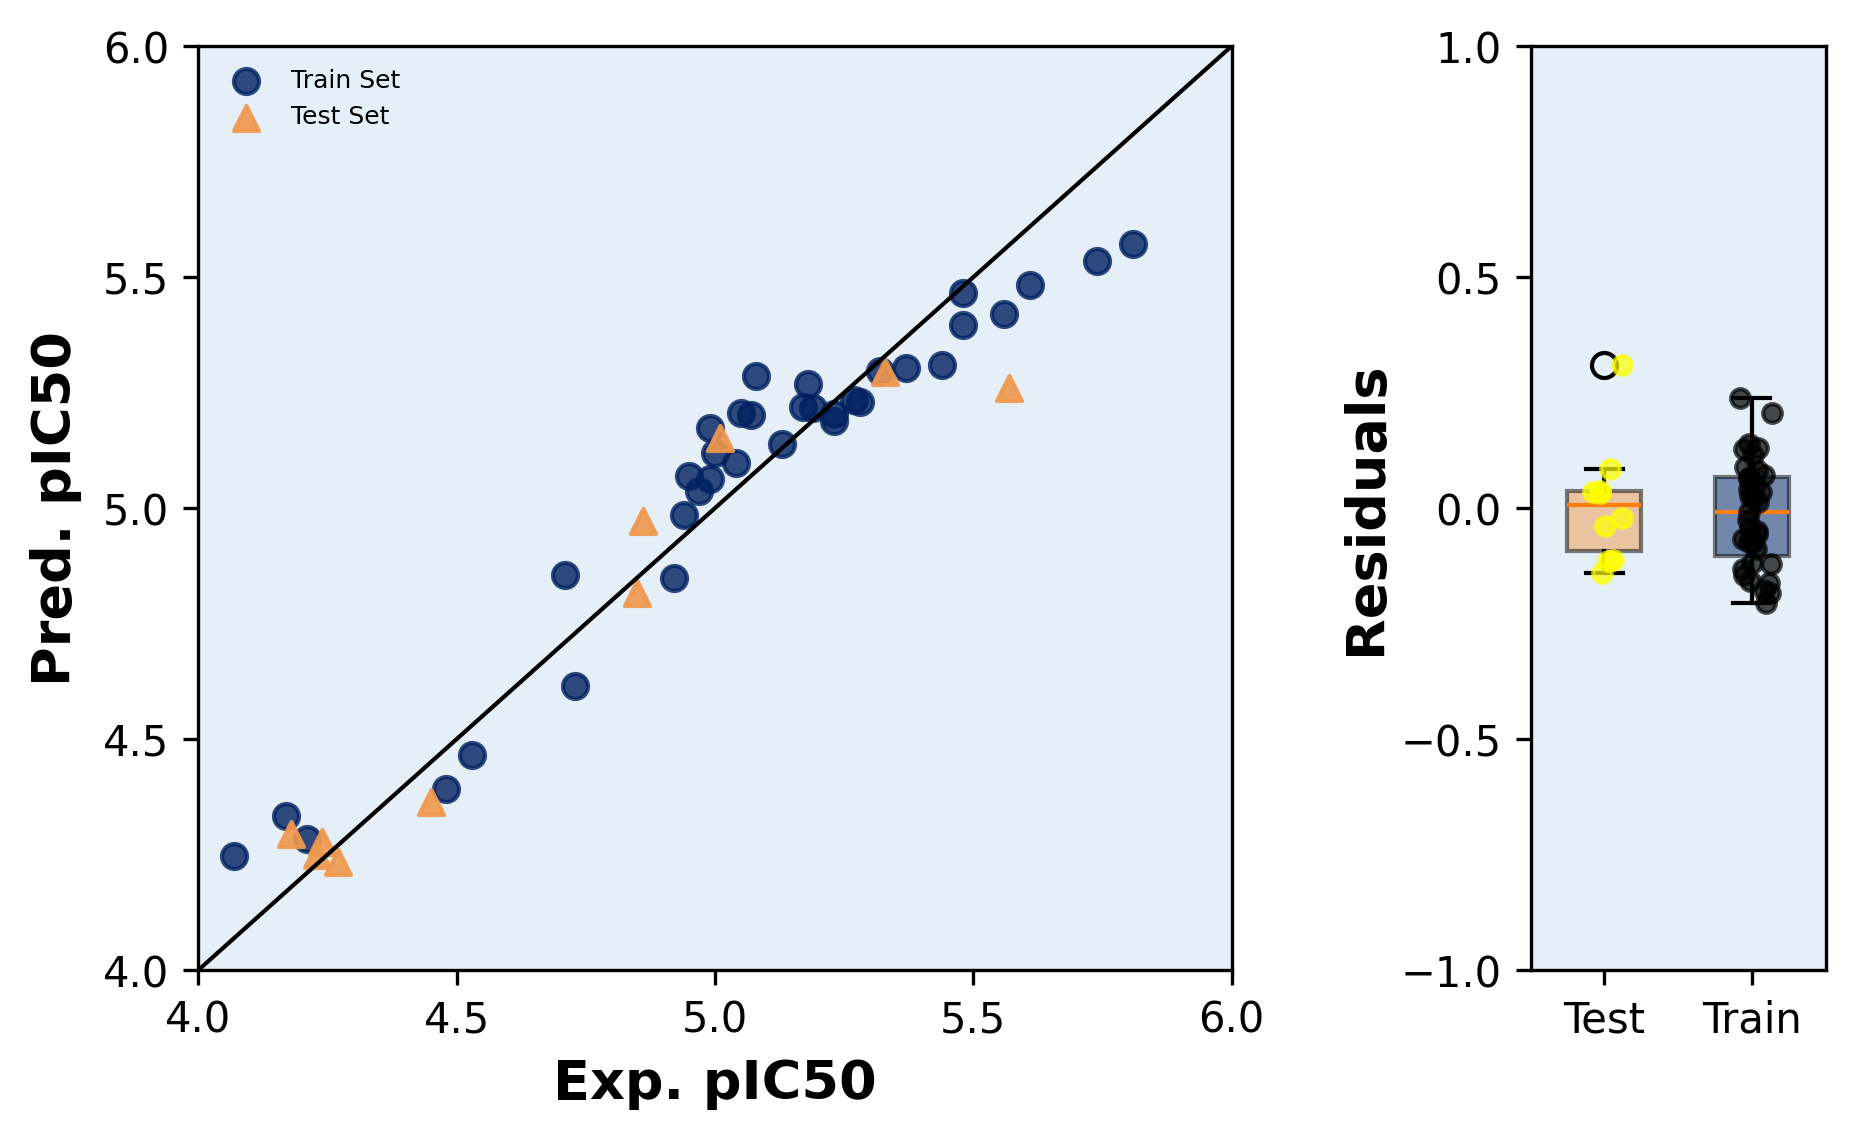

In [ ]:
plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'r2': '#002060',
        'rmse': '#f0984d',
        'mae': '#7a8e9e',
        'q2': '#a2c6d4'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_metrics_bar_chart(r2_train, rmse_train, mae_train, q2_train,
                           r2_test, rmse_test, mae_test, q2_test):

    # Labels (top → bottom)
    labels = [
        'R² (Train)', 'RMSE (Train)', 'MAE (Train)', 'Q² (Train)',
        'R² (Test)', 'RMSE (Test)', 'MAE (Test)', 'Q² (Test)'
    ]

    values = [
        r2_train, rmse_train, mae_train, q2_train,
        r2_test, rmse_test, mae_test, q2_test
    ]

    colors = [
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2'],
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2']
    ]

    # Positions (spacing between Train and Test)
    y_pos = [1, 2, 3, 4, 6, 7, 8, 9]

    # ===================== FIGURE =====================
    fig = plt.figure(figsize=(6.5, 6), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 2.5], wspace=0)

    # ===================== LEFT PANEL (TABLE) =====================
    ax_tab = fig.add_subplot(gs[0])
    ax_tab.set_xlim(0, 1)
    ax_tab.set_ylim(0.5, 9.5)
    ax_tab.axis('off')

    # ---- OUTER BORDER ----
    ax_tab.plot([0.05, 0.95], [0.5, 0.5], color='black', linewidth=2)   # bottom
    ax_tab.plot([0.05, 0.95], [9.5, 9.5], color='black', linewidth=2)   # top
    ax_tab.plot([0.05, 0.05], [0.5, 9.5], color='black', linewidth=2)   # left
    ax_tab.plot([0.95, 0.95], [0.5, 9.5], color='black', linewidth=2)   # right

    # ---- INNER VERTICAL DIVIDER ----
    ax_tab.plot([0.3, 0.3], [0.5, 9.5], color='black', linewidth=1.5)

    # ---- HORIZONTAL LINES ----
    for y in [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]:
        ax_tab.plot([0.3, 0.95], [y, y], color='black', linewidth=1)

    # ---- GROUP DIVIDER ----
    ax_tab.plot([0.05, 0.95], [5.0, 5.0], color='black', linewidth=2)

    # ---- SECTION LABELS ----
    ax_tab.text(0.17, 2.5, 'Train',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    ax_tab.text(0.17, 7.5, 'Test',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    # ---- METRIC LABELS ----
    for y, label in zip(y_pos, labels):
        ax_tab.text(0.4, y, label,
                    va='center', ha='left',
                    fontsize=9, fontweight='bold')

    # ===================== RIGHT PANEL (BARS) =====================
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.set_facecolor(scheme['bg'])

    ax_bar.barh(y_pos, values, color=colors, alpha=0.85)

    ax_bar.set_ylim(0.5, 9.5)
    ax_bar.set_xlim(0, max(values) * 1.2)

    # Remove y ticks (handled by table)
    ax_bar.set_yticks([])

    # Labels
    ax_bar.set_xlabel('Metric Value', fontsize=13, fontweight='bold')

    # Clean look
    ax_bar.grid(False)

    # Layout
    plt.tight_layout()
    plt.show()

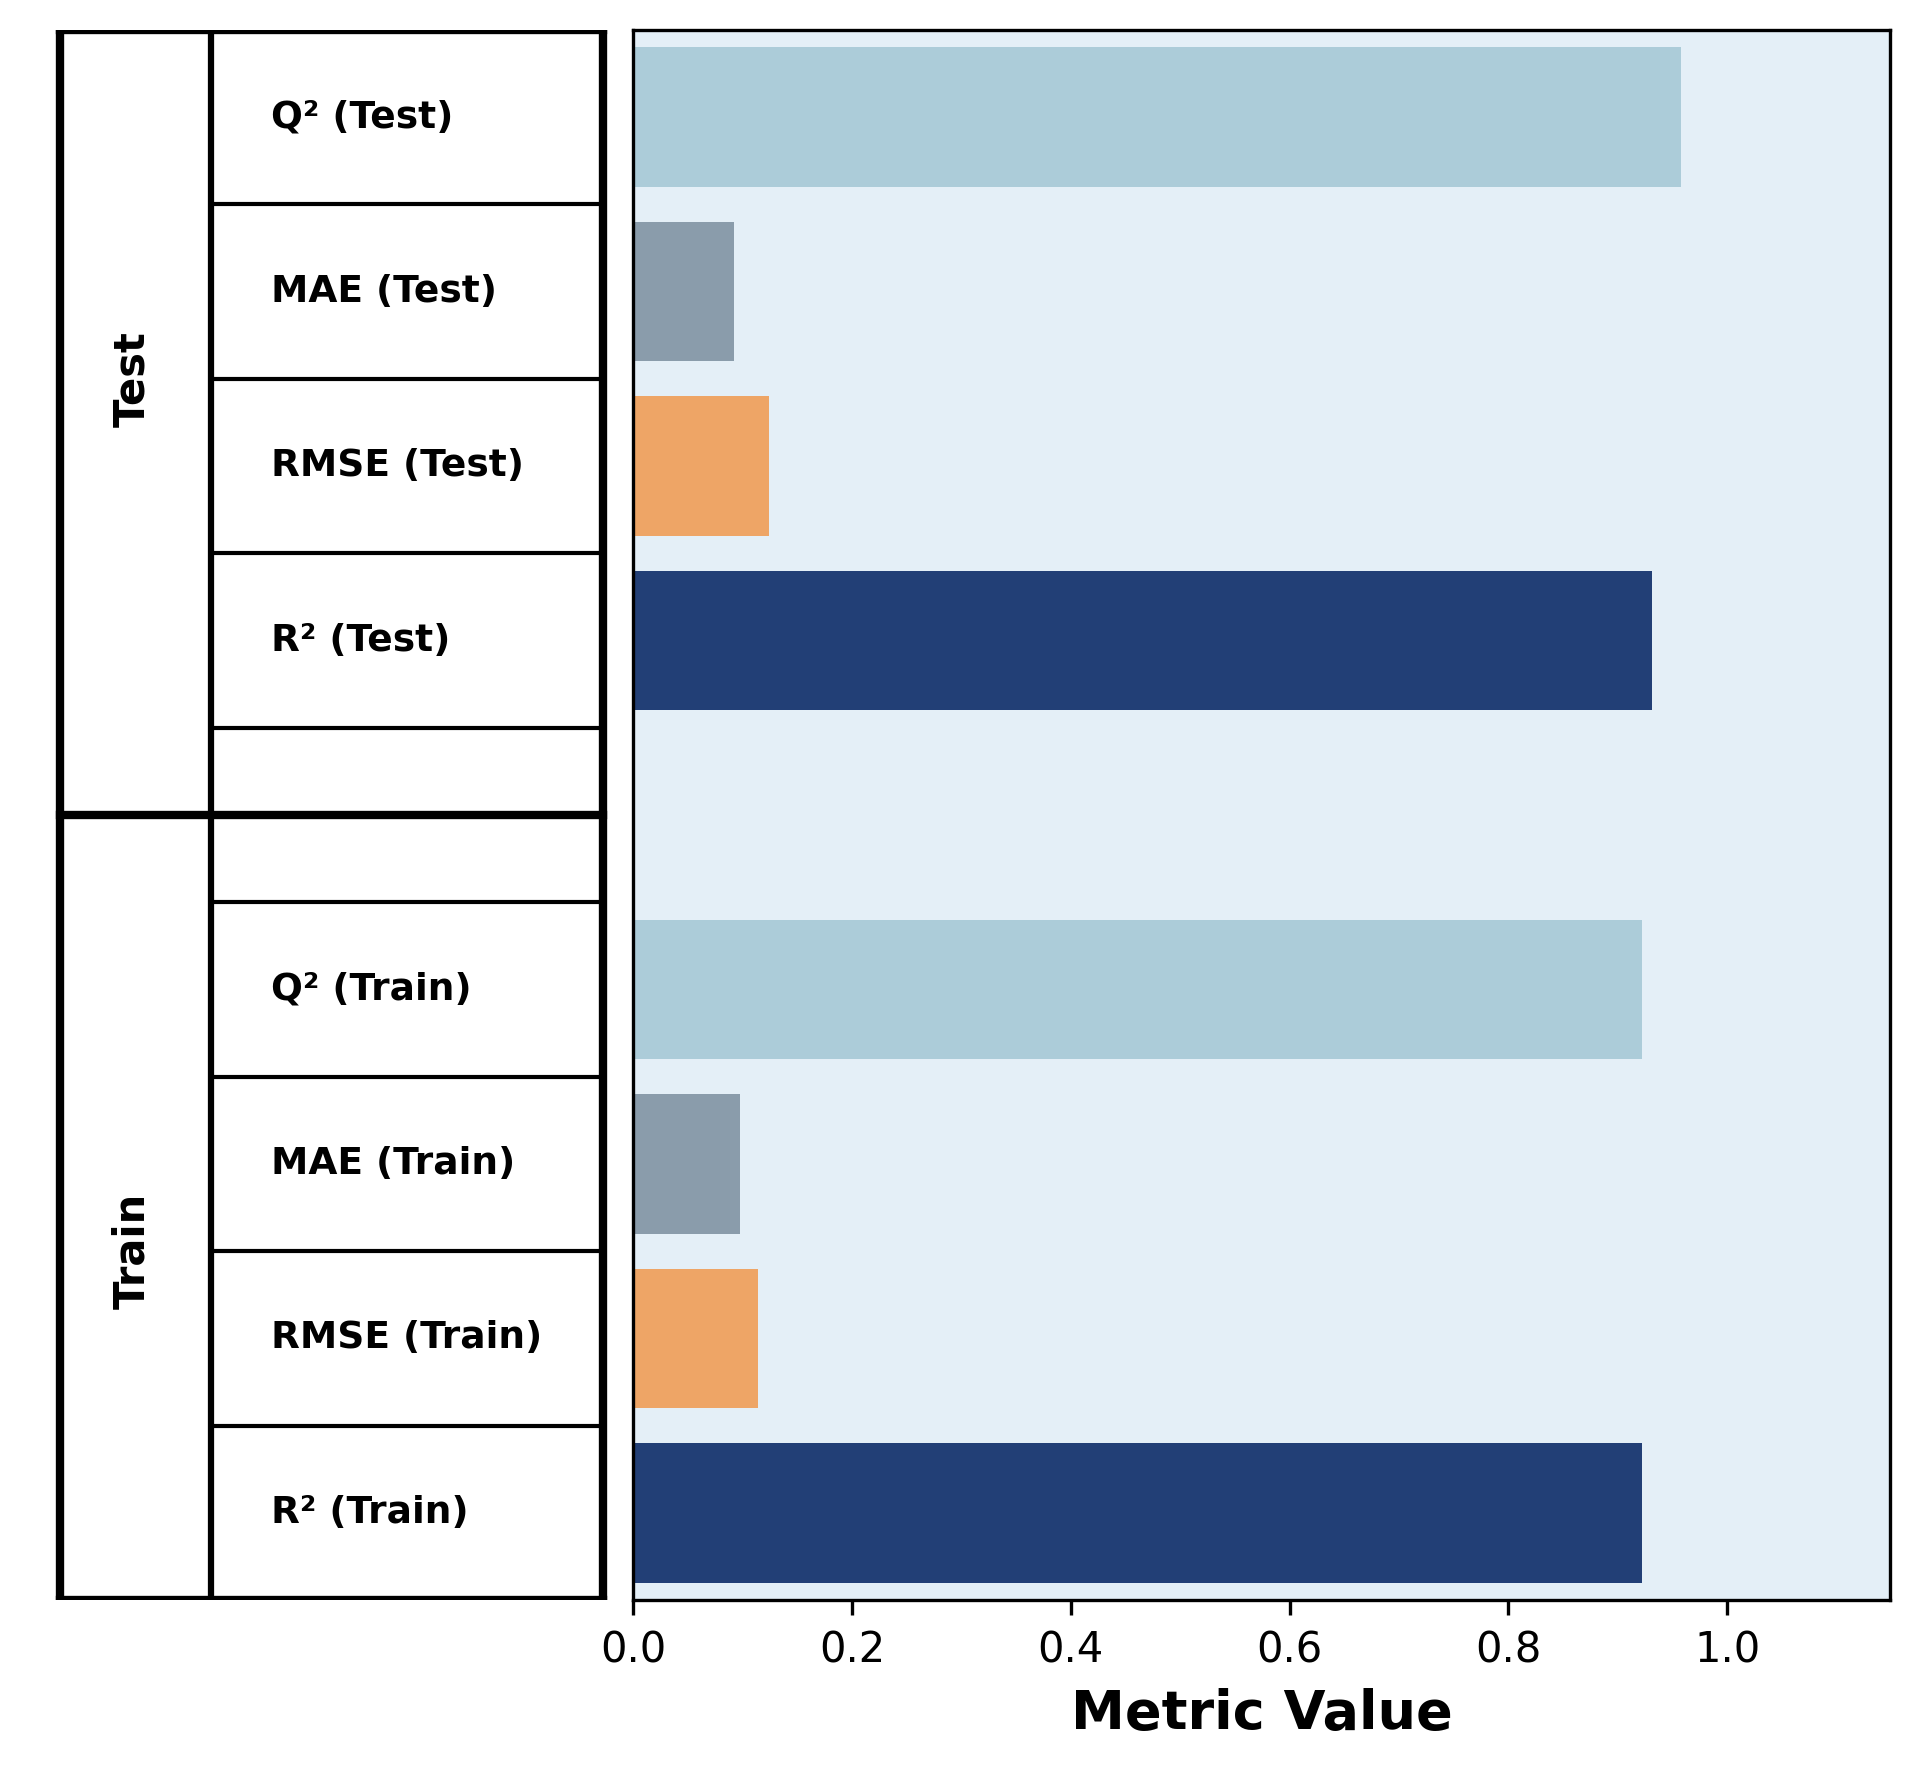

In [ ]:
plot_metrics_bar_chart(
    r2_train, rmse_train, mae_train, q2_train,
    r2_test, rmse_test, mae_test, q2_test
)

In [ ]:
XGB

In [ ]:
pip install optuna

In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the objective function for Optuna to optimize
def objective(trial):

    # Suggest hyperparameters using Optuna's trial object
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.05)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    gamma = trial.suggest_float('gamma', 0, 5)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)

    # Create the XGBoost Regressor model
    model = xgb.XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight,
        objective='reg:squarederror',
        random_state=42
    )

    # Train the model on the training set
    model.fit(X_train, y_train)

    # Predict on both the training set and test set
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate RMSE for both the training set and test set
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Return the average RMSE
    combined_rmse = (rmse_train + rmse_test) / 2

    return combined_rmse


# Create an Optuna study
study = optuna.create_study(direction="minimize")

# Perform optimization
study.optimize(objective, n_trials=15)

# Get the best hyperparameters
best_params = study.best_params
print("Best Hyperparameters (Optuna):", best_params)

# Build the final XGBoost model
best_model = xgb.XGBRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    min_child_weight=best_params['min_child_weight'],
    objective='reg:squarederror',
    random_state=42
)

# Train the final model
best_model.fit(X_train, y_train)

# Predict on training and test sets
y_pred_train_final = best_model.predict(X_train)
y_pred_test_final = best_model.predict(X_test)

# Calculate RMSE
final_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

print(f"Final RMSE on the Training Set: {final_train_rmse}")
print(f"Final RMSE on the Test Set: {final_test_rmse}")

[I 2026-05-11 23:01:54,357] A new study created in memory with name: no-name-1f5a2fc4-f8af-476f-a406-facb854959a6
[I 2026-05-11 23:01:54,460] Trial 0 finished with value: 0.48665311722664867 and parameters: {'n_estimators': 243, 'max_depth': 2, 'learning_rate': 0.04616232631549594, 'subsample': 0.6519848230636847, 'colsample_bytree': 0.9146372944887886, 'gamma': 3.4264550225677093, 'min_child_weight': 8}. Best is trial 0 with value: 0.48665311722664867.
[I 2026-05-11 23:01:54,903] Trial 1 finished with value: 0.5030428298151464 and parameters: {'n_estimators': 151, 'max_depth': 6, 'learning_rate': 0.021906932065313356, 'subsample': 0.8478796739600863, 'colsample_bytree': 0.9224467720271513, 'gamma': 4.361917109701915, 'min_child_weight': 9}. Best is trial 0 with value: 0.48665311722664867.
[I 2026-05-11 23:01:55,050] Trial 2 finished with value: 0.3193089949465996 and parameters: {'n_estimators': 155, 'max_depth': 3, 'learning_rate': 0.04716370860055811, 'subsample': 0.9515998424334693

Best Hyperparameters (Optuna): {'n_estimators': 194, 'max_depth': 10, 'learning_rate': 0.03610226863032456, 'subsample': 0.6308808411296752, 'colsample_bytree': 0.8705133230241677, 'gamma': 0.06726575628546613, 'min_child_weight': 1}
Final RMSE on the Training Set: 0.1636677396221896
Final RMSE on the Test Set: 0.12451149691921676


In [ ]:
import xgboost as xgb

# Define the best hyperparameters from Optuna
best_params = {
    'n_estimators': 194,
    'max_depth': 10,
    'learning_rate': 0.03610226863032456,
    'subsample': 0.6308808411296752,
    'colsample_bytree': 0.8705133230241677,
    'gamma': 0.06726575628546613,
    'min_child_weight': 1
}

# Instantiate the XGBoost Regressor with the best hyperparameters
best_model = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

# Fit the model on the training data
best_model.fit(X_train, y_train)

# Predict on the training data
y_pred_train = best_model.predict(X_train)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predict on the test data
y_pred_test = best_model.predict(X_test)

# ----- TRAIN METRICS -----
mse_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train)) / len(y_train)
rmse_train = mse_train ** 0.5
r2_train = r2_score(y_train, y_pred_train)

# ----- TEST METRICS -----
mse_test = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test)) / len(y_test)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, y_pred_test)

# MAE (test)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Q2 (external test set)
y_train_mean = sum(y_train) / len(y_train)
ss_res = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test))
ss_tot = sum((y - y_train_mean) ** 2 for y in y_test)
q2_test = 1 - (ss_res / ss_tot)

# ----- PRINT RESULTS -----
print('RMSE (train): %.3f' % rmse_train)
print('R² (train): %.3f' % r2_train)

print('RMSE (test): %.3f' % rmse_test)
print('R² (test): %.3f' % r2_test)
print('MAE (test): %.3f' % mae_test)
print('Q² (test): %.3f' % q2_test)

from sklearn.metrics import mean_absolute_error

# ===================== TRAIN METRICS =====================

# MAE (train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Q² (train)
y_train_mean = sum(y_train) / len(y_train)

ss_res_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train))
ss_tot_train = sum((y - y_train_mean) ** 2 for y in y_train)

q2_train = 1 - (ss_res_train / ss_tot_train)

# Print results
print('MAE (train): %.3f' % mae_train)
print('Q² (train): %.3f' % q2_train)

RMSE (train): 0.164
R² (train): 0.840
RMSE (test): 0.125
R² (test): 0.931
MAE (test): 0.100
Q² (test): 0.957
MAE (train): 0.136
Q² (train): 0.840


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# Convert X_train and y_train to NumPy arrays
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

# Initialize K-Fold Cross-Validation
n_splits = 5  # Specify the number of splits
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# List to store R² scores for each fold
r2_scores = []

# Perform Cross-Validation
for train_index, test_index in kf.split(X_train_np):
    # Split the data into training and validation folds
    X_cv_train, X_cv_test = X_train_np[train_index], X_train_np[test_index]
    y_cv_train, y_cv_test = y_train_np[train_index], y_train_np[test_index]

    # Use the existing model to predict on the validation fold
    y_pred = best_model.predict(X_cv_test)

    # Calculate R² score for the validation fold
    r2_fold = r2_score(y_cv_test, y_pred)
    r2_scores.append(r2_fold)

# Calculate Mean and Standard Deviation of R² Scores
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

# Display Results
print(f"R² (Cross-Validation): {mean_r2:.4f} ± {std_r2:.4f}")


R² (Cross-Validation): 0.7386 ± 0.1570


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'train': '#002060',
        'test': '#f0984d'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test):

    fig = plt.figure(figsize=(7, 4), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.45)

    # ===================== LEFT: PARITY =====================
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(scheme['bg'])

    # Scatter
    ax1.scatter(y_train, y_pred_train,
                color=scheme['train'], label='Train Set', alpha=0.8)

    ax1.scatter(y_test, y_pred_test,
                color=scheme['test'], marker='^', label='Test Set', alpha=0.9)

    # Diagonal
    ax1.plot([4, 6], [4, 6], color='black', linewidth=1)

    # 🔥 FORCE RANGE 4–6
    ax1.set_xlim(4, 6)
    ax1.set_ylim(4, 6)

    ax1.set_xticks(np.arange(4, 6.1, 0.5))
    ax1.set_yticks(np.arange(4, 6.1, 0.5))

    # Labels (🔥 closer y-label)
    ax1.set_xlabel('Exp. pIC50', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Pred. pIC50',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=5)

    ax1.legend(loc="upper left", frameon=False, fontsize=6)
    ax1.grid(False)

    # ===================== RIGHT: RESIDUALS =====================
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(scheme['bg'])

    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Boxplot
    box = ax2.boxplot([residuals_test, residuals_train],
                      patch_artist=True,
                      labels=['Test', 'Train'],
                      widths=0.5)

    box['boxes'][0].set_facecolor(scheme['test'])
    box['boxes'][1].set_facecolor(scheme['train'])

    for patch in box['boxes']:
        patch.set_alpha(0.5)

    # Scatter
    jitter_test = np.random.normal(1, 0.05, size=len(residuals_test))
    jitter_train = np.random.normal(2, 0.05, size=len(residuals_train))

    ax2.scatter(jitter_test, residuals_test,
                color='green', alpha=0.7, s=20, zorder=3)

    ax2.scatter(jitter_train, residuals_train,
                color='purple', alpha=0.7, s=20, zorder=3)

    # Y range
    ax2.set_ylim(-1, 1)
    ax2.set_yticks(np.linspace(-1, 1, 5))

    ax2.set_ylabel('Residuals',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=2)

    ax2.tick_params(labelsize=10)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

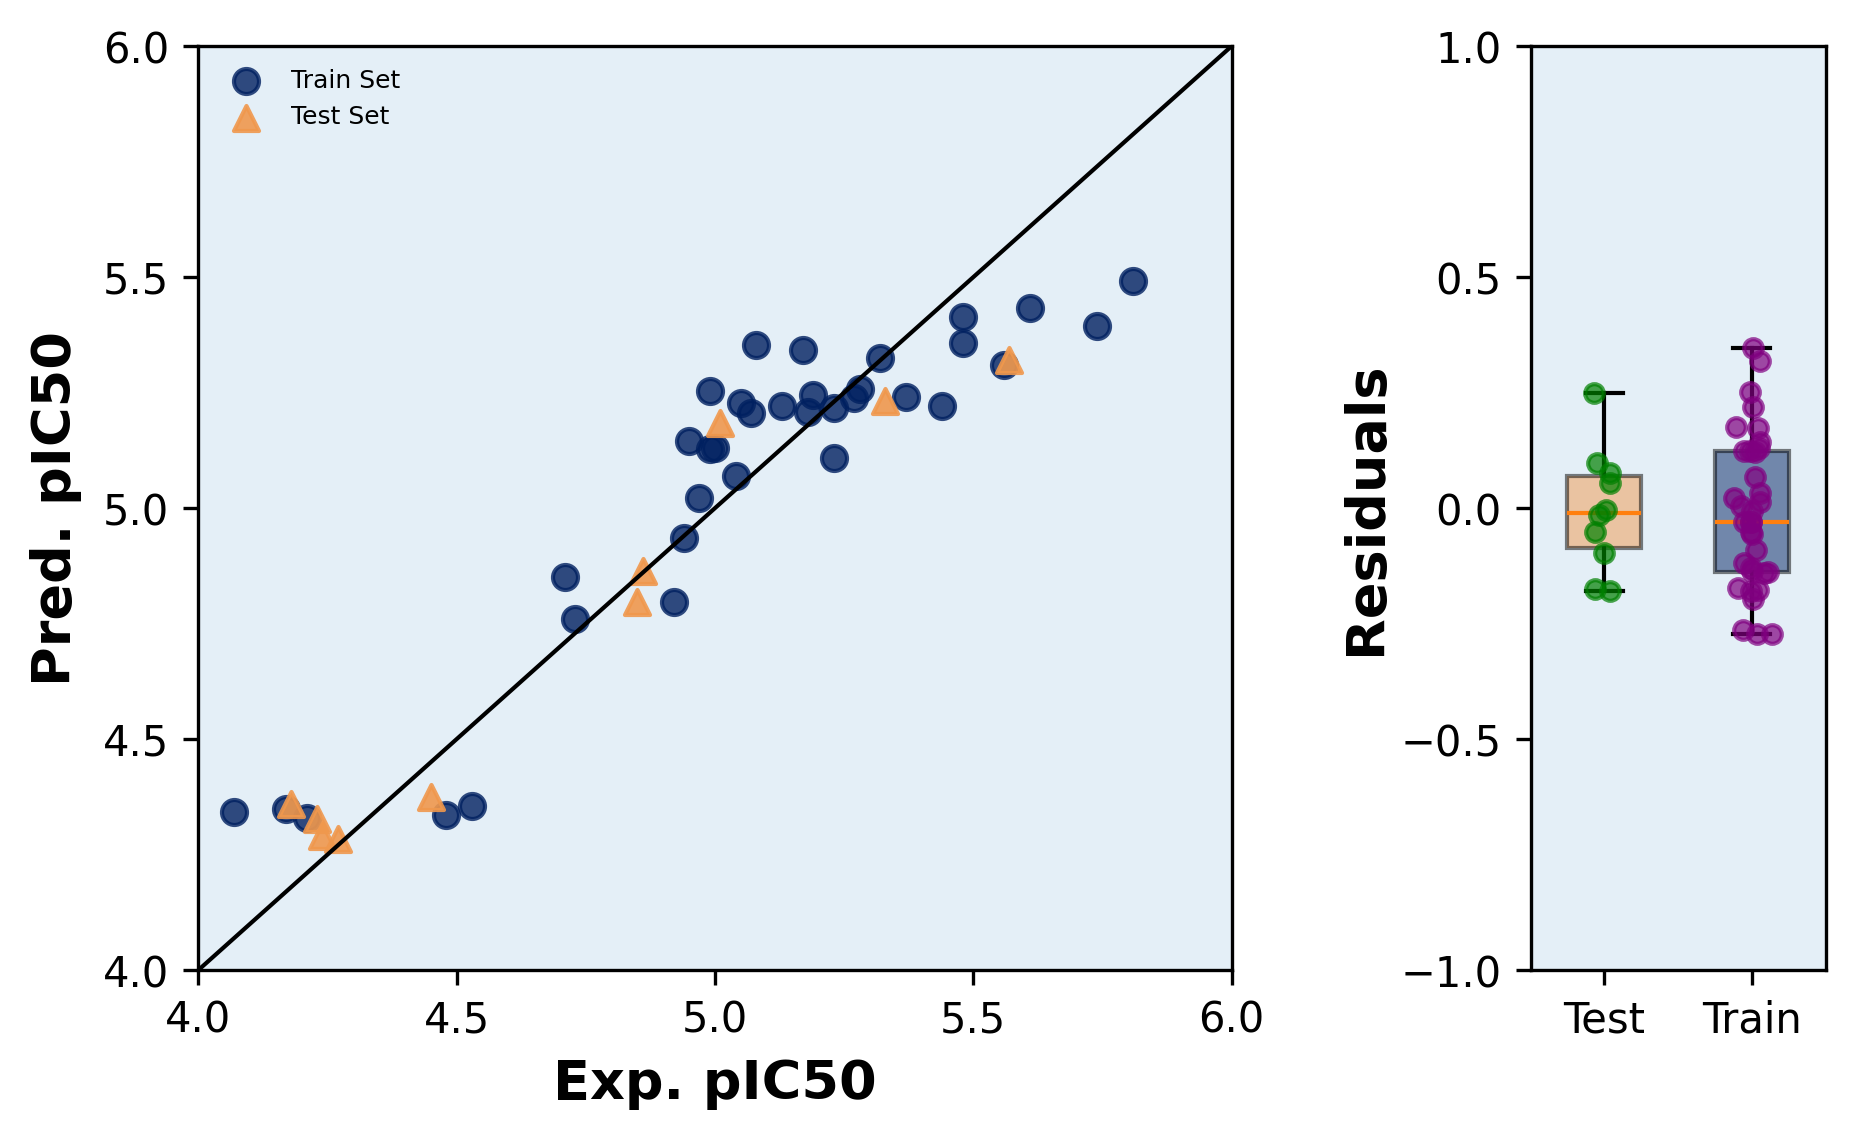

In [ ]:
plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'r2': '#002060',
        'rmse': '#f0984d',
        'mae': '#7a8e9e',
        'q2': '#a2c6d4'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_metrics_bar_chart(r2_train, rmse_train, mae_train, q2_train,
                           r2_test, rmse_test, mae_test, q2_test):

    # Labels (top → bottom)
    labels = [
        'R² (Train)', 'RMSE (Train)', 'MAE (Train)', 'Q² (Train)',
        'R² (Test)', 'RMSE (Test)', 'MAE (Test)', 'Q² (Test)'
    ]

    values = [
        r2_train, rmse_train, mae_train, q2_train,
        r2_test, rmse_test, mae_test, q2_test
    ]

    colors = [
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2'],
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2']
    ]

    # Positions (spacing between Train and Test)
    y_pos = [1, 2, 3, 4, 6, 7, 8, 9]

    # ===================== FIGURE =====================
    fig = plt.figure(figsize=(6.5, 6), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 2.5], wspace=0)

    # ===================== LEFT PANEL (TABLE) =====================
    ax_tab = fig.add_subplot(gs[0])
    ax_tab.set_xlim(0, 1)
    ax_tab.set_ylim(0.5, 9.5)
    ax_tab.axis('off')

    # ---- OUTER BORDER ----
    ax_tab.plot([0.05, 0.95], [0.5, 0.5], color='black', linewidth=2)   # bottom
    ax_tab.plot([0.05, 0.95], [9.5, 9.5], color='black', linewidth=2)   # top
    ax_tab.plot([0.05, 0.05], [0.5, 9.5], color='black', linewidth=2)   # left
    ax_tab.plot([0.95, 0.95], [0.5, 9.5], color='black', linewidth=2)   # right

    # ---- INNER VERTICAL DIVIDER ----
    ax_tab.plot([0.3, 0.3], [0.5, 9.5], color='black', linewidth=1.5)

    # ---- HORIZONTAL LINES ----
    for y in [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]:
        ax_tab.plot([0.3, 0.95], [y, y], color='black', linewidth=1)

    # ---- GROUP DIVIDER ----
    ax_tab.plot([0.05, 0.95], [5.0, 5.0], color='black', linewidth=2)

    # ---- SECTION LABELS ----
    ax_tab.text(0.17, 2.5, 'Train',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    ax_tab.text(0.17, 7.5, 'Test',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    # ---- METRIC LABELS ----
    for y, label in zip(y_pos, labels):
        ax_tab.text(0.4, y, label,
                    va='center', ha='left',
                    fontsize=9, fontweight='bold')

    # ===================== RIGHT PANEL (BARS) =====================
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.set_facecolor(scheme['bg'])

    ax_bar.barh(y_pos, values, color=colors, alpha=0.85)

    ax_bar.set_ylim(0.5, 9.5)
    ax_bar.set_xlim(0, max(values) * 1.2)

    # Remove y ticks (handled by table)
    ax_bar.set_yticks([])

    # Labels
    ax_bar.set_xlabel('Metric Value', fontsize=13, fontweight='bold')

    # Clean look
    ax_bar.grid(False)

    # Layout
    plt.tight_layout()
    plt.show()

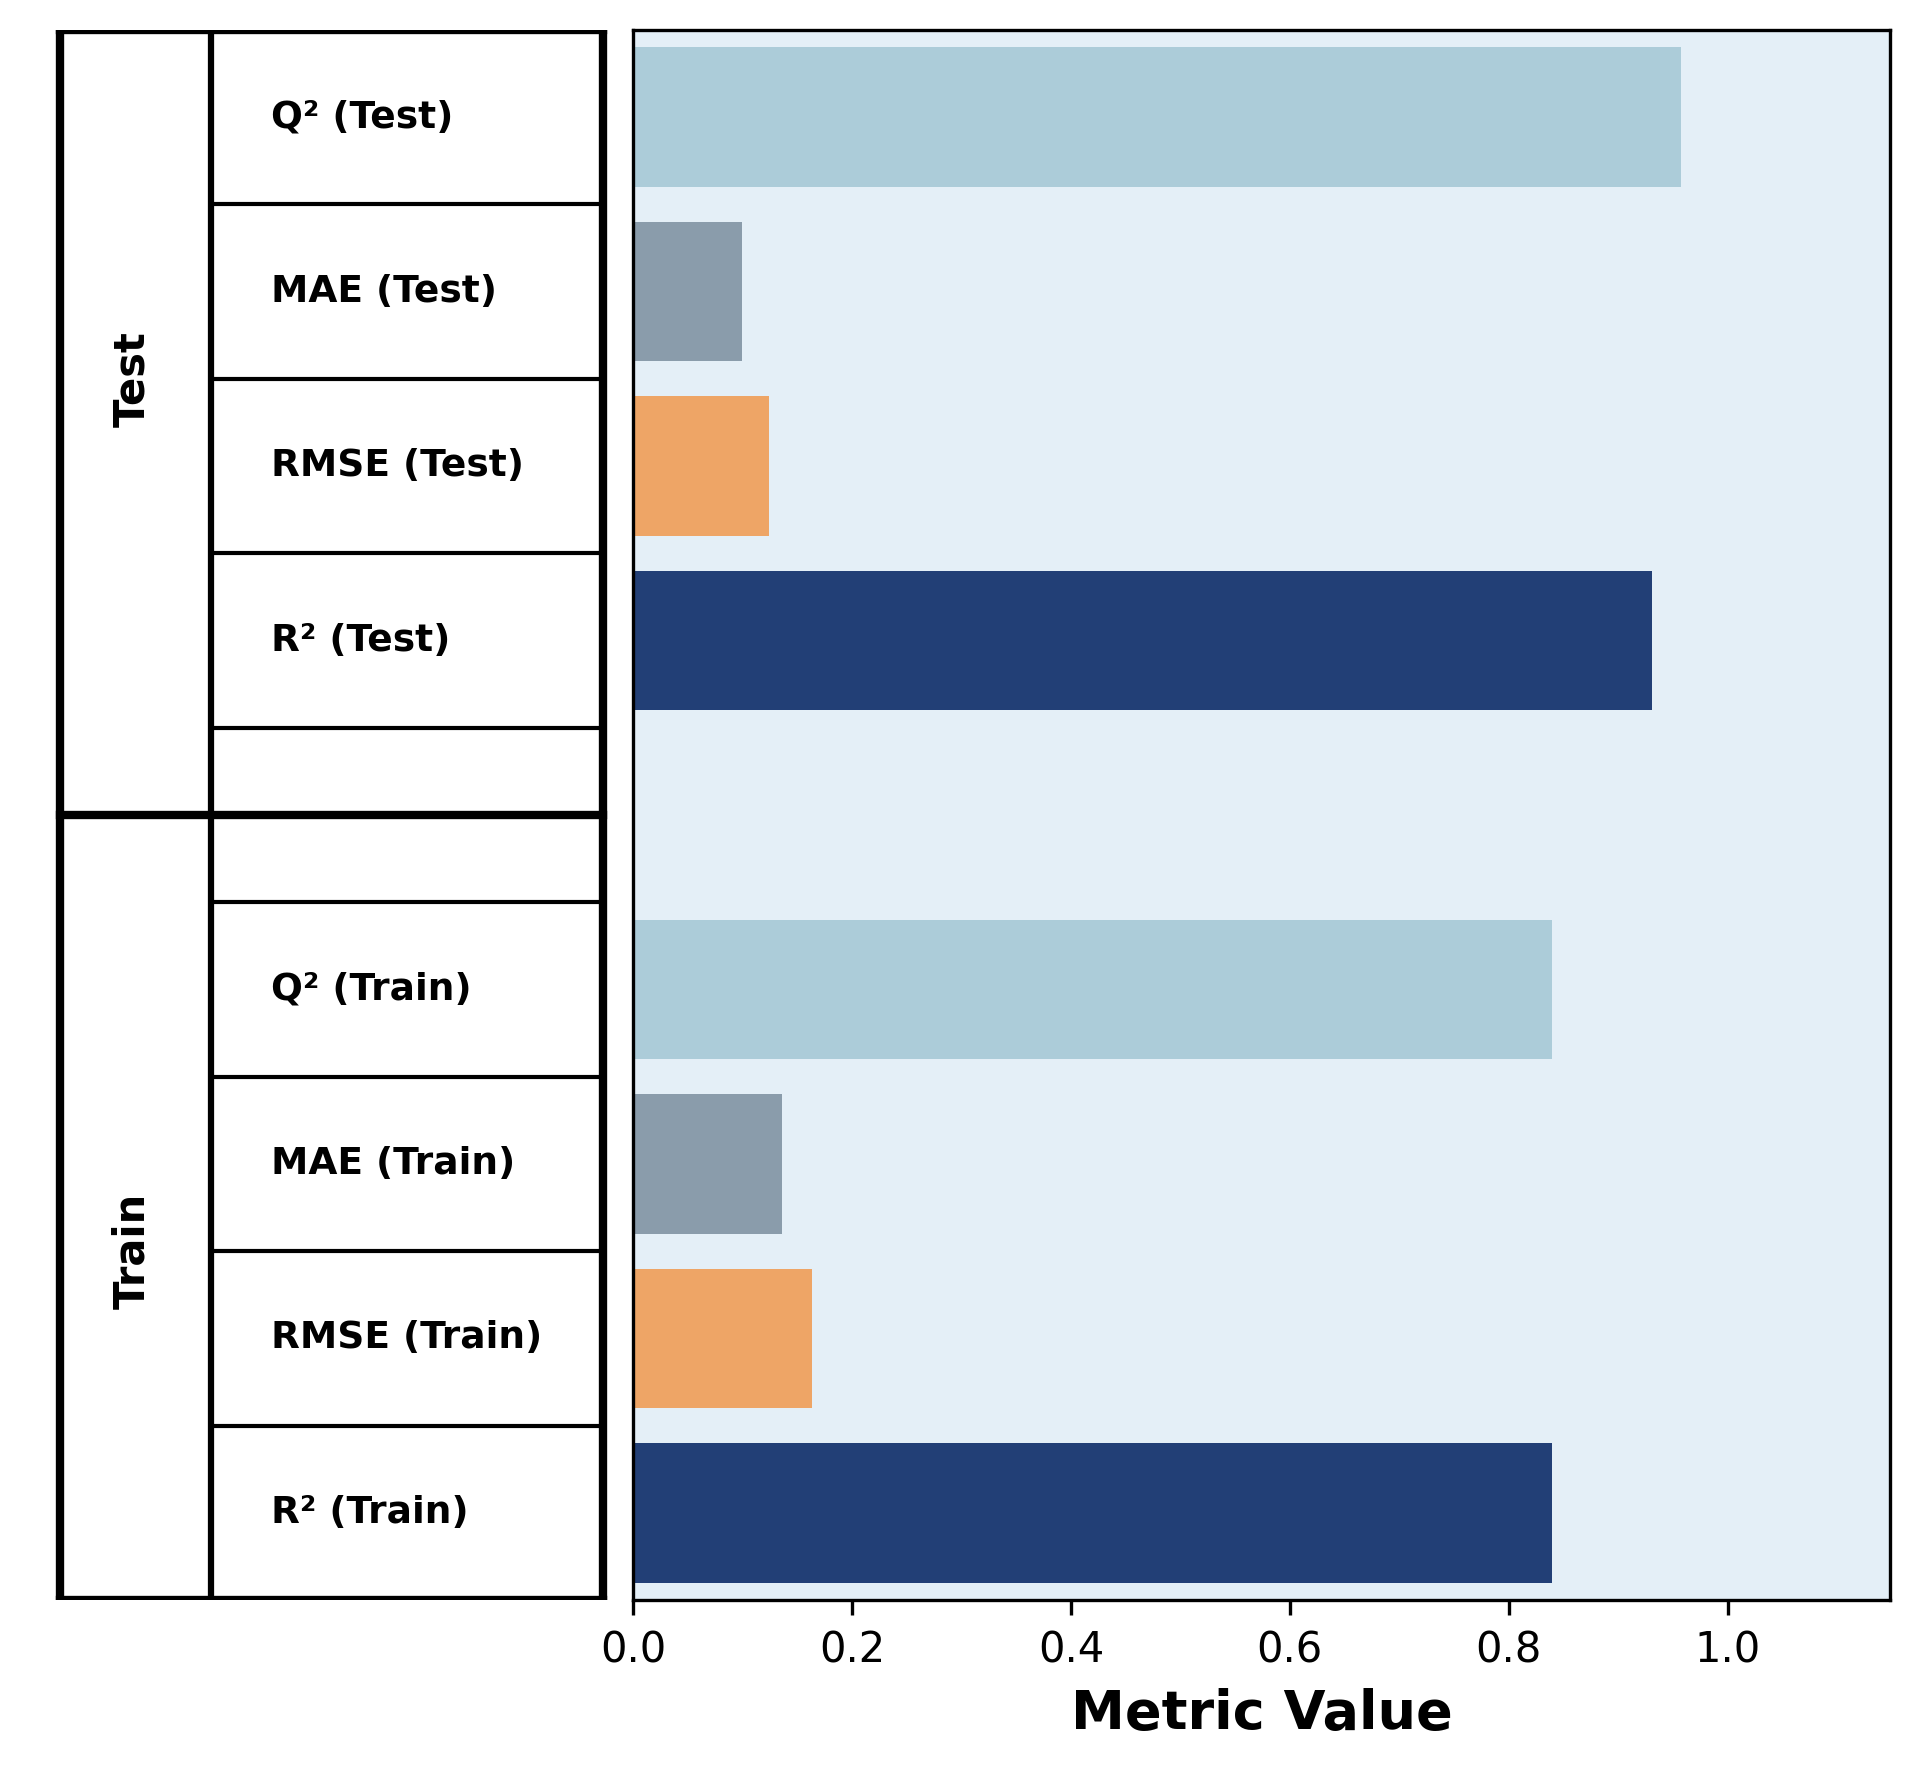

In [ ]:
plot_metrics_bar_chart(
    r2_train, rmse_train, mae_train, q2_train,
    r2_test, rmse_test, mae_test, q2_test
)

ANN

In [ ]:
import optuna
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Define the objective function
def objective(trial):

    # Hyperparameters
    hidden_layer_sizes = trial.suggest_categorical(
        'hidden_layer_sizes',
        [(5,), (10,), (20, 20), (50, 50), (100, 100)]
    )

    activation = trial.suggest_categorical(
        'activation',
        ['relu', 'tanh']
    )

    alpha = trial.suggest_float(
        'alpha',
        1e-5,
        1e-1,
        log=True
    )

    learning_rate_init = trial.suggest_float(
        'learning_rate_init',
        0.0001,
        0.05,
        log=True
    )

    max_iter = trial.suggest_int(
        'max_iter',
        200,
        1000
    )

    batch_size = trial.suggest_categorical(
        'batch_size',
        [10, 20, 30, 40]
    )

    # Create ANN model
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=42
    )

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    combined_rmse = (rmse_train + rmse_test) / 2

    return combined_rmse


# Create study
study = optuna.create_study(direction="minimize")

# Optimize
study.optimize(objective, n_trials=20)

# Best parameters
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# Final ANN model
best_model = MLPRegressor(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=best_params['max_iter'],
    batch_size=best_params['batch_size'],
    random_state=42
)

# Train final model
best_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train_final = best_model.predict(X_train_scaled)
y_pred_test_final = best_model.predict(X_test_scaled)

# Final RMSE
final_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

print(f"Final RMSE on Training Set: {final_train_rmse}")
print(f"Final RMSE on Test Set: {final_test_rmse}")

[I 2026-05-11 23:07:09,789] A new study created in memory with name: no-name-bb389d9a-ea92-473b-b422-b82697fff368
[I 2026-05-11 23:07:09,896] Trial 0 finished with value: 0.17474946302530542 and parameters: {'hidden_layer_sizes': (50, 50), 'activation': 'relu', 'alpha': 0.0003029816716803783, 'learning_rate_init': 0.003175723558743082, 'max_iter': 484, 'batch_size': 40}. Best is trial 0 with value: 0.17474946302530542.
[I 2026-05-11 23:07:10,233] Trial 1 finished with value: 0.28246300320957274 and parameters: {'hidden_layer_sizes': (50, 50), 'activation': 'tanh', 'alpha': 0.0030463523752583166, 'learning_rate_init': 0.0001695391440874802, 'max_iter': 552, 'batch_size': 30}. Best is trial 0 with value: 0.17474946302530542.
[I 2026-05-11 23:07:10,269] Trial 2 finished with value: 0.4219096254160038 and parameters: {'hidden_layer_sizes': (100, 100), 'activation': 'tanh', 'alpha': 0.00021666465834000527, 'learning_rate_init': 0.019522324552942668, 'max_iter': 570, 'batch_size': 40}. Best 

Best Hyperparameters: {'hidden_layer_sizes': (50, 50), 'activation': 'relu', 'alpha': 0.0010273658244019104, 'learning_rate_init': 0.0012088823539329599, 'max_iter': 728, 'batch_size': 10}
Final RMSE on Training Set: 0.15633118455816336
Final RMSE on Test Set: 0.12680787913331626


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)

# Define the best hyperparameters from Optuna
best_params = {
    'hidden_layer_sizes': (10, 10),
    'activation': 'tanh',
    'alpha': 0.002128441195650943,
    'learning_rate_init': 0.04382855082816229,
    'batch_size': 3,
    'max_iter': 880
}

# Instantiate the ANN model with the best hyperparameters
best_model = MLPRegressor(
    **best_params,
    random_state=42
)

# Fit the model on the training data
best_model.fit(X_train_scaled, y_train)

# Predict on the training data
y_pred_train = best_model.predict(X_train_scaled)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predict on the test data
y_pred_test = best_model.predict(X_test)

# ----- TRAIN METRICS -----
mse_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train)) / len(y_train)
rmse_train = mse_train ** 0.5
r2_train = r2_score(y_train, y_pred_train)

# ----- TEST METRICS -----
mse_test = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test)) / len(y_test)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, y_pred_test)

# MAE (test)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Q2 (external test set)
y_train_mean = sum(y_train) / len(y_train)
ss_res = sum((y1 - y2) ** 2 for y1, y2 in zip(y_test, y_pred_test))
ss_tot = sum((y - y_train_mean) ** 2 for y in y_test)
q2_test = 1 - (ss_res / ss_tot)

# ----- PRINT RESULTS -----
print('RMSE (train): %.3f' % rmse_train)
print('R² (train): %.3f' % r2_train)

print('RMSE (test): %.3f' % rmse_test)
print('R² (test): %.3f' % r2_test)
print('MAE (test): %.3f' % mae_test)
print('Q² (test): %.3f' % q2_test)

from sklearn.metrics import mean_absolute_error

# ===================== TRAIN METRICS =====================

# MAE (train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Q² (train)
y_train_mean = sum(y_train) / len(y_train)

ss_res_train = sum((y1 - y2) ** 2 for y1, y2 in zip(y_train, y_pred_train))
ss_tot_train = sum((y - y_train_mean) ** 2 for y in y_train)

q2_train = 1 - (ss_res_train / ss_tot_train)

# Print results
print('MAE (train): %.3f' % mae_train)
print('Q² (train): %.3f' % q2_train)

RMSE (train): 0.225
R² (train): 0.696
RMSE (test): 0.776
R² (test): -1.679
MAE (test): 0.669
Q² (test): -0.668
MAE (train): 0.187
Q² (train): 0.696


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# Convert X_train and y_train to NumPy arrays
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

# Initialize K-Fold Cross-Validation
n_splits = 5  # Specify the number of splits
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# List to store R² scores for each fold
r2_scores = []

# Perform Cross-Validation
for train_index, test_index in kf.split(X_train_np):
    # Split the data into training and validation folds
    X_cv_train, X_cv_test = X_train_np[train_index], X_train_np[test_index]
    y_cv_train, y_cv_test = y_train_np[train_index], y_train_np[test_index]

    # Use the existing model to predict on the validation fold
    y_pred = best_model.predict(X_cv_test)

    # Calculate R² score for the validation fold
    r2_fold = r2_score(y_cv_test, y_pred)
    r2_scores.append(r2_fold)

# Calculate Mean and Standard Deviation of R² Scores
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

# Display Results
print(f"R² (Cross-Validation): {mean_r2:.4f} ± {std_r2:.4f}")


R² (Cross-Validation): -0.6967 ± 0.7739


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'train': '#002060',
        'test': '#f0984d'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test):

    fig = plt.figure(figsize=(7, 4), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.45)

    # ===================== LEFT: PARITY =====================
    ax1 = fig.add_subplot(gs[0])
    ax1.set_facecolor(scheme['bg'])

    # Scatter
    ax1.scatter(y_train, y_pred_train,
                color=scheme['train'], label='Train Set', alpha=0.8)

    ax1.scatter(y_test, y_pred_test,
                color=scheme['test'], marker='^', label='Test Set', alpha=0.9)

    # Diagonal
    ax1.plot([4, 6], [4, 6], color='black', linewidth=1)

    # 🔥 FORCE RANGE 4–6
    ax1.set_xlim(4, 6)
    ax1.set_ylim(4, 6)

    ax1.set_xticks(np.arange(4, 6.1, 0.5))
    ax1.set_yticks(np.arange(4, 6.1, 0.5))

    # Labels (🔥 closer y-label)
    ax1.set_xlabel('Exp. pIC50', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Pred. pIC50',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=5)

    ax1.legend(loc="upper left", frameon=False, fontsize=6)
    ax1.grid(False)

    # ===================== RIGHT: RESIDUALS =====================
    ax2 = fig.add_subplot(gs[1])
    ax2.set_facecolor(scheme['bg'])

    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    # Boxplot
    box = ax2.boxplot([residuals_test, residuals_train],
                      patch_artist=True,
                      labels=['Test', 'Train'],
                      widths=0.5)

    box['boxes'][0].set_facecolor(scheme['test'])
    box['boxes'][1].set_facecolor(scheme['train'])

    for patch in box['boxes']:
        patch.set_alpha(0.5)

    # Scatter
    jitter_test = np.random.normal(1, 0.05, size=len(residuals_test))
    jitter_train = np.random.normal(2, 0.05, size=len(residuals_train))

    ax2.scatter(jitter_test, residuals_test,
                color='blue', alpha=0.7, s=20, zorder=3)

    ax2.scatter(jitter_train, residuals_train,
                color='red', alpha=0.7, s=20, zorder=3)

    # Y range
    ax2.set_ylim(-1, 1)
    ax2.set_yticks(np.linspace(-1, 1, 5))

    ax2.set_ylabel('Residuals',
                   fontsize=13,
                   fontweight='bold',
                   labelpad=2)

    ax2.tick_params(labelsize=10)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

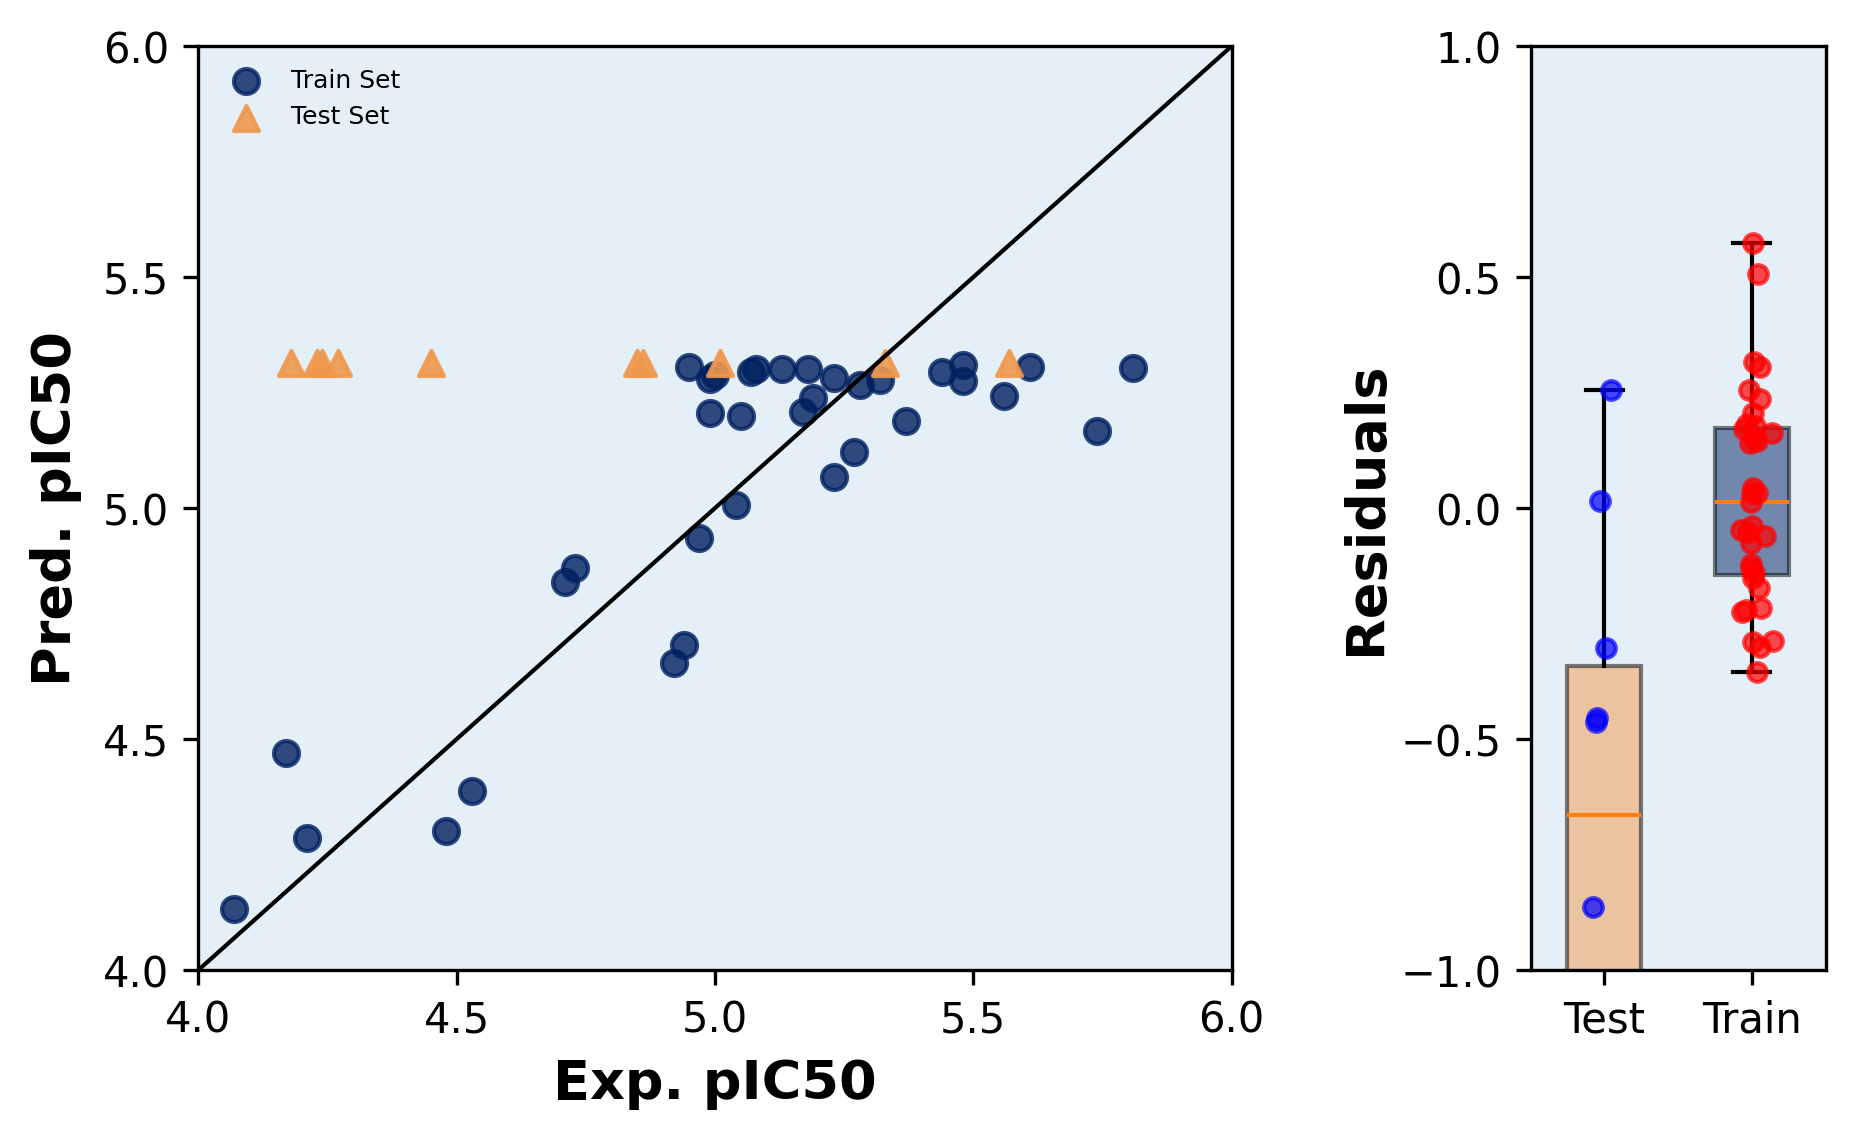

In [ ]:
plot_prediction_and_error(y_train, y_test, y_pred_train, y_pred_test)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===================== COLOR SCHEME =====================
COLOR_SCHEMES = {
    1: {
        'bg': '#e4eff7',
        'r2': '#002060',
        'rmse': '#f0984d',
        'mae': '#7a8e9e',
        'q2': '#a2c6d4'
    }
}
scheme = COLOR_SCHEMES[1]

# ===================== FUNCTION =====================
def plot_metrics_bar_chart(r2_train, rmse_train, mae_train, q2_train,
                           r2_test, rmse_test, mae_test, q2_test):

    # Labels (top → bottom)
    labels = [
        'R² (Train)', 'RMSE (Train)', 'MAE (Train)', 'Q² (Train)',
        'R² (Test)', 'RMSE (Test)', 'MAE (Test)', 'Q² (Test)'
    ]

    values = [
        r2_train, rmse_train, mae_train, q2_train,
        r2_test, rmse_test, mae_test, q2_test
    ]

    colors = [
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2'],
        scheme['r2'], scheme['rmse'], scheme['mae'], scheme['q2']
    ]

    # Positions (spacing between Train and Test)
    y_pos = [1, 2, 3, 4, 6, 7, 8, 9]

    # ===================== FIGURE =====================
    fig = plt.figure(figsize=(6.5, 6), dpi=300)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 2.5], wspace=0)

    # ===================== LEFT PANEL (TABLE) =====================
    ax_tab = fig.add_subplot(gs[0])
    ax_tab.set_xlim(0, 1)
    ax_tab.set_ylim(0.5, 9.5)
    ax_tab.axis('off')

    # ---- OUTER BORDER ----
    ax_tab.plot([0.05, 0.95], [0.5, 0.5], color='black', linewidth=2)   # bottom
    ax_tab.plot([0.05, 0.95], [9.5, 9.5], color='black', linewidth=2)   # top
    ax_tab.plot([0.05, 0.05], [0.5, 9.5], color='black', linewidth=2)   # left
    ax_tab.plot([0.95, 0.95], [0.5, 9.5], color='black', linewidth=2)   # right

    # ---- INNER VERTICAL DIVIDER ----
    ax_tab.plot([0.3, 0.3], [0.5, 9.5], color='black', linewidth=1.5)

    # ---- HORIZONTAL LINES ----
    for y in [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]:
        ax_tab.plot([0.3, 0.95], [y, y], color='black', linewidth=1)

    # ---- GROUP DIVIDER ----
    ax_tab.plot([0.05, 0.95], [5.0, 5.0], color='black', linewidth=2)

    # ---- SECTION LABELS ----
    ax_tab.text(0.17, 2.5, 'Train',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    ax_tab.text(0.17, 7.5, 'Test',
                rotation=90, va='center', ha='center',
                fontweight='bold', fontsize=10)

    # ---- METRIC LABELS ----
    for y, label in zip(y_pos, labels):
        ax_tab.text(0.4, y, label,
                    va='center', ha='left',
                    fontsize=9, fontweight='bold')

    # ===================== RIGHT PANEL (BARS) =====================
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.set_facecolor(scheme['bg'])

    ax_bar.barh(y_pos, values, color=colors, alpha=0.85)

    ax_bar.set_ylim(0.5, 9.5)
    ax_bar.set_xlim(0, max(values) * 1.2)

    # Remove y ticks (handled by table)
    ax_bar.set_yticks([])

    # Labels
    ax_bar.set_xlabel('Metric Value', fontsize=13, fontweight='bold')

    # Clean look
    ax_bar.grid(False)

    # Layout
    plt.tight_layout()
    plt.show()

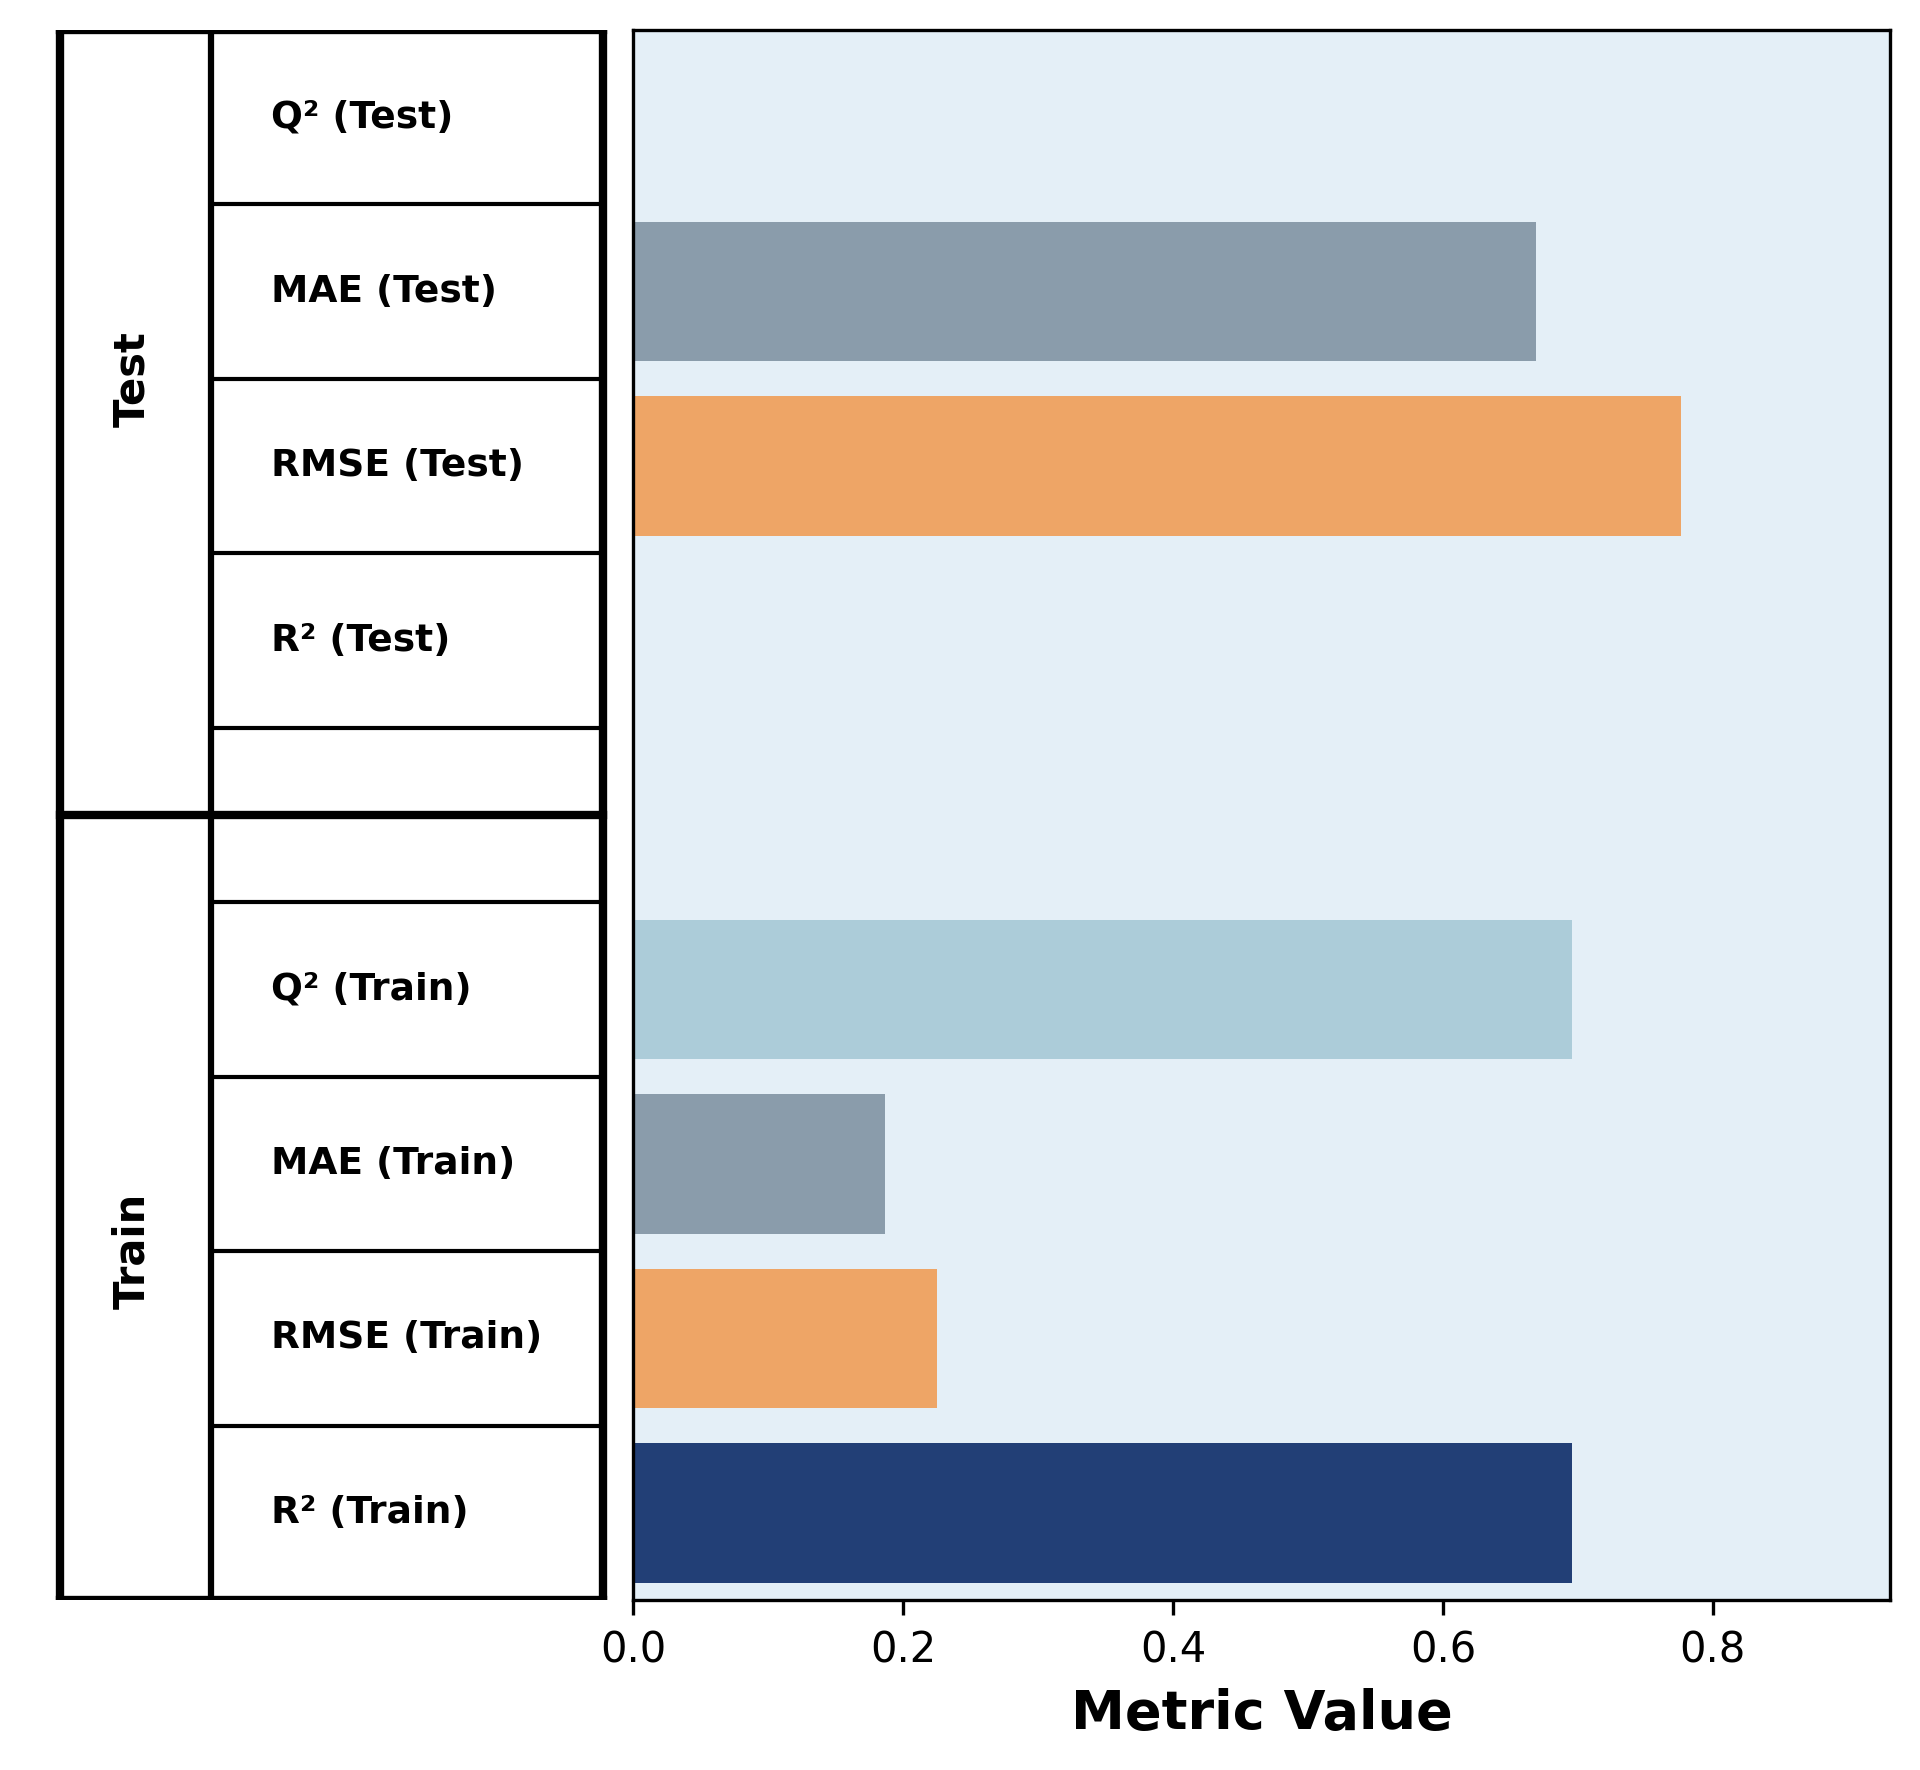

In [ ]:
plot_metrics_bar_chart(
    r2_train, rmse_train, mae_train, q2_train,
    r2_test, rmse_test, mae_test, q2_test
)